# **Data Generators & Preprocessing** 

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["ABSL_LOG_LEVEL"] = "3"
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ------------------ Data Paths ------------------
base = "/kaggle/input/pmram-bangladeshi-brain-cancer-mri-dataset/PMRAM Bangladeshi Brain Cancer - MRI Dataset/PMRAM Bangladeshi Brain Cancer - MRI Dataset"

# Only RAW data (no Augmented folder)
raw_root = os.path.join(base, "Raw Data", "Raw")

# ------------------ SHOW SELECTED PATHS ------------------
print("\n===== PATH USING =====")
print("Dataset Root:        ", base)
print("Selected RAW Folder: ", raw_root)
print("Subfolders Inside Raw (classes):")
print(os.listdir(raw_root))
print("================================\n")

# ------------------ Detect classes ------------------
def get_class_list(folder):
    return sorted([d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d))])

classes_list = get_class_list(raw_root)
print("Classes detected:", classes_list)

# ------------------ Generator Settings ------------------
target_size = (224, 224)
batch_size = 32
seed = 42
validation_split = 0.1

train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    fill_mode='nearest',
    validation_split=validation_split
)

val_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    validation_split=validation_split
)

test_datagen = ImageDataGenerator(rescale=1.0/255.0)

# ------------------ Generators ------------------
train_generator = train_datagen.flow_from_directory(
    raw_root,
    target_size=target_size,
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
    subset='training',
    seed=seed
)

validation_generator = val_datagen.flow_from_directory(
    raw_root,
    target_size=target_size,
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
    subset='validation',
    seed=seed
)

test_generator = test_datagen.flow_from_directory(
    raw_root,
    target_size=target_size,
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
    classes=classes_list
)

# ------------------ Checks ------------------
print("\n===== SUMMARY =====")
print("Train samples:     ", train_generator.samples)
print("Validation samples:", validation_generator.samples)
print("Test samples:      ", test_generator.samples)
print("Class indices:     ", train_generator.class_indices)
print("====================\n")

E0000 00:00:1765891408.586350      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765891408.650165      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'


===== PATH USING =====
Dataset Root:         /kaggle/input/pmram-bangladeshi-brain-cancer-mri-dataset/PMRAM Bangladeshi Brain Cancer - MRI Dataset/PMRAM Bangladeshi Brain Cancer - MRI Dataset
Selected RAW Folder:  /kaggle/input/pmram-bangladeshi-brain-cancer-mri-dataset/PMRAM Bangladeshi Brain Cancer - MRI Dataset/PMRAM Bangladeshi Brain Cancer - MRI Dataset/Raw Data/Raw
Subfolders Inside Raw (classes):
['512Glioma', '512Meningioma', '512Pituitary', '512Normal']

Classes detected: ['512Glioma', '512Meningioma', '512Normal', '512Pituitary']
Found 1356 images belonging to 4 classes.
Found 149 images belonging to 4 classes.
Found 1505 images belonging to 4 classes.

===== SUMMARY =====
Train samples:      1356
Validation samples: 149
Test samples:       1505
Class indices:      {'512Glioma': 0, '512Meningioma': 1, '512Normal': 2, '512Pituitary': 3}



# **Dataset Overview**

In [2]:
import os

def count_images_in_folder(folder_path):
    """Count number of images and subfolders (classes) in a given directory."""
    if not os.path.exists(folder_path):
        print(f"❌ Folder not found: {folder_path}")
        return [], {}, 0
    
    class_folders = [d for d in sorted(os.listdir(folder_path)) 
                     if os.path.isdir(os.path.join(folder_path, d))]
    
    total_images = 0
    class_counts = {}

    for cls in class_folders:
        cls_path = os.path.join(folder_path, cls)
        image_files = [
            f for f in os.listdir(cls_path) 
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'))
        ]
        count = len(image_files)
        class_counts[cls] = count
        total_images += count

    return class_folders, class_counts, total_images


# ------------------ DATA PATH ------------------
base = "/kaggle/input/pmram-bangladeshi-brain-cancer-mri-dataset/PMRAM Bangladeshi Brain Cancer - MRI Dataset/PMRAM Bangladeshi Brain Cancer - MRI Dataset"
data_root = os.path.join(base, "Raw Data", "Raw")   # ONLY USING RAW DATA

print("===== USING RAW DATA ONLY =====")
print("Raw data path:", data_root)
print("================================\n")

classes, class_counts, total_images = count_images_in_folder(data_root)

print("===== RAW DATASET =====")
print(f"Number of class folders: {len(classes)}")
print(f"Classes: {classes}")

for cls, cnt in class_counts.items():
    print(f"  {cls}: {cnt} images")

print(f"➡️ Total RAW images: {total_images}\n")

# ------------------ CLASS CONSISTENCY CHECK ------------------
if not classes:
    print("⚠️ No class folders detected in RAW folder!")

===== USING RAW DATA ONLY =====
Raw data path: /kaggle/input/pmram-bangladeshi-brain-cancer-mri-dataset/PMRAM Bangladeshi Brain Cancer - MRI Dataset/PMRAM Bangladeshi Brain Cancer - MRI Dataset/Raw Data/Raw

===== RAW DATASET =====
Number of class folders: 4
Classes: ['512Glioma', '512Meningioma', '512Normal', '512Pituitary']
  512Glioma: 373 images
  512Meningioma: 363 images
  512Normal: 396 images
  512Pituitary: 373 images
➡️ Total RAW images: 1505



# **Preprocessing Visualization**

Classes detected: ['512Glioma', '512Meningioma', '512Normal', '512Pituitary']


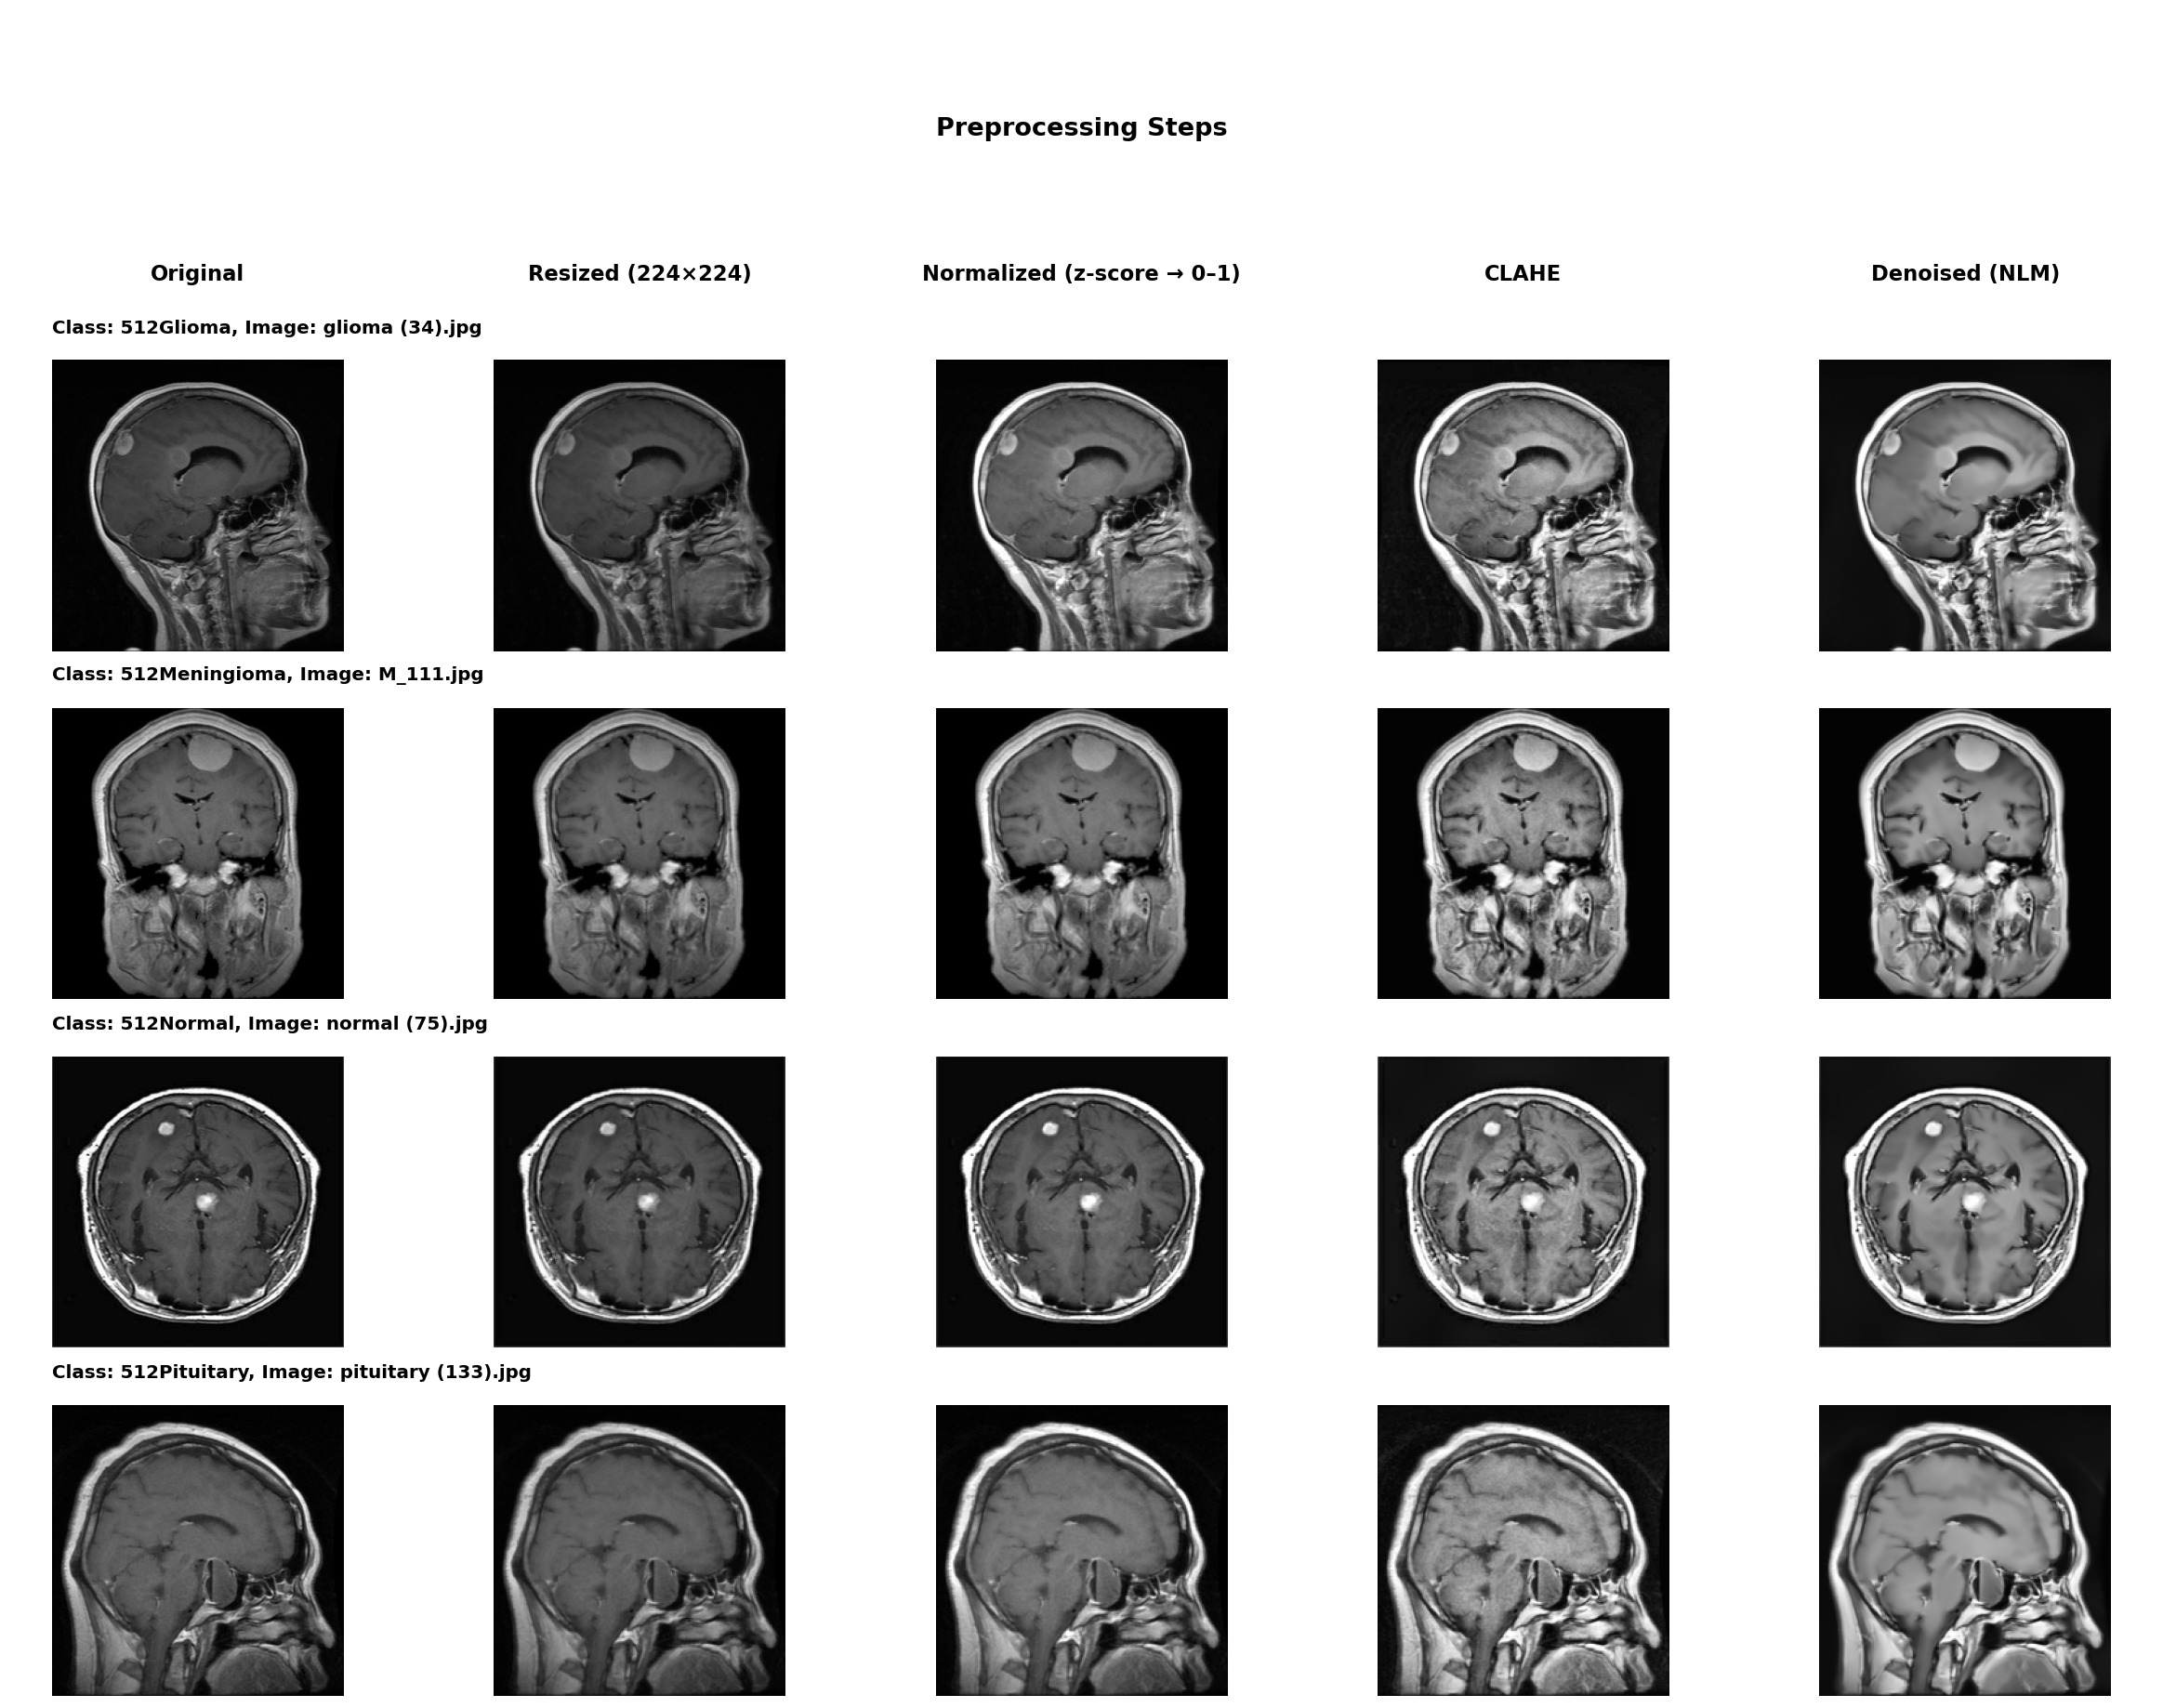

In [4]:
import os, random, cv2, numpy as np, matplotlib.pyplot as plt

data_root = "/kaggle/input/pmram-bangladeshi-brain-cancer-mri-dataset/PMRAM Bangladeshi Brain Cancer - MRI Dataset/PMRAM Bangladeshi Brain Cancer - MRI Dataset/Raw Data/Raw"

# Config
target_size = (224, 224)
sample_per_class = 1
dpi = 130
expected_prefix = "512"

if not os.path.exists(data_root):
    raise FileNotFoundError(f"Raw data folder not found: {data_root}")

# --- Classes ---
classes = sorted([
    d for d in os.listdir(data_root)
    if os.path.isdir(os.path.join(data_root, d)) and d.startswith(expected_prefix)
])
print("Classes detected:", classes)

if not classes:
    raise RuntimeError(f"No class folders found in {data_root} with prefix '{expected_prefix}'")

# =======================================================
# Helper: Preprocessing Steps (0–1 NORMALIZATION)
# =======================================================
def preprocess_steps(img_bgr, target_size=(224,224), zclip=3.0, nlm_h=10):
    if img_bgr is None:
        return None

    if img_bgr.ndim == 2:
        bgr = cv2.cvtColor(img_bgr, cv2.COLOR_GRAY2BGR)
    elif img_bgr.ndim == 3 and img_bgr.shape[2] == 1:
        bgr = cv2.cvtColor(img_bgr[:,:,0], cv2.COLOR_GRAY2BGR)
    else:
        bgr = img_bgr.copy()

    h, w = target_size
    resized = cv2.resize(bgr, (w, h), interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY).astype(np.float32)

    # -------- Z-score normalization --------
    mu, sigma = gray.mean(), gray.std() + 1e-8
    z = np.clip((gray - mu) / sigma, -zclip, zclip)

    # -------- Min–Max scaling to 0–1 --------
    zmin, zmax = z.min(), z.max()
    if zmax == zmin:
        normalized = np.zeros_like(gray, dtype=np.float32)
    else:
        normalized = (z - zmin) / (zmax - zmin)

    # -------- CLAHE (requires 0–255 uint8) --------
    clahe_input = (normalized * 255).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(clahe_input)

    # -------- Denoising --------
    denoised = cv2.fastNlMeansDenoising(clahe, h=nlm_h, templateWindowSize=7, searchWindowSize=21)

    return {
        "resized": resized,
        "normalized": normalized,
        "clahe": clahe,
        "denoised": denoised
    }

# --- Select samples (1 per class) ---
random.seed(42)
samples = []
for cls in classes:
    cls_path = os.path.join(data_root, cls)
    files = [f for f in os.listdir(cls_path)
             if f.lower().endswith(('.png','.jpg','.jpeg','.bmp','.tif','.tiff'))]
    if not files:
        continue
    fname = random.choice(files)
    samples.append((cls, fname, os.path.join(cls_path, fname)))

if not samples:
    raise RuntimeError("No sample images found.")

# --- Display layout ---
n_rows = len(samples)
n_cols = 5
fig = plt.figure(figsize=(18, n_rows * 3.8), dpi=dpi)

col_titles = [
    "Original",
    "Resized (224×224)",
    "Normalized (z-score → 0–1)",
    "CLAHE",
    "Denoised (NLM)"
]

for j, t in enumerate(col_titles):
    ax = plt.subplot(n_rows + 1, n_cols, j + 1)
    ax.text(0.5, 0.10, t, ha='center', va='center', fontsize=12.5, weight='600', transform=ax.transAxes)
    ax.axis('off')

plt.subplots_adjust(hspace=0.01, wspace=0.01,
                    top=0.70, bottom=0.005,
                    left=0.005, right=0.995)

# --- Rows ---
for i, (cls, fname, fpath) in enumerate(samples):
    img = cv2.imread(fpath, cv2.IMREAD_UNCHANGED)

    if img.ndim == 2:
        orig = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    else:
        orig = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    steps = preprocess_steps(img, target_size=target_size)

    resized_rgb = cv2.cvtColor(steps["resized"], cv2.COLOR_BGR2RGB)
    normalized_rgb = np.dstack([steps["normalized"]]*3) 
    clahe_rgb = cv2.cvtColor(steps["clahe"], cv2.COLOR_GRAY2RGB)
    denoised_rgb = cv2.cvtColor(steps["denoised"], cv2.COLOR_GRAY2RGB)

    imgs = [orig, resized_rgb, normalized_rgb, clahe_rgb, denoised_rgb]

    label = f"Class: {cls}, Image: {fname}"

    for j, im in enumerate(imgs):
        ax = plt.subplot(n_rows + 1, n_cols, (i + 1) * n_cols + j + 1)
        ax.imshow(im)
        ax.axis('off')
        if j == 0:
            ax.text(0, 1.08, label, transform=ax.transAxes,
                    fontsize=11, weight='700', va='bottom')

plt.suptitle("Preprocessing Steps",
             fontsize=15, weight='700', y=0.87)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# **Preprocessing Quality Evaluation (PSNR & SSIM)**

In [4]:
import os, random, cv2, numpy as np
import pandas as pd
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# --- CONFIG ---
data_root = "/kaggle/input/pmram-bangladeshi-brain-cancer-mri-dataset/PMRAM Bangladeshi Brain Cancer - MRI Dataset/PMRAM Bangladeshi Brain Cancer - MRI Dataset/Raw Data/Raw"
target_size = (224, 224)
expected_prefix = "512"
random.seed(42)

# --- PREPROCESS (same as before) ---
def preprocess_steps(img_bgr, target_size=(224,224), zclip=3.0, nlm_h=10):
    if img_bgr is None:
        return None
    if img_bgr.ndim == 2:
        bgr = cv2.cvtColor(img_bgr, cv2.COLOR_GRAY2BGR)
    elif img_bgr.ndim == 3 and img_bgr.shape[2] == 1:
        bgr = cv2.cvtColor(img_bgr[:,:,0], cv2.COLOR_GRAY2BGR)
    else:
        bgr = img_bgr.copy()

    h, w = target_size
    resized = cv2.resize(bgr, (w, h), interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY).astype(np.float32)

    mu, sigma = gray.mean(), gray.std() + 1e-8
    z = np.clip((gray - mu) / sigma, -zclip, zclip)
    zmin, zmax = z.min(), z.max()
    normalized = ((z - zmin) / (zmax - zmin) * 255).astype(np.uint8)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(normalized)
    denoised = cv2.fastNlMeansDenoising(clahe, h=nlm_h)

    return resized, normalized, clahe, denoised


# --- DETECT CLASSES ---
classes = sorted([d for d in os.listdir(data_root)
    if os.path.isdir(os.path.join(data_root, d)) and d.startswith(expected_prefix)])

results = []

for cls in classes:
    cls_path = os.path.join(data_root, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png','.jpg','.jpeg'))]
    if not images:
        continue
    fname = random.choice(images)
    fpath = os.path.join(cls_path, fname)

    img = cv2.imread(fpath, cv2.IMREAD_UNCHANGED)
    resized, normalized, clahe, denoised = preprocess_steps(img, target_size)

    psnr_before = psnr(normalized, denoised, data_range=255)
    ssim_before = ssim(normalized, denoised, data_range=255)

    psnr_after = psnr(clahe, denoised, data_range=255)
    ssim_after = ssim(clahe, denoised, data_range=255)

    print(f"\nSample: {cls}/{fname}")
    print(f" Normalized  -> PSNR: {psnr_before:.3f}, SSIM: {ssim_before:.4f}")
    print(f" CLAHE       -> PSNR: {psnr_after:.3f}, SSIM: {ssim_after:.4f}")
    print(f" Denoised NLM-> PSNR: {psnr_after:.3f}, SSIM: {ssim_after:.4f}")
    
    results.append([cls, fname, psnr_before, psnr_after, ssim_before, ssim_after])


df = pd.DataFrame(results, columns=[
    "Class", "Image", 
    "PSNR Before (dB)", "PSNR After (dB)",
    "SSIM Before", "SSIM After"
])
display(df)


Sample: 512Glioma/glioma (34).jpg
 Normalized  -> PSNR: 21.974, SSIM: 0.8321
 CLAHE       -> PSNR: 36.585, SSIM: 0.9309
 Denoised NLM-> PSNR: 36.585, SSIM: 0.9309

Sample: 512Meningioma/M_111.jpg
 Normalized  -> PSNR: 21.759, SSIM: 0.7423
 CLAHE       -> PSNR: 38.169, SSIM: 0.9743
 Denoised NLM-> PSNR: 38.169, SSIM: 0.9743

Sample: 512Normal/normal (75).jpg
 Normalized  -> PSNR: 20.411, SSIM: 0.8288
 CLAHE       -> PSNR: 36.401, SSIM: 0.9476
 Denoised NLM-> PSNR: 36.401, SSIM: 0.9476

Sample: 512Pituitary/pituitary (133).jpg
 Normalized  -> PSNR: 19.472, SSIM: 0.8205
 CLAHE       -> PSNR: 35.007, SSIM: 0.9110
 Denoised NLM-> PSNR: 35.007, SSIM: 0.9110


,Class,Image,PSNR Before (dB),PSNR After (dB),SSIM Before,SSIM After
0,512Glioma,glioma (34).jpg,21.973520,36.584633,0.832122,0.930890
1,512Meningioma,M_111.jpg,21.758872,38.169309,0.742326,0.974315
2,512Normal,normal (75).jpg,20.411421,36.400797,0.828751,0.947647
3,512Pituitary,pituitary (133).jpg,19.471674,35.006949,0.820483,0.910993


# **Dataset Augmentation** 

🔍 Detecting RAW classes...
Found classes: ['512Glioma', '512Meningioma', '512Normal', '512Pituitary']
512Glioma raw count: 373
512Meningioma raw count: 363
512Normal raw count: 396
512Pituitary raw count: 373

📊 Augmented image counts:

Glioma: 1865 images
Meningioma: 1815 images
Normal: 1980 images
Pituitary_Tumor: 1865 images


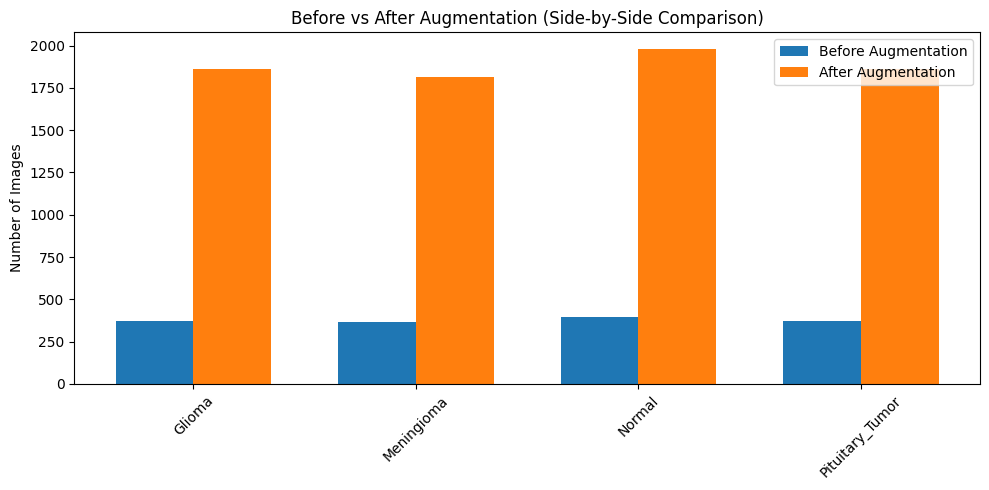


✅ Augmentation complete. Files saved in: /kaggle/working/raw_augmented


In [5]:
import os
import cv2
import numpy as np
import random
import shutil
from pathlib import Path
import matplotlib.pyplot as plt

RAW_DIR = Path(
    "/kaggle/input/pmram-bangladeshi-brain-cancer-mri-dataset/"
    "PMRAM Bangladeshi Brain Cancer - MRI Dataset/"
    "PMRAM Bangladeshi Brain Cancer - MRI Dataset/Raw Data/Raw"
)

AUG_OUT = Path("/kaggle/working/raw_augmented")

# Delete old augmentation folder
if AUG_OUT.exists():
    shutil.rmtree(AUG_OUT)
AUG_OUT.mkdir(parents=True, exist_ok=True)

AUG_PER_IMAGE = 4
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

VALID_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

def to_bgr3(img):
    if img is None:
        return None
    if img.ndim == 2:
        return cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    if img.ndim == 3 and img.shape[2] == 1:
        return cv2.cvtColor(img[:, :, 0], cv2.COLOR_GRAY2BGR)
    return img

def random_flip(img):
    return cv2.flip(img, random.choice([-1,0,1]))

def random_rotate(img):
    angle = random.uniform(-25,25)
    h,w=img.shape[:2]
    M=cv2.getRotationMatrix2D((w//2,h//2),angle,1.0)
    return cv2.warpAffine(img,M,(w,h),borderMode=cv2.BORDER_REFLECT)

def random_zoom(img):
    zoom=random.uniform(0.8,1.2)
    h,w=img.shape[:2]
    nh,nw=int(h*zoom),int(w*zoom)
    resized=cv2.resize(img,(nw,nh))
    if zoom<1:
        pad_h=(h-nh)//2
        pad_w=(w-nw)//2
        return cv2.copyMakeBorder(resized,pad_h,h-nh-pad_h,pad_w,w-nw-pad_w,cv2.BORDER_REFLECT)
    else:
        sh=(nh-h)//2
        sw=(nw-w)//2
        return resized[sh:sh+h, sw:sw+w]

def random_brightness(img):
    factor=random.uniform(0.7,1.3)
    return np.clip(img.astype(float)*factor,0,255).astype(np.uint8)

AUG_FUNCTIONS=[random_flip,random_rotate,random_zoom,random_brightness]

print("🔍 Detecting RAW classes...")
classes = sorted([d.name for d in RAW_DIR.iterdir() if d.is_dir()])
print("Found classes:", classes)

for cls in classes:
    cls_out = AUG_OUT / cls
    cls_out.mkdir(parents=True, exist_ok=True)
    cls_raw = RAW_DIR / cls

    files = [f for f in os.listdir(cls_raw) if f.lower().endswith(VALID_EXTS)]

    print(f"{cls} raw count: {len(files)}")

    for file in files:
        src_path = cls_raw / file
        img = cv2.imread(str(src_path), cv2.IMREAD_UNCHANGED)
        img = to_bgr3(img)

        if img is None:
            print(f"⚠️ Warning: failed to load {src_path}, skipping.")
            continue

        out_orig = cls_out / file
        cv2.imwrite(str(out_orig), img)

        # augmentations
        stem = Path(file).stem
        suffix = Path(file).suffix  # keeps full extension like .jpeg or .tiff
        for i in range(AUG_PER_IMAGE):
            aug = img.copy()
            aug = random.choice(AUG_FUNCTIONS)(aug)
            name = f"{stem}_aug{i+1}{suffix}"
            cv2.imwrite(str(cls_out / name), aug)

print("\n📊 Augmented image counts:\n")
pretty = {"512Glioma":"Glioma","512Meningioma":"Meningioma","512Normal":"Normal","512Pituitary":"Pituitary_Tumor"}

for cls in classes:
    count = len([f for f in os.listdir(AUG_OUT/cls) if f.lower().endswith(VALID_EXTS)])
    print(f"{pretty.get(cls,cls)}: {count} images")

# ========================================================
# BAR GRAPH: Before vs After augmentation (Side-by-Side)
# ========================================================

before_counts = {}
after_counts = {}

# Count before augmentation
for cls in classes:
    cls_raw = RAW_DIR / cls
    before_counts[cls] = len([f for f in os.listdir(cls_raw) if f.lower().endswith(VALID_EXTS)])

# Count after augmentation
for cls in classes:
    cls_aug = AUG_OUT / cls
    after_counts[cls] = len([f for f in os.listdir(cls_aug) if f.lower().endswith(VALID_EXTS)])

labels = [pretty.get(c, c) for c in classes]

plt.figure(figsize=(10, 5))
x = np.arange(len(classes))
width = 0.35

plt.bar(x - width/2, [before_counts[c] for c in classes], width, label='Before Augmentation')
plt.bar(x + width/2, [after_counts[c] for c in classes], width, label='After Augmentation')
plt.xticks(x, labels, rotation=45)
plt.ylabel("Number of Images")
plt.title("Before vs After Augmentation (Side-by-Side Comparison)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n✅ Augmentation complete. Files saved in: {AUG_OUT}")

# **Split Augmented Dataset**

In [6]:
# === Create 80% train / 10% val / 10% test split from AUGMENTED folder ===
import os
import shutil
import random
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

# ---------- CONFIG (AUGMENTED DATA ONLY) ----------
INPUT_RAW = Path("/kaggle/working/raw_augmented")  
OUT_ROOT = Path("/kaggle/working/raw_split")  
SEED = 42
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

random.seed(SEED)

# ---------- Verify input exists ----------
if not INPUT_RAW.exists():
    raise FileNotFoundError(f"Augmented data folder not found: {INPUT_RAW}")

# ---------- Collect images from AUGMENTED only ----------
items = []
for cls_dir in sorted([d for d in INPUT_RAW.iterdir() if d.is_dir()]):
    cls = cls_dir.name
    for f in cls_dir.iterdir():
        if f.suffix.lower() in VALID_EXTS:
            items.append((str(f), cls))

df = pd.DataFrame(items, columns=["filepath", "label"])
if df.empty:
    raise RuntimeError(f"No image files found under AUGMENTED folder: {INPUT_RAW}")

print("\nTotal AUGMENTED images found:", len(df))
print("Classes:", sorted(df["label"].unique().tolist()))

# ---------- Prepare output ----------
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# ---------- Stratified 80/10/10 split ----------
min_count = df["label"].value_counts().min()
strat = df["label"] if min_count >= 3 else None

train_df, temp_df = train_test_split(
    df, test_size=0.20, stratify=strat, random_state=SEED, shuffle=True
)

# Split remaining 20% into val/test 50/50 -> each 10% overall
strat_temp = temp_df["label"] if strat is not None else None
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=strat_temp, random_state=SEED, shuffle=True
)

N = len(df)
print("\n===== SPLIT SUMMARY =====")
print(f"Total = {N}")
print(f"Train = {len(train_df)} ({len(train_df)/N*100:.2f}%)")
print(f"Val   = {len(val_df)} ({len(val_df)/N*100:.2f}%)")
print(f"Test  = {len(test_df)} ({len(test_df)/N*100:.2f}%)")
print("==========================\n")

split_base = OUT_ROOT
for split in ["train", "val", "test"]:
    for cls in sorted(df["label"].unique()):
        (split_base / split / cls).mkdir(parents=True, exist_ok=True)

# ---------- Build file lists per class ----------
def build_class_lists(df_subset):
    return {
        cls: df_subset.loc[df_subset["label"] == cls, "filepath"].tolist()
        for cls in sorted(df["label"].unique())
    }

train_map = build_class_lists(train_df)
val_map   = build_class_lists(val_df)
test_map  = build_class_lists(test_df)

split_summary = {}

for cls in sorted(df["label"].unique()):
    train_imgs = train_map.get(cls, [])
    val_imgs   = val_map.get(cls, [])
    test_imgs  = test_map.get(cls, [])

    for img_path in train_imgs:
        shutil.copy2(img_path, split_base / "train" / cls)

    for img_path in val_imgs:
        shutil.copy2(img_path, split_base / "val" / cls)

    for img_path in test_imgs:
        shutil.copy2(img_path, split_base / "test" / cls)

    split_summary[cls] = {
        "total": len(train_imgs) + len(val_imgs) + len(test_imgs),
        "train": len(train_imgs),
        "val"  : len(val_imgs),
        "test" : len(test_imgs)
    }

print("AUGMENTED Dataset Split Summary (saved under):", OUT_ROOT)
for cls, s in split_summary.items():
    print(f"{cls}: Total={s['total']}, Train={s['train']}, Val={s['val']}, Test={s['test']}")

print("\nAll split images saved in:", OUT_ROOT)


Total AUGMENTED images found: 7525
Classes: ['512Glioma', '512Meningioma', '512Normal', '512Pituitary']

===== SPLIT SUMMARY =====
Total = 7525
Train = 6020 (80.00%)
Val   = 752 (9.99%)
Test  = 753 (10.01%)

AUGMENTED Dataset Split Summary (saved under): /kaggle/working/raw_split
512Glioma: Total=1865, Train=1492, Val=186, Test=187
512Meningioma: Total=1815, Train=1452, Val=182, Test=181
512Normal: Total=1980, Train=1584, Val=198, Test=198
512Pituitary: Total=1865, Train=1492, Val=186, Test=187

All split images saved in: /kaggle/working/raw_split


# **ResNet-50 Model Training**

Device: cuda
Classes: ['512Glioma', '512Meningioma', '512Normal', '512Pituitary']
Sizes (train/val/test): 6020 752 753


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 221MB/s] 


Epoch 1/40 — train_loss=0.2186 acc=0.9228 | val_loss=0.0711 acc=0.9801 | time=60.3s
  Saved best model.
Epoch 2/40 — train_loss=0.0540 acc=0.9814 | val_loss=0.1263 acc=0.9455 | time=67.7s
Epoch 3/40 — train_loss=0.0812 acc=0.9728 | val_loss=0.0299 acc=0.9880 | time=76.3s
  Saved best model.
Epoch 4/40 — train_loss=0.0714 acc=0.9776 | val_loss=1.8194 acc=0.6755 | time=75.9s
Epoch 5/40 — train_loss=0.0327 acc=0.9895 | val_loss=0.0761 acc=0.9787 | time=75.5s
Epoch 6/40 — train_loss=0.0377 acc=0.9874 | val_loss=0.1643 acc=0.9415 | time=75.4s
Epoch 7/40 — train_loss=0.0272 acc=0.9919 | val_loss=0.0376 acc=0.9907 | time=75.8s
Epoch 8/40 — train_loss=0.0257 acc=0.9920 | val_loss=0.0098 acc=0.9947 | time=75.2s
  Saved best model.
Epoch 9/40 — train_loss=0.0081 acc=0.9978 | val_loss=0.0189 acc=0.9960 | time=75.5s
Epoch 10/40 — train_loss=0.0085 acc=0.9980 | val_loss=0.0054 acc=0.9960 | time=75.6s
  Saved best model.
Epoch 11/40 — train_loss=0.0054 acc=0.9987 | val_loss=0.0152 acc=0.9947 | time=

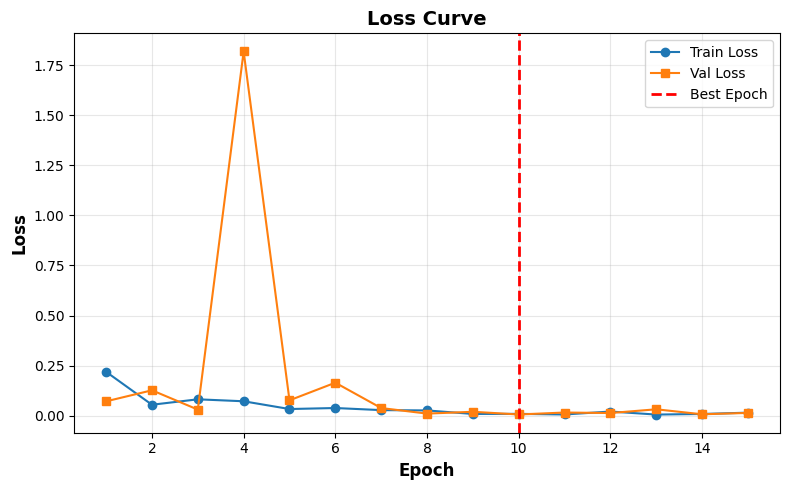

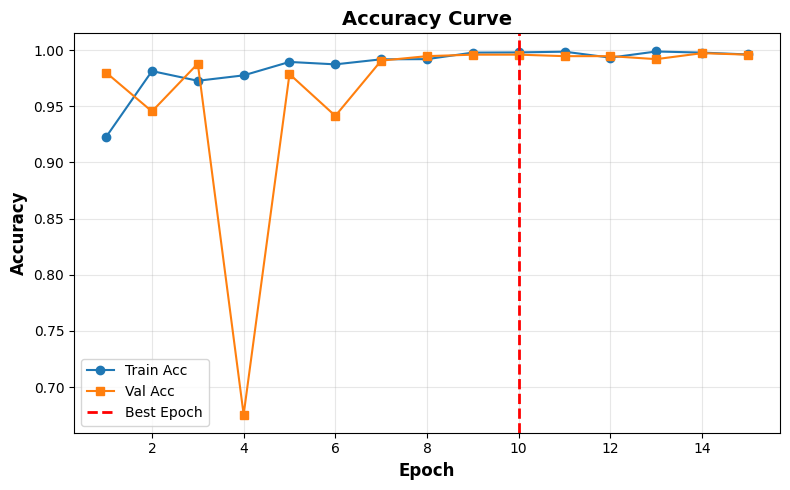

Saved plots to: /kaggle/working/checkpoints/loss_curve.png /kaggle/working/checkpoints/accuracy_curve.png

=== TRAIN REPORT ===
              precision    recall  f1-score   support

      Glioma     1.0000    0.9993    0.9997      1492
  Meningioma     0.9993    1.0000    0.9997      1452
      Normal     1.0000    1.0000    1.0000      1584
   Pituitary     1.0000    1.0000    1.0000      1492

    accuracy                         0.9998      6020
   macro avg     0.9998    0.9998    0.9998      6020
weighted avg     0.9998    0.9998    0.9998      6020



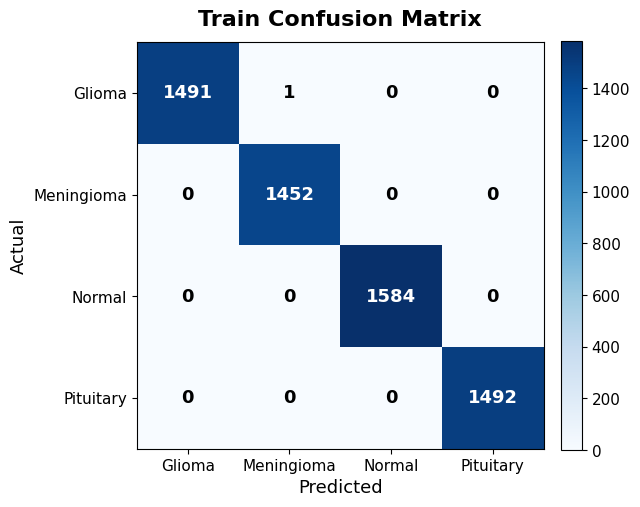

Mean PPV (Precision, macro): 0.9998
Cohen's Kappa: 0.9998
ROC AUC (macro): 1.0000
PR AUC (macro): 1.0000
Train inference time per image: 3.627 ms
Mean Specificity: 0.9999452714535901
Mean NPV: 0.9999448001766394
Bootstrap Accuracy Mean=0.9998, Std=0.0002

=== VAL REPORT ===
              precision    recall  f1-score   support

      Glioma     0.9946    0.9946    0.9946       186
  Meningioma     0.9945    0.9890    0.9917       182
      Normal     0.9950    1.0000    0.9975       198
   Pituitary     1.0000    1.0000    1.0000       186

    accuracy                         0.9960       752
   macro avg     0.9960    0.9959    0.9960       752
weighted avg     0.9960    0.9960    0.9960       752



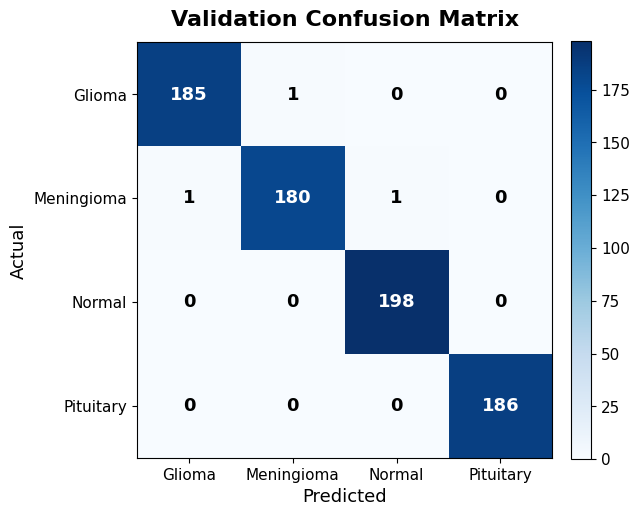

Mean PPV (Precision, macro): 0.9960
Cohen's Kappa: 0.9947
ROC AUC (macro): 1.0000
PR AUC (macro): 1.0000
Validation inference time per image: 3.908 ms
Mean Specificity: 0.9986684438577915
Mean NPV: 0.9986826471443688
Bootstrap Accuracy Mean=0.9961, Std=0.0023

=== TEST REPORT ===
              precision    recall  f1-score   support

      Glioma     0.9946    0.9893    0.9920       187
  Meningioma     0.9890    0.9890    0.9890       181
      Normal     0.9899    0.9949    0.9924       198
   Pituitary     1.0000    1.0000    1.0000       187

    accuracy                         0.9934       753
   macro avg     0.9934    0.9933    0.9933       753
weighted avg     0.9934    0.9934    0.9934       753



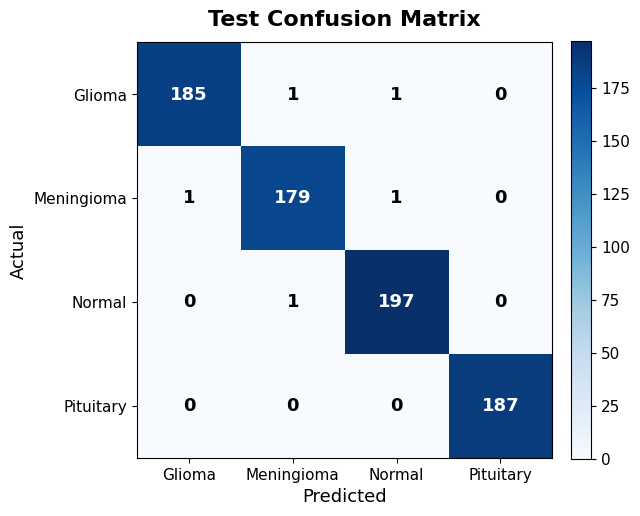

Mean PPV (Precision, macro): 0.9934
Cohen's Kappa: 0.9911
ROC AUC (macro): 0.9997
PR AUC (macro): 0.9993
Test inference time per image: 3.916 ms
Mean Specificity: 0.9977832771118991
Mean NPV: 0.9977927763728004
Bootstrap Accuracy Mean=0.9933, Std=0.0030
Accuracy 95% CI: 0.9933 [0.9867, 0.9987]



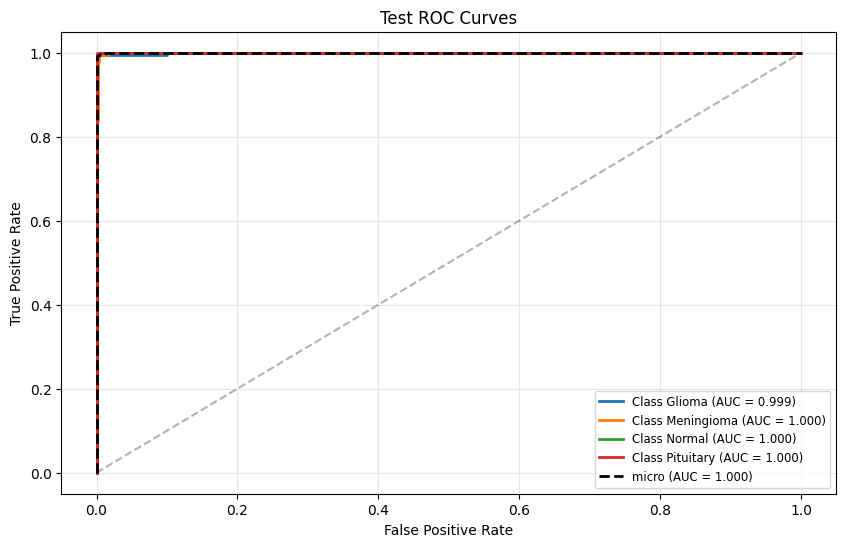

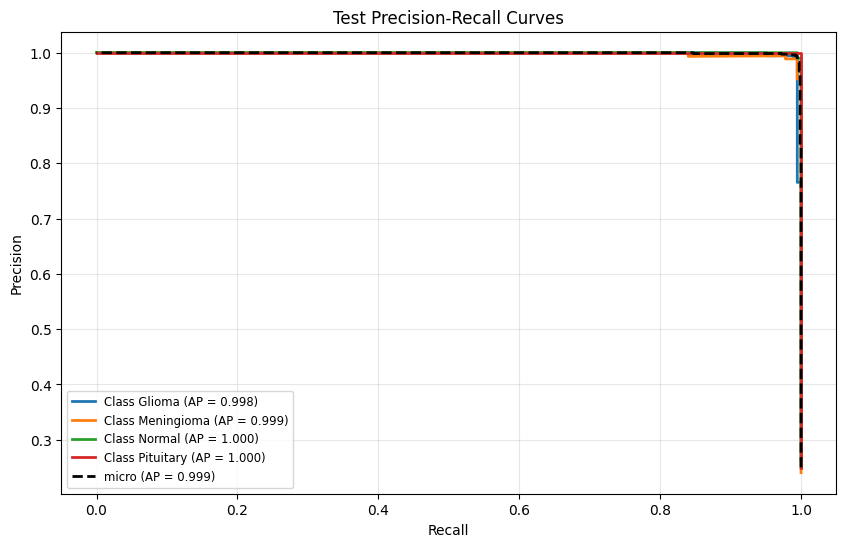



       TIME & MEMORY
Total Training Time: 1112.36 sec
Average Time per Epoch: 74.16 sec
Max GPU Memory Allocated (GB): 3.41212416
Max GPU Memory Reserved  (GB): 3.634364416
CPU RAM Used (GB): 2.2068224
Sample inference times (ms/image): train=3.627, val=3.908, test=3.916
Inference Time per Image (single random sample): 46.468 ms

Best checkpoint saved at: /kaggle/working/checkpoints/resnet50_best.pth


        MODEL SUMMARY
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]          

In [7]:
import time, copy, random, os, psutil
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim

from pathlib import Path
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_score,
    cohen_kappa_score, roc_auc_score, average_precision_score,
    roc_curve, auc, precision_recall_curve
)
from sklearn.preprocessing import label_binarize
from torchsummary import summary

# ---------- CONFIG ----------
DATA_ROOT = Path("/kaggle/working/raw_split")
CKPT_DIR  = Path("/kaggle/working/checkpoints"); CKPT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 40
PATIENCE = 5
LR = 3e-3     
WD = 1e-3
DROPOUT = 0.5
SEED = 42
NUM_WORKERS = 2 
PRETRAINED = True
# ------------------------

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Transforms
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# Datasets/Loaders
train_ds = datasets.ImageFolder(str(DATA_ROOT/"train"), transform=train_tf)
val_ds   = datasets.ImageFolder(str(DATA_ROOT/"val"),   transform=eval_tf)
test_ds  = datasets.ImageFolder(str(DATA_ROOT/"test"),  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

class_names = train_ds.classes
num_classes = len(class_names)
display_names = [c.replace("512","") for c in class_names]

print("Classes:", class_names)
print("Sizes (train/val/test):", len(train_ds), len(val_ds), len(test_ds))

# === Build ResNet-50 ===
model = models.resnet50(pretrained=PRETRAINED)
in_feats = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(DROPOUT),
    nn.Linear(in_feats, num_classes)
)
model = model.to(device)

# loss/optimizer/scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

# ---- Train loop ----
best_val = float('inf'); best_wts = copy.deepcopy(model.state_dict()); no_improve = 0
train_start_time = time.time()

best_epoch = 1
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(1, NUM_EPOCHS+1):
    t0 = time.time()

    model.train()
    train_loss_sum = 0; train_correct = 0
    for xb, yb in train_loader:
        xb = xb.to(device); yb = yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item() * xb.size(0)
        train_correct += (out.argmax(1) == yb).sum().item()

    train_loss = train_loss_sum / len(train_loader.dataset)
    train_acc  = train_correct / len(train_loader.dataset)

    model.eval()
    val_loss_sum = 0; val_correct = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device); yb = yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            val_loss_sum += loss.item() * xb.size(0)
            val_correct += (out.argmax(1) == yb).sum().item()

    val_loss = val_loss_sum / len(val_loader.dataset)
    val_acc  = val_correct / len(val_loader.dataset)

    scheduler.step(val_loss)

    print(f"Epoch {epoch}/{NUM_EPOCHS} — "
          f"train_loss={train_loss:.4f} acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} acc={val_acc:.4f} | "
          f"time={time.time()-t0:.1f}s")

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # checkpoint
    if val_loss < best_val:
        best_val = val_loss
        best_wts = copy.deepcopy(model.state_dict())
        best_epoch = epoch
        no_improve = 0
        torch.save({
            "model":"resnet50",
            "epoch":epoch,
            "state_dict":best_wts,
            "val_loss":best_val,
            "classes":class_names
        }, str(CKPT_DIR/"resnet50_best.pth"))
        print("  Saved best model.")
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print("Early stopping.")
            break

total_training_time = time.time() - train_start_time

# Load best weights
model.load_state_dict(best_wts)

# ======= Loss & Accuracy plots =======
epochs_range = list(range(1, len(train_losses) + 1))

fig1, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(epochs_range, train_losses, marker='o', linestyle='-', label='Train Loss')
ax1.plot(epochs_range, val_losses,   marker='s', linestyle='-', label='Val Loss')
ax1.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label='Best Epoch')
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax1.set_title('Loss Curve', fontsize=14, fontweight='700')
ax1.legend()
ax1.grid(alpha=0.3)
plt.tight_layout()
loss_path = CKPT_DIR / "loss_curve.png"
fig1.savefig(str(loss_path), dpi=150)
plt.show()

fig2, ax2 = plt.subplots(figsize=(8,5))
ax2.plot(epochs_range, train_accs, marker='o', linestyle='-', label='Train Acc')
ax2.plot(epochs_range, val_accs,   marker='s', linestyle='-', label='Val Acc')
ax2.axvline(best_epoch, color='red', linestyle='--', linewidth=2, label='Best Epoch')
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax2.set_title('Accuracy Curve', fontsize=14, fontweight='700')
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
acc_path = CKPT_DIR / "accuracy_curve.png"
fig2.savefig(str(acc_path), dpi=150)
plt.show()

print("Saved plots to:", loss_path, acc_path)

# ----- Evaluation helpers -----
def get_preds_probs_and_time(model, loader):
    """
    Runs model over loader and returns:
    - y_true (np array)
    - y_pred (np array)
    - y_probs (np array, shape [n_samples, num_classes])
    - avg_time_per_image_ms (float)
    """
    model.eval()
    y_true = []; y_pred = []; probs = []
    t0 = time.time()
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            out = model(xb)    # logits
            p = torch.softmax(out, dim=1).cpu().numpy()
            preds = out.argmax(1).cpu().numpy()
            probs.extend(p)
            y_pred.extend(preds)
            y_true.extend(yb.numpy())
    elapsed = time.time() - t0
    n = len(y_true) if len(y_true)>0 else 1
    avg_ms = (elapsed / n)*1000.0
    return np.array(y_true), np.array(y_pred), np.vstack(probs), avg_ms

def plot_confusion(cm, labels, title):
    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title, fontsize=16, fontweight="700", pad=12)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=11)

    ticks = np.arange(len(labels))
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_yticklabels(labels, fontsize=11)
    ax.set_xlabel("Predicted", fontsize=13)
    ax.set_ylabel("Actual", fontsize=13)

    vmax = cm.max() if cm.max() > 0 else 1
    thresh = vmax / 2.0

    for i in range(len(labels)):
        for j in range(len(labels)):
            val = cm[i, j]
            color = "white" if val > thresh else "black"
            ax.text(j, i, str(val), ha="center", va="center",
                    color=color, fontsize=13, fontweight='700')

    plt.tight_layout()
    return fig

# === Helpers: extra metrics ===
def compute_extra_metrics(cm):
    """
    cm: confusion_matrix(y_true, y_pred)
    Returns per-class lists (specificity, npv) and their means.
    We will only PRINT the mean values.
    """
    specificity = []
    npv = []
    for i in range(len(cm)):
        TP = cm[i,i]
        FN = cm[i,:].sum() - TP
        FP = cm[:,i].sum() - TP
        TN = cm.sum() - (TP+FP+FN)
        spec = TN / (TN + FP) if (TN+FP) > 0 else 0.0
        nv   = TN / (TN + FN) if (TN+FN) > 0 else 0.0
        specificity.append(spec)
        npv.append(nv)
    return specificity, npv, float(np.mean(specificity)), float(np.mean(npv))

def bootstrap_accuracy_ci(y_true, y_pred, samples=1000, alpha=0.95):
    """
    Return mean accuracy and (low, high) CI via percentile bootstrap.
    """
    rng = np.random.RandomState(SEED)
    n = len(y_true)
    accs = []
    for _ in range(samples):
        idx = rng.randint(0, n, n)
        accs.append(np.mean(y_true[idx] == y_pred[idx]))
    mean = float(np.mean(accs))
    lo = float(np.percentile(accs, (1-alpha)/2*100))
    hi = float(np.percentile(accs, (1+alpha)/2*100))
    return mean, lo, hi

def bootstrap_accuracy(y_true, y_pred, samples=1000):
    n = len(y_true)
    accs = []
    for _ in range(samples):
        idx = np.random.randint(0, n, n)
        accs.append(np.mean(y_true[idx] == y_pred[idx]))
    return float(np.mean(accs)), float(np.std(accs))

# TRAIN REPORT
print("\n=== TRAIN REPORT ===")
yt_train, yp_train, probs_train, train_infer_ms = get_preds_probs_and_time(model, train_loader)
cm = confusion_matrix(yt_train, yp_train)
print(classification_report(yt_train, yp_train, target_names=display_names, digits=4))
plot_confusion(cm, display_names, "Train Confusion Matrix")
plt.show()
spec, npv, mean_spec, mean_npv = compute_extra_metrics(cm)
boot_mean, boot_std = bootstrap_accuracy(yt_train, yp_train)
mean_ppv = precision_score(yt_train, yp_train, average='macro', zero_division=0)
kappa = cohen_kappa_score(yt_train, yp_train)
try:
    y_true_bin = label_binarize(yt_train, classes=list(range(num_classes)))
    roc_auc_macro = roc_auc_score(y_true_bin, probs_train, average='macro', multi_class='ovr')
    pr_auc_macro = average_precision_score(y_true_bin, probs_train, average='macro')
except Exception:
    roc_auc_macro = float('nan'); pr_auc_macro = float('nan')

print(f"Mean PPV (Precision, macro): {mean_ppv:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"ROC AUC (macro): {roc_auc_macro:.4f}")
print(f"PR AUC (macro): {pr_auc_macro:.4f}")
print(f"Train inference time per image: {train_infer_ms:.3f} ms")
print(f"Mean Specificity: {mean_spec}")
print(f"Mean NPV: {mean_npv}")
print(f"Bootstrap Accuracy Mean={boot_mean:.4f}, Std={boot_std:.4f}")

# VAL REPORT
print("\n=== VAL REPORT ===")
yt_val, yp_val, probs_val, val_infer_ms = get_preds_probs_and_time(model, val_loader)
cm = confusion_matrix(yt_val, yp_val)
print(classification_report(yt_val, yp_val, target_names=display_names, digits=4))
plot_confusion(cm, display_names, "Validation Confusion Matrix")
plt.show()
spec, npv, mean_spec, mean_npv = compute_extra_metrics(cm)
boot_mean, boot_std = bootstrap_accuracy(yt_val, yp_val)
mean_ppv = precision_score(yt_val, yp_val, average='macro', zero_division=0)
kappa = cohen_kappa_score(yt_val, yp_val)
try:
    y_true_bin = label_binarize(yt_val, classes=list(range(num_classes)))
    roc_auc_macro = roc_auc_score(y_true_bin, probs_val, average='macro', multi_class='ovr')
    pr_auc_macro = average_precision_score(y_true_bin, probs_val, average='macro')
except Exception:
    roc_auc_macro = float('nan'); pr_auc_macro = float('nan')

print(f"Mean PPV (Precision, macro): {mean_ppv:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"ROC AUC (macro): {roc_auc_macro:.4f}")
print(f"PR AUC (macro): {pr_auc_macro:.4f}")
print(f"Validation inference time per image: {val_infer_ms:.3f} ms")
print(f"Mean Specificity: {mean_spec}")
print(f"Mean NPV: {mean_npv}")
print(f"Bootstrap Accuracy Mean={boot_mean:.4f}, Std={boot_std:.4f}")

# TEST REPORT
print("\n=== TEST REPORT ===")
yt_test, yp_test, probs_test, test_infer_ms = get_preds_probs_and_time(model, test_loader)
cm = confusion_matrix(yt_test, yp_test)
print(classification_report(yt_test, yp_test, target_names=display_names, digits=4))
plot_confusion(cm, display_names, "Test Confusion Matrix")
plt.show()

spec, npv, mean_spec, mean_npv = compute_extra_metrics(cm)
boot_mean, boot_std = bootstrap_accuracy(yt_test, yp_test)
mean_ppv = precision_score(yt_test, yp_test, average='macro', zero_division=0)
kappa = cohen_kappa_score(yt_test, yp_test)

# ROC AUC & PR AUC (macro)
y_true_bin = label_binarize(yt_test, classes=list(range(num_classes)))
try:
    roc_auc_macro = roc_auc_score(y_true_bin, probs_test, average='macro', multi_class='ovr')
except Exception:
    roc_auc_macro = float('nan')
try:
    pr_auc_macro = average_precision_score(y_true_bin, probs_test, average='macro')
except Exception:
    pr_auc_macro = float('nan')

# Accuracy 95% CI via bootstrap percentiles
acc_mean, acc_lo, acc_hi = bootstrap_accuracy_ci(yt_test, yp_test, samples=1000, alpha=0.95)

print(f"Mean PPV (Precision, macro): {mean_ppv:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"ROC AUC (macro): {roc_auc_macro:.4f}")
print(f"PR AUC (macro): {pr_auc_macro:.4f}")
print(f"Test inference time per image: {test_infer_ms:.3f} ms")
print(f"Mean Specificity: {mean_spec}")
print(f"Mean NPV: {mean_npv}")
print(f"Bootstrap Accuracy Mean={boot_mean:.4f}, Std={boot_std:.4f}")
print(f"Accuracy 95% CI: {acc_mean:.4f} [{acc_lo:.4f}, {acc_hi:.4f}]\n")

# Plot test ROC curve (per-class + micro)
try:
    plt.figure(figsize=(10, 6))
    # compute per-class ROC
    fpr = dict(); tpr = dict(); roc_auc = dict()
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs_test[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], lw=2, label=f"Class {display_names[i]} (AUC = {roc_auc[i]:.3f})")
    # micro-average
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), probs_test.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    plt.plot(fpr["micro"], tpr["micro"], label=f"micro (AUC = {roc_auc['micro']:.3f})", color='k', linestyle='--', lw=2)
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Test ROC Curves')
    plt.legend(loc='lower right', fontsize='small')
    plt.grid(alpha=0.3)
    plt.show()
except Exception as e:
    print("Could not plot ROC curve:", e)

# Plot test PR curve (per-class + micro)
try:
    plt.figure(figsize=(10, 6))
    precision = dict(); recall = dict(); ap = dict()
    for i in range(num_classes):
        precision[i], recall[i], _ = precision_recall_curve(y_true_bin[:, i], probs_test[:, i])
        ap[i] = auc(recall[i], precision[i])  # area under PR curve
        plt.plot(recall[i], precision[i], lw=2, label=f"Class {display_names[i]} (AP = {ap[i]:.3f})")
    # micro-average
    precision["micro"], recall["micro"], _ = precision_recall_curve(y_true_bin.ravel(), probs_test.ravel())
    ap["micro"] = auc(recall["micro"], precision["micro"])
    plt.plot(recall["micro"], precision["micro"], label=f"micro (AP = {ap['micro']:.3f})", color='k', linestyle='--', lw=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Test Precision-Recall Curves')
    plt.legend(loc='lower left', fontsize='small')
    plt.grid(alpha=0.3)
    plt.show()
except Exception as e:
    print("Could not plot PR curve:", e)

# ======================================
#        Timing & MEMORY USAGE
# ======================================
print("\n\n============================")
print("       TIME & MEMORY")
print("============================")
print(f"Total Training Time: {total_training_time:.2f} sec")
print(f"Average Time per Epoch: {total_training_time/epoch:.2f} sec")

if torch.cuda.is_available():
    print("Max GPU Memory Allocated (GB):", torch.cuda.max_memory_allocated() / 1e9)
    print("Max GPU Memory Reserved  (GB):", torch.cuda.max_memory_reserved() / 1e9)

print("CPU RAM Used (GB):", psutil.Process(os.getpid()).memory_info().rss / 1e9)

print(f"Sample inference times (ms/image): train={train_infer_ms:.3f}, val={val_infer_ms:.3f}, test={test_infer_ms:.3f}")

sample = torch.randn(1,3,IMG_SIZE,IMG_SIZE).to(device)
t0 = time.time()
_ = model(sample)
infer_time = time.time() - t0
print(f"Inference Time per Image (single random sample): {infer_time*1000:.3f} ms")

print("\nBest checkpoint saved at:", CKPT_DIR/"resnet50_best.pth")

print("\n\n============================")
print("        MODEL SUMMARY")
print("============================")
summary(model, (3, IMG_SIZE, IMG_SIZE))

# **Swin-Tiny Model Training**

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Device: cuda
Classes: ['512Glioma', '512Meningioma', '512Normal', '512Pituitary']
Sizes (train/val/test): 6020 752 753


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/40 — train_loss=0.3836 acc=0.8550 | val_loss=0.0959 acc=0.9707 (91.7s)
  Saved best model.
Epoch 2/40 — train_loss=0.0988 acc=0.9709 | val_loss=0.0850 acc=0.9787 (91.2s)
  Saved best model.
Epoch 3/40 — train_loss=0.0696 acc=0.9799 | val_loss=0.0858 acc=0.9761 (91.7s)
Epoch 4/40 — train_loss=0.0766 acc=0.9774 | val_loss=0.0594 acc=0.9827 (91.1s)
  Saved best model.
Epoch 5/40 — train_loss=0.0276 acc=0.9915 | val_loss=0.0392 acc=0.9840 (91.1s)
  Saved best model.
Epoch 6/40 — train_loss=0.0601 acc=0.9817 | val_loss=0.0605 acc=0.9827 (91.3s)
Epoch 7/40 — train_loss=0.0256 acc=0.9920 | val_loss=0.0916 acc=0.9814 (91.6s)
Epoch 8/40 — train_loss=0.0454 acc=0.9879 | val_loss=0.2355 acc=0.9402 (90.7s)
Epoch 9/40 — train_loss=0.0152 acc=0.9958 | val_loss=0.0277 acc=0.9920 (91.6s)
  Saved best model.
Epoch 10/40 — train_loss=0.0071 acc=0.9977 | val_loss=0.0265 acc=0.9934 (91.1s)
  Saved best model.
Epoch 11/40 — train_loss=0.0026 acc=0.9993 | val_loss=0.0342 acc=0.9907 (91.2s)
Epoch 12/

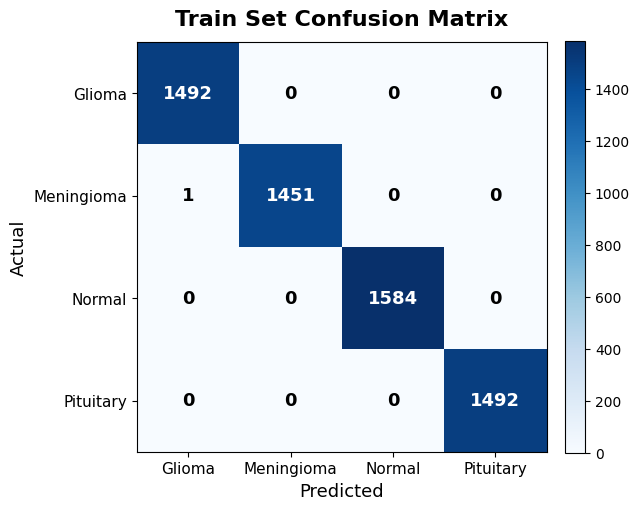

Mean PPV (Precision, macro): 0.9998
Cohen's Kappa: 0.9998
ROC AUC (macro): 1.0000
PR AUC (macro): 1.0000
Train inference time per image: 5.097 ms
Mean Specificity: 0.9999447879858657
Mean NPV: 0.9999452834318232
Bootstrap Accuracy Mean=0.9998, Std=0.0002

--- VALIDATION REPORT ---
              precision    recall  f1-score   support

      Glioma     0.9892    0.9892    0.9892       186
  Meningioma     0.9890    0.9890    0.9890       182
      Normal     1.0000    0.9949    0.9975       198
   Pituitary     0.9947    1.0000    0.9973       186

    accuracy                         0.9934       752
   macro avg     0.9932    0.9933    0.9933       752
weighted avg     0.9934    0.9934    0.9934       752



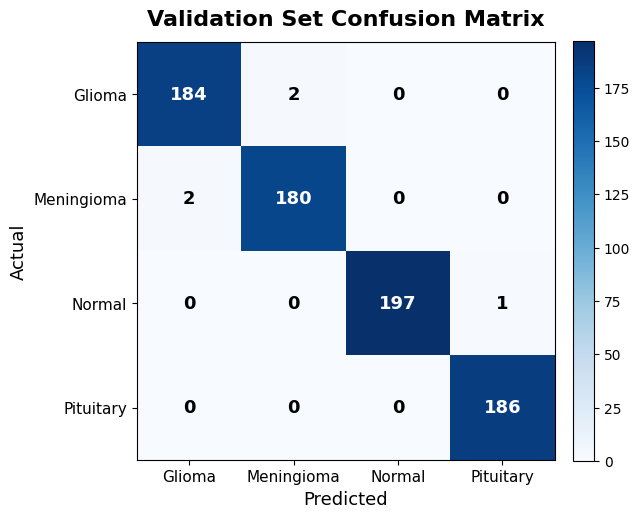

Mean PPV (Precision, macro): 0.9932
Cohen's Kappa: 0.9911
ROC AUC (macro): 0.9999
PR AUC (macro): 0.9997
Validation inference time per image: 5.436 ms
Mean Specificity: 0.9977977186783212
Mean NPV: 0.997788964340945
Bootstrap Accuracy Mean=0.9935, Std=0.0029

--- TEST REPORT ---
              precision    recall  f1-score   support

      Glioma     0.9893    0.9893    0.9893       187
  Meningioma     0.9945    1.0000    0.9972       181
      Normal     0.9949    0.9899    0.9924       198
   Pituitary     1.0000    1.0000    1.0000       187

    accuracy                         0.9947       753
   macro avg     0.9947    0.9948    0.9947       753
weighted avg     0.9947    0.9947    0.9947       753



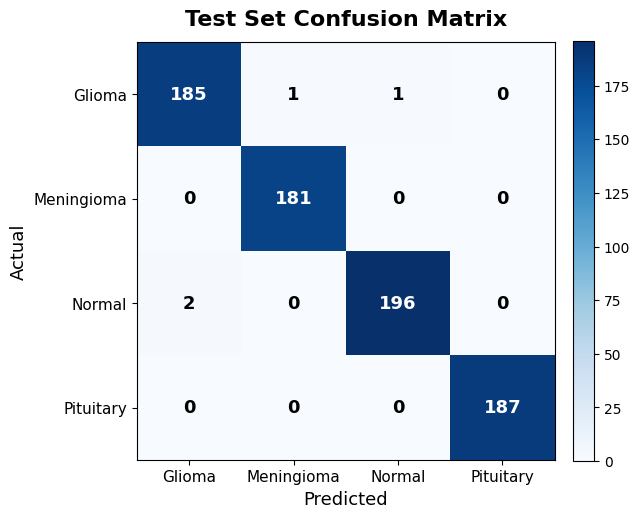

Mean PPV (Precision, macro): 0.9947
Cohen's Kappa: 0.9929
ROC AUC (macro): 0.9999
PR AUC (macro): 0.9996
Test inference time per image: 5.432 ms
Mean Specificity: 0.9982290943863382
Mean NPV: 0.998217327198312
Bootstrap Accuracy Mean=0.9946, Std=0.0026
Accuracy 95% CI: 0.9948 [0.9894, 0.9987]



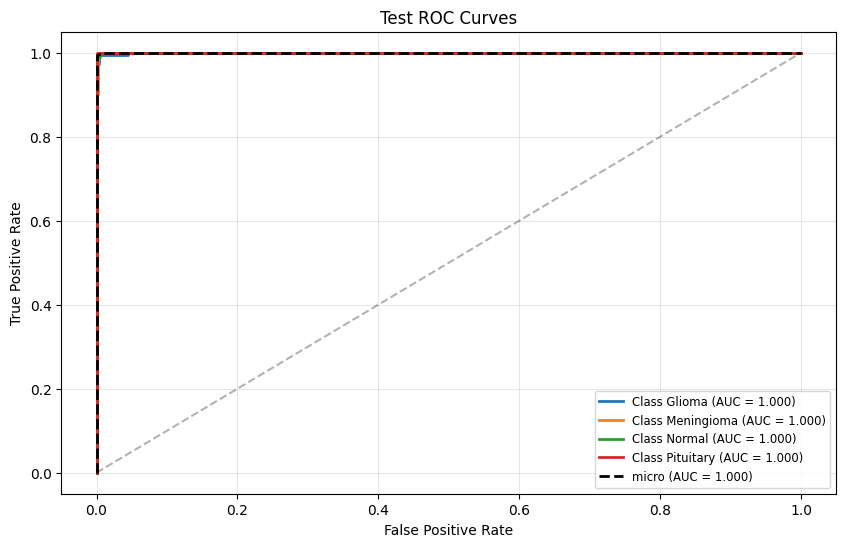

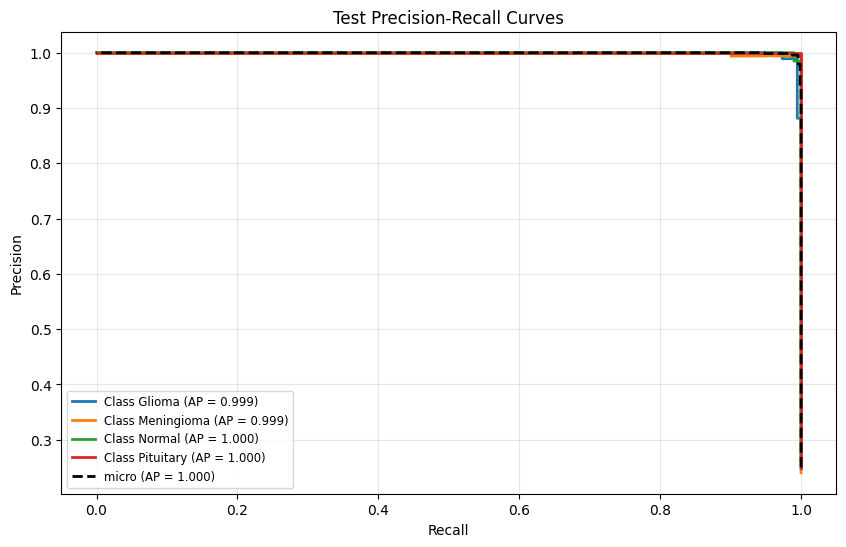



       TIME & MEMORY
Total Training Time: 1371.06 sec
Average Time per Epoch: 91.40 sec
Max GPU Memory Allocated (GB): 4.333298688
Max GPU Memory Reserved  (GB): 4.632608768
CPU RAM Used (GB): 2.695487488
Inference Time per Image: 17.753 ms

Best checkpoint: /kaggle/working/checkpoints/swin_tiny_best.pth


        MODEL SUMMARY
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 96, 56, 56]           4,704
         LayerNorm-2           [-1, 56, 56, 96]             192
        PatchEmbed-3           [-1, 56, 56, 96]               0
          Identity-4           [-1, 56, 56, 96]               0
         LayerNorm-5           [-1, 56, 56, 96]             192
            Linear-6              [-1, 49, 288]          27,936
           Softmax-7            [-1, 3, 49, 49]               0
           Dropout-8            [-1, 3, 49, 49]               0
            Linear-9       

In [8]:
import time, copy, random, os, psutil
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from pathlib import Path
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from timm import create_model
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_score,
    cohen_kappa_score, roc_auc_score, average_precision_score,
    roc_curve, auc, precision_recall_curve
)
from sklearn.preprocessing import label_binarize
from torchsummary import summary

# ---------- CONFIG ----------
DATA_ROOT = Path("/kaggle/working/raw_split")
CKPT_DIR  = Path("/kaggle/working/checkpoints"); CKPT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 40
PATIENCE = 5
LR = 3e-3
WD = 1e-3
DROPOUT = 0.5
SEED = 42
NUM_WORKERS = 2        
MODEL_NAME = "swin_tiny_patch4_window7_224"
PRETRAINED = True

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---------- TRANSFORMS ----------
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# ---------- DATASET Loader ----------
train_ds = datasets.ImageFolder(str(DATA_ROOT/"train"), transform=train_tf)
val_ds   = datasets.ImageFolder(str(DATA_ROOT/"val"),   transform=eval_tf)
test_ds  = datasets.ImageFolder(str(DATA_ROOT/"test"),  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)

class_names = train_ds.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Sizes (train/val/test):", len(train_ds), len(val_ds), len(test_ds))

model = create_model(MODEL_NAME, pretrained=PRETRAINED, num_classes=num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.5, verbose=False
)

best_val = float('inf')
best_wts = copy.deepcopy(model.state_dict())
no_improve = 0
train_start_time = time.time()

# ================
# TRAINING LOOP
# ================
for epoch in range(1, NUM_EPOCHS+1):
    t0 = time.time()
    model.train()
    running_loss = 0.0
    running_correct = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()

        out = model(xb)
        if out.ndim == 4:
            out = out.squeeze(-1).squeeze(-1)

        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        running_correct += (out.argmax(1) == yb).sum().item()

    train_loss = running_loss / len(train_loader.dataset)
    train_acc  = running_correct / len(train_loader.dataset)

    model.eval()
    vloss = 0.0
    vcorrect = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)

            out = model(xb)
            if out.ndim == 4:
                out = out.squeeze(-1).squeeze(-1)

            loss = criterion(out, yb)
            vloss += loss.item() * xb.size(0)
            vcorrect += (out.argmax(1) == yb).sum().item()

    val_loss = vloss / len(val_loader.dataset)
    val_acc  = vcorrect / len(val_loader.dataset)

    scheduler.step(val_loss)
    elapsed = time.time() - t0

    print(f"Epoch {epoch}/{NUM_EPOCHS} — "
          f"train_loss={train_loss:.4f} acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} acc={val_acc:.4f} ({elapsed:.1f}s)")

    # ---------- SAVE BEST ----------
    if val_loss < best_val:
        best_val = val_loss
        best_wts = copy.deepcopy(model.state_dict())
        no_improve = 0
        torch.save(
            {"model": "swin_tiny",
             "epoch": epoch,
             "state_dict": best_wts,
             "val_loss": best_val,
             "classes": class_names},
            str(CKPT_DIR/"swin_tiny_best.pth")
        )
        print("  Saved best model.")
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping (patience={PATIENCE})")
            break

total_training_time = time.time() - train_start_time

# ---------- LOAD BEST ----------
model.load_state_dict(best_wts)

# ============================
# CONFUSION MATRIX + REPORTS 
# ============================
def get_preds_probs_and_time(model, loader):
    """
    Run model on loader and return y_true, y_pred, probs, avg_ms_per_image.
    Handles model outputs that may be spatial (squeeze).
    """
    model.eval()
    y_true = []; y_pred = []; probs = []
    t0 = time.time()
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            out = model(xb)
            if out.ndim == 4:
                out = out.squeeze(-1).squeeze(-1)
            p = torch.softmax(out, dim=1).cpu().numpy()
            preds = out.argmax(1).cpu().numpy()
            probs.extend(p)
            y_pred.extend(preds)
            y_true.extend(yb.numpy())
    elapsed = time.time() - t0
    n = len(y_true) if len(y_true)>0 else 1
    avg_ms = (elapsed / n) * 1000.0
    return np.array(y_true), np.array(y_pred), np.vstack(probs), avg_ms

def plot_confusion(cm, classes, title="Confusion Matrix", cmap="Blues", figsize=(6.5,6.5)):
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm, cmap=cmap)
    ax.set_title(title, fontsize=16, fontweight="700", pad=12)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ticks = np.arange(len(classes))
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(classes, fontsize=11)
    ax.set_yticklabels(classes, fontsize=11)
    ax.set_xlabel("Predicted", fontsize=13)
    ax.set_ylabel("Actual", fontsize=13)

    vmax = cm.max() if cm.max() > 0 else 1
    thresh = vmax / 2.0

    for i in range(len(classes)):
        for j in range(len(classes)):
            val = cm[i, j]
            color = "white" if val > thresh else "black"
            ax.text(j, i, str(val), ha="center", va="center",
                    color=color, fontsize=13, fontweight='700')

    plt.tight_layout()
    return fig, ax

def compute_extra_metrics(cm):
    specificity = []
    npv = []
    for i in range(len(cm)):
        TP = cm[i,i]
        FN = cm[i,:].sum() - TP
        FP = cm[:,i].sum() - TP
        TN = cm.sum() - (TP+FP+FN)
        spec = TN / (TN + FP) if (TN+FP) > 0 else 0.0
        nv   = TN / (TN + FN) if (TN+FN) > 0 else 0.0
        specificity.append(spec)
        npv.append(nv)
    return specificity, npv, float(np.mean(specificity)), float(np.mean(npv))

def bootstrap_accuracy(y_true, y_pred, samples=1000):
    n = len(y_true)
    accs = []
    for _ in range(samples):
        idx = np.random.randint(0, n, n)
        accs.append(np.mean(y_true[idx] == y_pred[idx]))
    return float(np.mean(accs)), float(np.std(accs))

def bootstrap_accuracy_ci(y_true, y_pred, samples=1000, alpha=0.95):
    rng = np.random.RandomState(SEED)
    n = len(y_true)
    accs = []
    for _ in range(samples):
        idx = rng.randint(0, n, n)
        accs.append(np.mean(y_true[idx] == y_pred[idx]))
    mean = float(np.mean(accs))
    lo = float(np.percentile(accs, (1-alpha)/2*100))
    hi = float(np.percentile(accs, (1+alpha)/2*100))
    return mean, lo, hi

display_names = [n.replace("512", "") for n in class_names]

# -------------
# TRAIN REPORT 
# -------------
print("\n--- TRAIN REPORT ---")
yt_train, yp_train, probs_train, train_infer_ms = get_preds_probs_and_time(model, train_loader)
print(classification_report(yt_train, yp_train, target_names=display_names, digits=4))
cm = confusion_matrix(yt_train, yp_train)
plot_confusion(cm, display_names, "Train Set Confusion Matrix")
plt.show()
spec_list, npv_list, mean_spec, mean_npv = compute_extra_metrics(cm)
boot_mean, boot_std = bootstrap_accuracy(yt_train, yp_train, samples=1000)
mean_ppv = precision_score(yt_train, yp_train, average='macro', zero_division=0)
kappa = cohen_kappa_score(yt_train, yp_train)
try:
    y_true_bin = label_binarize(yt_train, classes=list(range(num_classes)))
    roc_auc_macro = roc_auc_score(y_true_bin, probs_train, average='macro', multi_class='ovr')
    pr_auc_macro = average_precision_score(y_true_bin, probs_train, average='macro')
except Exception:
    roc_auc_macro = float('nan'); pr_auc_macro = float('nan')

print(f"Mean PPV (Precision, macro): {mean_ppv:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"ROC AUC (macro): {roc_auc_macro:.4f}")
print(f"PR AUC (macro): {pr_auc_macro:.4f}")
print(f"Train inference time per image: {train_infer_ms:.3f} ms")
print(f"Mean Specificity: {mean_spec}")
print(f"Mean NPV: {mean_npv}")
print(f"Bootstrap Accuracy Mean={boot_mean:.4f}, Std={boot_std:.4f}")

# ------------------
# VALIDATION REPORT 
# ------------------
print("\n--- VALIDATION REPORT ---")
yt_val, yp_val, probs_val, val_infer_ms = get_preds_probs_and_time(model, val_loader)
print(classification_report(yt_val, yp_val, target_names=display_names, digits=4))
cm = confusion_matrix(yt_val, yp_val)
plot_confusion(cm, display_names, "Validation Set Confusion Matrix")
plt.show()
spec_list, npv_list, mean_spec, mean_npv = compute_extra_metrics(cm)
boot_mean, boot_std = bootstrap_accuracy(yt_val, yp_val, samples=1000)
mean_ppv = precision_score(yt_val, yp_val, average='macro', zero_division=0)
kappa = cohen_kappa_score(yt_val, yp_val)
try:
    y_true_bin = label_binarize(yt_val, classes=list(range(num_classes)))
    roc_auc_macro = roc_auc_score(y_true_bin, probs_val, average='macro', multi_class='ovr')
    pr_auc_macro = average_precision_score(y_true_bin, probs_val, average='macro')
except Exception:
    roc_auc_macro = float('nan'); pr_auc_macro = float('nan')

print(f"Mean PPV (Precision, macro): {mean_ppv:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"ROC AUC (macro): {roc_auc_macro:.4f}")
print(f"PR AUC (macro): {pr_auc_macro:.4f}")
print(f"Validation inference time per image: {val_infer_ms:.3f} ms")
print(f"Mean Specificity: {mean_spec}")
print(f"Mean NPV: {mean_npv}")
print(f"Bootstrap Accuracy Mean={boot_mean:.4f}, Std={boot_std:.4f}")

# --------------------------------------------------------------
# TEST REPORT (with extra metrics + ROC/PR plots + Accuracy CI)
# --------------------------------------------------------------
print("\n--- TEST REPORT ---")
yt_test, yp_test, probs_test, test_infer_ms = get_preds_probs_and_time(model, test_loader)
print(classification_report(yt_test, yp_test, target_names=display_names, digits=4))
cm = confusion_matrix(yt_test, yp_test)
plot_confusion(cm, display_names, "Test Set Confusion Matrix")
plt.show()

spec_list, npv_list, mean_spec, mean_npv = compute_extra_metrics(cm)
boot_mean, boot_std = bootstrap_accuracy(yt_test, yp_test, samples=1000)
mean_ppv = precision_score(yt_test, yp_test, average='macro', zero_division=0)
kappa = cohen_kappa_score(yt_test, yp_test)

# ROC AUC & PR AUC (macro)
y_true_bin = label_binarize(yt_test, classes=list(range(num_classes)))
try:
    roc_auc_macro = roc_auc_score(y_true_bin, probs_test, average='macro', multi_class='ovr')
except Exception:
    roc_auc_macro = float('nan')
try:
    pr_auc_macro = average_precision_score(y_true_bin, probs_test, average='macro')
except Exception:
    pr_auc_macro = float('nan')

# Accuracy 95% CI via bootstrap percentiles
acc_mean, acc_lo, acc_hi = bootstrap_accuracy_ci(yt_test, yp_test, samples=1000, alpha=0.95)

print(f"Mean PPV (Precision, macro): {mean_ppv:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"ROC AUC (macro): {roc_auc_macro:.4f}")
print(f"PR AUC (macro): {pr_auc_macro:.4f}")
print(f"Test inference time per image: {test_infer_ms:.3f} ms")
print(f"Mean Specificity: {mean_spec}")
print(f"Mean NPV: {mean_npv}")
print(f"Bootstrap Accuracy Mean={boot_mean:.4f}, Std={boot_std:.4f}")
print(f"Accuracy 95% CI: {acc_mean:.4f} [{acc_lo:.4f}, {acc_hi:.4f}]\n")

# Plot test ROC curve (per-class + micro-average)
try:
    plt.figure(figsize=(10, 6))
    fpr = dict(); tpr = dict(); roc_auc = dict()
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs_test[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], lw=2, label=f"Class {display_names[i]} (AUC = {roc_auc[i]:.3f})")
   
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), probs_test.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    plt.plot(fpr["micro"], tpr["micro"], label=f"micro (AUC = {roc_auc['micro']:.3f})", color='k', linestyle='--', lw=2)
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Test ROC Curves')
    plt.legend(loc='lower right', fontsize='small')
    plt.grid(alpha=0.3)
    plt.show()
except Exception as e:
    print("Could not plot ROC curve:", e)

# Plot test PR curve (per-class + micro-average)
try:
    plt.figure(figsize=(10, 6))
    precision = dict(); recall = dict(); ap = dict()
    for i in range(num_classes):
        precision[i], recall[i], _ = precision_recall_curve(y_true_bin[:, i], probs_test[:, i])
        ap[i] = auc(recall[i], precision[i])  # area under PR curve
        plt.plot(recall[i], precision[i], lw=2, label=f"Class {display_names[i]} (AP = {ap[i]:.3f})")
    # micro-average
    precision["micro"], recall["micro"], _ = precision_recall_curve(y_true_bin.ravel(), probs_test.ravel())
    ap["micro"] = auc(recall["micro"], precision["micro"])
    plt.plot(recall["micro"], precision["micro"], label=f"micro (AP = {ap['micro']:.3f})", color='k', linestyle='--', lw=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Test Precision-Recall Curves')
    plt.legend(loc='lower left', fontsize='small')
    plt.grid(alpha=0.3)
    plt.show()
except Exception as e:
    print("Could not plot PR curve:", e)

# ======================================
#         Timing & Memory Usage
# ======================================
print("\n\n============================")
print("       TIME & MEMORY")
print("============================")
try:
    print(f"Total Training Time: {total_training_time:.2f} sec")
except NameError:
    print(f"Total Training Time: {total_training_time if 'total_training_time' in globals() else 'N/A'}")

try:
    used_epochs = epoch
    print(f"Average Time per Epoch: {total_training_time/used_epochs:.2f} sec")
except Exception:
    pass

if torch.cuda.is_available():
    print("Max GPU Memory Allocated (GB):", torch.cuda.max_memory_allocated() / 1e9)
    print("Max GPU Memory Reserved  (GB):", torch.cuda.max_memory_reserved() / 1e9)

print("CPU RAM Used (GB):", psutil.Process(os.getpid()).memory_info().rss / 1e9)

sample = torch.randn(1,3,IMG_SIZE,IMG_SIZE).to(device)
t0 = time.time()
_ = model(sample)
infer_time = time.time() - t0
print(f"Inference Time per Image: {infer_time*1000:.3f} ms")

print("\nBest checkpoint:", CKPT_DIR/"swin_tiny_best.pth")

print("\n\n============================")
print("        MODEL SUMMARY")
print("============================")
summary(model, (3, IMG_SIZE, IMG_SIZE))

# **DenseNet-121 Model Training**

Device: cuda
Classes: ['512Glioma', '512Meningioma', '512Normal', '512Pituitary']
Sizes (train/val/test): 6020 752 753


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 167MB/s] 


Epoch 1/40 — train_loss(loop)=0.5986 train_eval_loss=0.5937 train_acc=0.7945 | val_loss=0.5287 val_acc=0.8045 | time=82.1s
  Saved best model.
Epoch 2/40 — train_loss(loop)=0.3308 train_eval_loss=0.7822 train_acc=0.7786 | val_loss=0.7854 val_acc=0.7846 | time=90.5s
Epoch 3/40 — train_loss(loop)=0.2608 train_eval_loss=0.7861 train_acc=0.7656 | val_loss=0.8064 val_acc=0.7620 | time=89.8s
Epoch 4/40 — train_loss(loop)=0.2465 train_eval_loss=0.2483 train_acc=0.9158 | val_loss=0.2583 val_acc=0.9016 | time=89.4s
  Saved best model.
Epoch 5/40 — train_loss(loop)=0.1723 train_eval_loss=2.2772 train_acc=0.6229 | val_loss=2.0721 val_acc=0.6330 | time=90.2s
Epoch 6/40 — train_loss(loop)=0.1469 train_eval_loss=0.0818 train_acc=0.9719 | val_loss=0.0959 val_acc=0.9747 | time=89.9s
  Saved best model.
Epoch 7/40 — train_loss(loop)=0.1337 train_eval_loss=0.3801 train_acc=0.8869 | val_loss=0.3523 val_acc=0.9003 | time=89.3s
Epoch 8/40 — train_loss(loop)=0.1134 train_eval_loss=0.2758 train_acc=0.8970 | 

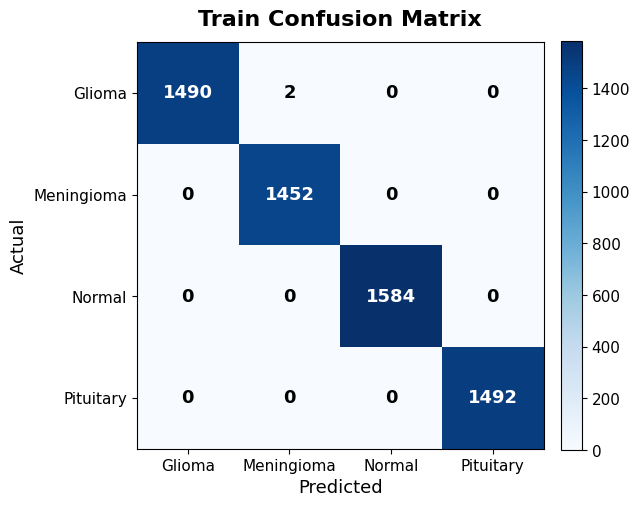

Mean PPV (Precision, macro): 0.9997
Cohen's Kappa: 0.9996
ROC AUC (macro): 1.0000
PR AUC (macro): 1.0000
Train inference time per image: 3.443 ms
Mean Specificity: 0.9998905429071804
Mean NPV: 0.9998896247240618
Bootstrap Accuracy Mean=0.9997, Std=0.0002

=== VAL REPORT ===
              precision    recall  f1-score   support

      Glioma     1.0000    0.9946    0.9973       186
  Meningioma     1.0000    1.0000    1.0000       182
      Normal     0.9950    1.0000    0.9975       198
   Pituitary     1.0000    1.0000    1.0000       186

    accuracy                         0.9987       752
   macro avg     0.9987    0.9987    0.9987       752
weighted avg     0.9987    0.9987    0.9987       752



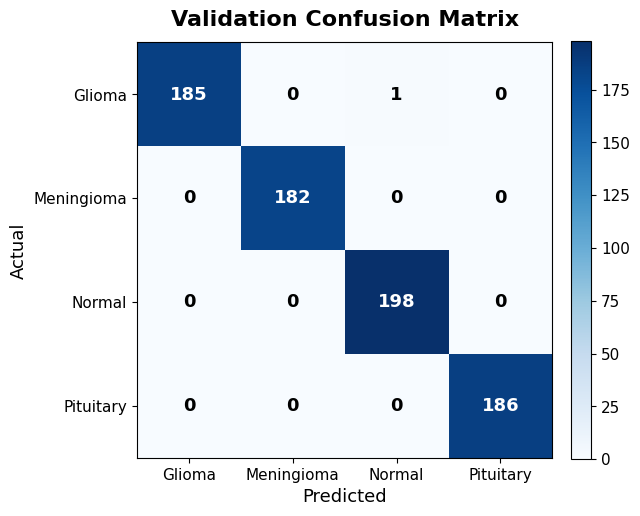

Mean PPV (Precision, macro): 0.9987
Cohen's Kappa: 0.9982
ROC AUC (macro): 1.0000
PR AUC (macro): 1.0000
Validation inference time per image: 3.744 ms
Mean Specificity: 0.9995487364620939
Mean NPV: 0.9995590828924162
Bootstrap Accuracy Mean=0.9987, Std=0.0013

=== TEST REPORT ===
              precision    recall  f1-score   support

      Glioma     0.9891    0.9733    0.9811       187
  Meningioma     0.9781    0.9890    0.9835       181
      Normal     0.9899    0.9949    0.9924       198
   Pituitary     1.0000    1.0000    1.0000       187

    accuracy                         0.9894       753
   macro avg     0.9893    0.9893    0.9893       753
weighted avg     0.9894    0.9894    0.9894       753



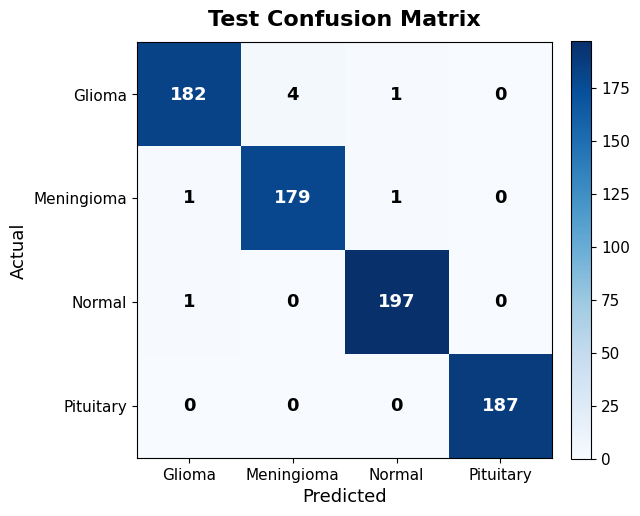

Mean PPV (Precision, macro): 0.9893
Cohen's Kappa: 0.9858
ROC AUC (macro): 0.9999
PR AUC (macro): 0.9996
Test inference time per image: 3.842 ms
Mean Specificity: 0.9964674551246989
Mean NPV: 0.9964747069242774
Bootstrap Accuracy Mean=0.9893, Std=0.0038
Accuracy 95% CI: 0.9894 [0.9814, 0.9960]



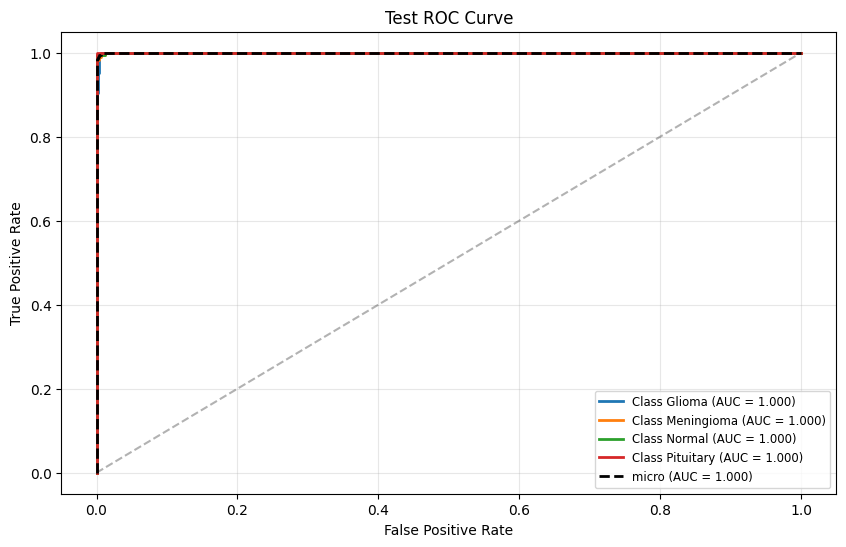

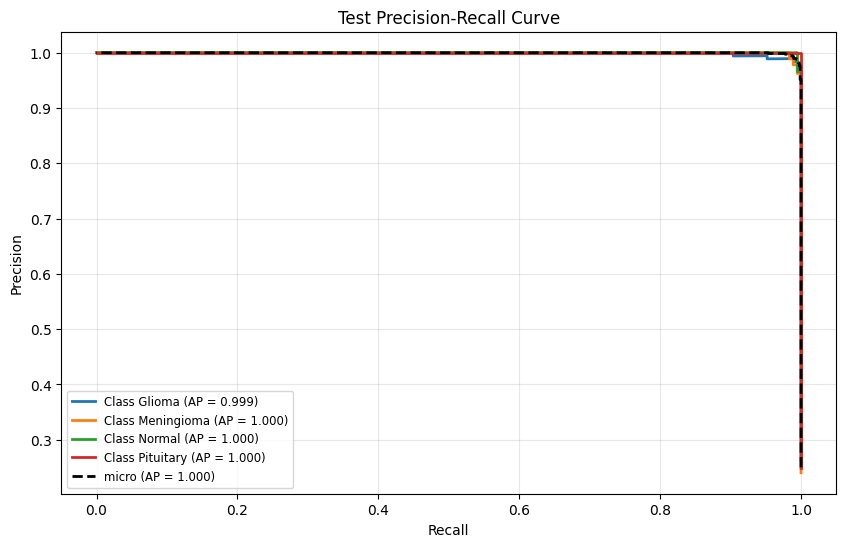



       TIME & MEMORY
Total Training Time: 2496.24 sec
Average Time per Epoch: 89.15 sec
Max GPU Memory Allocated: 4.375142912 GB
Max GPU Memory Reserved : 4.924112896 GB
CPU RAM Used: 2.196201472 GB
Inference Time per Image: 84.042 ms


        MODEL SUMMARY
Layer (type:depth-idx)                   Output Shape              Param #
DenseNet                                 [1, 4]                    --
├─Sequential: 1-1                        [1, 1024, 7, 7]           --
│    └─Conv2d: 2-1                       [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         128
│    └─ReLU: 2-3                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                    [1, 64, 56, 56]           --
│    └─_DenseBlock: 2-5                  [1, 256, 56, 56]          --
│    │    └─_DenseLayer: 3-1             [1, 32, 56, 56]           45,440
│    │    └─_DenseLayer: 3-2             [1, 32, 56, 56]           49,600
│    │    └─_DenseLaye

In [7]:
import time, copy, random, os, psutil
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from pathlib import Path
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, cohen_kappa_score,
    roc_auc_score, average_precision_score,
    roc_curve, auc, precision_recall_curve
)
from sklearn.preprocessing import label_binarize

# ---------- CONFIG ----------
DATA_ROOT = Path("/kaggle/working/raw_split")
CKPT_DIR  = Path("/kaggle/working/checkpoints"); CKPT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 40
PATIENCE = 5
LR = 3e-3
WD = 1e-3
DROPOUT = 0.5
SEED = 42
NUM_WORKERS = 2
PRETRAINED = True
# ------------------------

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# transforms
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# datasets/loaders
train_ds = datasets.ImageFolder(str(DATA_ROOT/"train"), transform=train_tf)
val_ds   = datasets.ImageFolder(str(DATA_ROOT/"val"),   transform=eval_tf)
test_ds  = datasets.ImageFolder(str(DATA_ROOT/"test"),  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

class_names = train_ds.classes
display_names = [c.replace("512","") for c in class_names]
num_classes = len(class_names)

print("Classes:", class_names)
print("Sizes (train/val/test):", len(train_ds), len(val_ds), len(test_ds))


# === Build DenseNet-121 ===
if PRETRAINED:
    try:
        # modern API: weights argument
        model = models.densenet121(weights="IMAGENET1K_V1")
    except Exception:
        # fallback for older torchvision: pretrained flag
        model = models.densenet121(pretrained=True)
else:
    model = models.densenet121(weights=None)

in_feats = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(DROPOUT),
    nn.Linear(in_feats, num_classes)
)
model = model.to(device)

# loss/optimizer/scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

# ---- Train loop ----
def evaluate_split(model, loader, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    n = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device); yb = yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            total_loss += loss.item() * xb.size(0)
            preds = out.argmax(1)
            correct += (preds == yb).sum().item()
            n += xb.size(0)
    avg_loss = total_loss / n if n > 0 else 0.0
    acc = correct / n if n > 0 else 0.0
    return avg_loss, acc

best_val = float('inf')
best_wts = copy.deepcopy(model.state_dict())
no_improve = 0
train_start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    model.train()
    train_loss_sum = 0.0
    train_samples = 0

    for xb, yb in train_loader:
        xb = xb.to(device); yb = yb.to(device)

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * xb.size(0)
        train_samples += xb.size(0)

  
    train_loss = train_loss_sum / train_samples if train_samples > 0 else 0.0

    # compute true train accuracy (evaluation pass) — robust
    train_eval_loss, train_acc = evaluate_split(model, train_loader, device)

    # validation
    val_loss, val_acc = evaluate_split(model, val_loader, device)

    # scheduler step uses validation loss
    scheduler.step(val_loss)

    print(f"Epoch {epoch}/{NUM_EPOCHS} — "
          f"train_loss(loop)={train_loss:.4f} train_eval_loss={train_eval_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
          f"time={time.time()-t0:.1f}s")

    # checkpoint
    if val_loss < best_val:
        best_val = val_loss
        best_wts = copy.deepcopy(model.state_dict())
        no_improve = 0
        torch.save({
            "model":"densenet121",
            "epoch":epoch,
            "state_dict":best_wts,
            "val_loss":best_val,
            "classes":class_names
        }, str(CKPT_DIR/"densenet121_best.pth"))
        print("  Saved best model.")
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print("Early stopping.")
            break

model.load_state_dict(best_wts)
total_training_time = time.time() - train_start_time

# ===== Evaluation helpers =====
def get_preds_probs_and_time(model, loader):
    """
    Returns y_true (np), y_pred (np), probs (np: N x C), avg_ms_per_image (float)
    """
    model.eval()
    y_true = []; y_pred = []; probs = []
    t0 = time.time()
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            out = model(xb)                      # (N, C)
            p = torch.softmax(out, dim=1).cpu().numpy()
            preds = out.argmax(1).cpu().numpy()
            probs.append(p)
            y_pred.extend(preds)
            y_true.extend(yb.numpy())
    elapsed = time.time() - t0
    if len(y_true) == 0:
        avg_ms = 0.0
        probs_arr = np.zeros((0, num_classes))
    else:
        avg_ms = (elapsed / len(y_true)) * 1000.0
        probs_arr = np.vstack(probs)
    return np.array(y_true), np.array(y_pred), probs_arr, avg_ms


def get_preds(model, loader):
    model.eval()
    y_true = []; y_pred = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            out = model(xb)
            y_pred.extend(out.argmax(1).cpu().numpy())
            y_true.extend(yb.numpy())
    return np.array(y_true), np.array(y_pred)


# >>>>> Confusion matrix <<<<<
def plot_confusion(cm, labels, title):
    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title, fontsize=16, fontweight="700", pad=12)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=11)

    ticks = np.arange(len(labels))
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_yticklabels(labels, fontsize=11)
    ax.set_xlabel("Predicted", fontsize=13)
    ax.set_ylabel("Actual", fontsize=13)

    vmax = cm.max() if cm.max() > 0 else 1
    thresh = vmax / 2.0

    for i in range(len(labels)):
        for j in range(len(labels)):
            val = cm[i, j]
            color = "white" if val > thresh else "black"
            ax.text(j, i, str(val), ha="center", va="center",
                    color=color, fontsize=13, fontweight='700')

    plt.tight_layout()
    return fig

def compute_extra_metrics(cm):
    specificity = []
    npv = []
    for i in range(len(cm)):
        TP = cm[i,i]
        FN = cm[i,:].sum() - TP
        FP = cm[:,i].sum() - TP
        TN = cm.sum() - (TP + FP + FN)
        spec = TN / (TN + FP) if (TN+FP) > 0 else 0
        nv   = TN / (TN + FN) if (TN+FN) > 0 else 0
        specificity.append(spec)
        npv.append(nv)
    return np.mean(specificity), np.mean(np.array(npv))


def bootstrap_accuracy(y_true, y_pred, samples=1000):
    accs = []
    n = len(y_true)
    for _ in range(samples):
        idx = np.random.randint(0, n, n)
        accs.append(np.mean(y_true[idx] == y_pred[idx]))
    return np.mean(accs), np.std(accs)


def bootstrap_accuracy_ci(y_true, y_pred, samples=1000, alpha=0.95):
    rng = np.random.RandomState(SEED)
    n = len(y_true)
    accs = []
    for _ in range(samples):
        idx = rng.randint(0, n, n)
        accs.append(np.mean(y_true[idx] == y_pred[idx]))
    mean = float(np.mean(accs))
    lo = float(np.percentile(accs, (1-alpha)/2*100))
    hi = float(np.percentile(accs, (1+alpha)/2*100))
    return mean, lo, hi

print("\n=== TRAIN REPORT ===")
yt_train, yp_train, probs_train, train_ms = get_preds_probs_and_time(model, train_loader)
cm = confusion_matrix(yt_train, yp_train)
print(classification_report(yt_train, yp_train, target_names=display_names, digits=4))
plot_confusion(cm, display_names, "Train Confusion Matrix")
plt.show()

mean_spec, mean_npv = compute_extra_metrics(cm)
boot_mean, boot_std = bootstrap_accuracy(yt_train, yp_train)
mean_ppv = precision_score(yt_train, yp_train, average='macro', zero_division=0)
kappa = cohen_kappa_score(yt_train, yp_train)

# ROC AUC and PR AUC (macro); handle binary vs multiclass
try:
    if num_classes == 2:
        roc_auc_macro = roc_auc_score(yt_train, probs_train[:,1])
        pr_auc_macro = average_precision_score(yt_train, probs_train[:,1])
    else:
        y_true_bin = label_binarize(yt_train, classes=list(range(num_classes)))
        roc_auc_macro = roc_auc_score(y_true_bin, probs_train, average='macro', multi_class='ovr')
        pr_auc_macro = average_precision_score(y_true_bin, probs_train, average='macro')
except Exception:
    roc_auc_macro = float('nan'); pr_auc_macro = float('nan')

print(f"Mean PPV (Precision, macro): {mean_ppv:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"ROC AUC (macro): {roc_auc_macro:.4f}")
print(f"PR AUC (macro): {pr_auc_macro:.4f}")
print(f"Train inference time per image: {train_ms:.3f} ms")
print(f"Mean Specificity: {mean_spec}")
print(f"Mean NPV: {mean_npv}")
print(f"Bootstrap Accuracy Mean={boot_mean:.4f}, Std={boot_std:.4f}")

print("\n=== VAL REPORT ===")
yt_val, yp_val, probs_val, val_ms = get_preds_probs_and_time(model, val_loader)
cm = confusion_matrix(yt_val, yp_val)
print(classification_report(yt_val, yp_val, target_names=display_names, digits=4))
plot_confusion(cm, display_names, "Validation Confusion Matrix")
plt.show()

mean_spec, mean_npv = compute_extra_metrics(cm)
boot_mean, boot_std = bootstrap_accuracy(yt_val, yp_val)
mean_ppv = precision_score(yt_val, yp_val, average='macro', zero_division=0)
kappa = cohen_kappa_score(yt_val, yp_val)
try:
    if num_classes == 2:
        roc_auc_macro = roc_auc_score(yt_val, probs_val[:,1])
        pr_auc_macro = average_precision_score(yt_val, probs_val[:,1])
    else:
        y_true_bin = label_binarize(yt_val, classes=list(range(num_classes)))
        roc_auc_macro = roc_auc_score(y_true_bin, probs_val, average='macro', multi_class='ovr')
        pr_auc_macro = average_precision_score(y_true_bin, probs_val, average='macro')
except Exception:
    roc_auc_macro = float('nan'); pr_auc_macro = float('nan')

print(f"Mean PPV (Precision, macro): {mean_ppv:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"ROC AUC (macro): {roc_auc_macro:.4f}")
print(f"PR AUC (macro): {pr_auc_macro:.4f}")
print(f"Validation inference time per image: {val_ms:.3f} ms")
print(f"Mean Specificity: {mean_spec}")
print(f"Mean NPV: {mean_npv}")
print(f"Bootstrap Accuracy Mean={boot_mean:.4f}, Std={boot_std:.4f}")

print("\n=== TEST REPORT ===")
yt_test, yp_test, probs_test, test_ms = get_preds_probs_and_time(model, test_loader)
cm = confusion_matrix(yt_test, yp_test)
print(classification_report(yt_test, yp_test, target_names=display_names, digits=4))
plot_confusion(cm, display_names, "Test Confusion Matrix")
plt.show()

mean_spec, mean_npv = compute_extra_metrics(cm)
boot_mean, boot_std = bootstrap_accuracy(yt_test, yp_test)
mean_ppv = precision_score(yt_test, yp_test, average='macro', zero_division=0)
kappa = cohen_kappa_score(yt_test, yp_test)

# ROC AUC and PR AUC (macro) for test set
try:
    if num_classes == 2:
        roc_auc_macro = roc_auc_score(yt_test, probs_test[:,1])
        pr_auc_macro = average_precision_score(yt_test, probs_test[:,1])
    else:
        y_true_bin = label_binarize(yt_test, classes=list(range(num_classes)))
        roc_auc_macro = roc_auc_score(y_true_bin, probs_test, average='macro', multi_class='ovr')
        pr_auc_macro = average_precision_score(y_true_bin, probs_test, average='macro')
except Exception:
    roc_auc_macro = float('nan'); pr_auc_macro = float('nan')

acc_mean, acc_lo, acc_hi = bootstrap_accuracy_ci(yt_test, yp_test, samples=1000, alpha=0.95)

print(f"Mean PPV (Precision, macro): {mean_ppv:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"ROC AUC (macro): {roc_auc_macro:.4f}")
print(f"PR AUC (macro): {pr_auc_macro:.4f}")
print(f"Test inference time per image: {test_ms:.3f} ms")
print(f"Mean Specificity: {mean_spec}")
print(f"Mean NPV: {mean_npv}")
print(f"Bootstrap Accuracy Mean={boot_mean:.4f}, Std={boot_std:.4f}")
print(f"Accuracy 95% CI: {acc_mean:.4f} [{acc_lo:.4f}, {acc_hi:.4f}]\n")

# Plot test ROC curve (per-class + micro-average)
try:
    plt.figure(figsize=(10, 6))
    if num_classes == 2:
        fpr, tpr, _ = roc_curve(yt_test, probs_test[:, 1])
        roc_auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"ROC (AUC = {roc_auc_val:.3f})")
    else:
        fpr = dict(); tpr = dict(); roc_auc = dict()
        for i in range(num_classes):
            fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs_test[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
            plt.plot(fpr[i], tpr[i], lw=2, label=f"Class {display_names[i]} (AUC = {roc_auc[i]:.3f})")
        fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), probs_test.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
        plt.plot(fpr["micro"], tpr["micro"], label=f"micro (AUC = {roc_auc['micro']:.3f})", color='k', linestyle='--', lw=2)
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Test ROC Curve')
    plt.legend(loc='lower right', fontsize='small')
    plt.grid(alpha=0.3)
    plt.show()
except Exception as e:
    print("Could not plot ROC curve:", e)

# Plot test PR curve (per-class + micro-average)
try:
    plt.figure(figsize=(10, 6))
    if num_classes == 2:
        precision, recall, _ = precision_recall_curve(yt_test, probs_test[:, 1])
        ap_val = auc(recall, precision)
        plt.plot(recall, precision, lw=2, label=f"PR (AP = {ap_val:.3f})")
    else:
        precision = dict(); recall = dict(); ap = dict()
        for i in range(num_classes):
            precision[i], recall[i], _ = precision_recall_curve(y_true_bin[:, i], probs_test[:, i])
            ap[i] = auc(recall[i], precision[i])
            plt.plot(recall[i], precision[i], lw=2, label=f"Class {display_names[i]} (AP = {ap[i]:.3f})")
        precision["micro"], recall["micro"], _ = precision_recall_curve(y_true_bin.ravel(), probs_test.ravel())
        ap["micro"] = auc(recall["micro"], precision["micro"])
        plt.plot(recall["micro"], precision["micro"], label=f"micro (AP = {ap['micro']:.3f})", color='k', linestyle='--', lw=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Test Precision-Recall Curve')
    plt.legend(loc='lower left', fontsize='small')
    plt.grid(alpha=0.3)
    plt.show()
except Exception as e:
    print("Could not plot PR curve:", e)

# ===== TIME & MEMORY =====
print("\n\n============================")
print("       TIME & MEMORY")
print("============================")
print(f"Total Training Time: {total_training_time:.2f} sec")
print(f"Average Time per Epoch: {total_training_time/epoch:.2f} sec")

if torch.cuda.is_available():
    print("Max GPU Memory Allocated:", torch.cuda.max_memory_allocated() / 1e9, "GB")
    print("Max GPU Memory Reserved :", torch.cuda.max_memory_reserved() / 1e9, "GB")

print("CPU RAM Used:", psutil.Process(os.getpid()).memory_info().rss / 1e9, "GB")

sample = torch.randn(1,3,IMG_SIZE,IMG_SIZE).to(device)
t0 = time.time()
out = model(sample)
infer_time = time.time() - t0
print(f"Inference Time per Image: {infer_time*1000:.3f} ms")

try:
    from torchinfo import summary as torchinfo_summary
    print("\n\n============================")
    print("        MODEL SUMMARY")
    print("============================")
    torchinfo_summary(model, input_size=(1, 3, IMG_SIZE, IMG_SIZE), verbose=1)
except Exception as e:
    print("\n=== MODEL SUMMARY (fallback) ===\n")
    print("torchinfo.summary failed:", repr(e))
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total params     : {total_params:,}")
    print(f"Trainable params : {trainable_params:,}")

print("\nBest checkpoint saved at:", CKPT_DIR/"densenet121_best.pth")

# **Levit_128 Model Training**

Device: cuda
Classes: ['512Glioma', '512Meningioma', '512Normal', '512Pituitary']
Sizes (train/val/test): 6020 752 753
Epoch 1/40 — train_loss=0.5254 acc=0.8384 | val_loss=0.3766 acc=0.8830 (19.8s)
  Saved best model.
Epoch 2/40 — train_loss=0.2011 acc=0.9364 | val_loss=0.2626 acc=0.9601 (19.6s)
  Saved best model.
Epoch 3/40 — train_loss=0.0952 acc=0.9711 | val_loss=1.4628 acc=0.9787 (19.5s)
Epoch 4/40 — train_loss=0.0508 acc=0.9844 | val_loss=0.2387 acc=0.9814 (19.7s)
  Saved best model.
Epoch 5/40 — train_loss=0.0420 acc=0.9885 | val_loss=0.1416 acc=0.9867 (19.7s)
  Saved best model.
Epoch 6/40 — train_loss=0.0358 acc=0.9900 | val_loss=0.3617 acc=0.9867 (19.8s)
Epoch 7/40 — train_loss=0.0193 acc=0.9945 | val_loss=0.3856 acc=0.9907 (19.9s)
Epoch 8/40 — train_loss=0.0289 acc=0.9895 | val_loss=0.4386 acc=0.9867 (19.1s)
Epoch 9/40 — train_loss=0.0180 acc=0.9958 | val_loss=0.7449 acc=0.9920 (19.7s)
Epoch 10/40 — train_loss=0.0096 acc=0.9977 | val_loss=7.9374 acc=0.9920 (19.4s)
Early stop

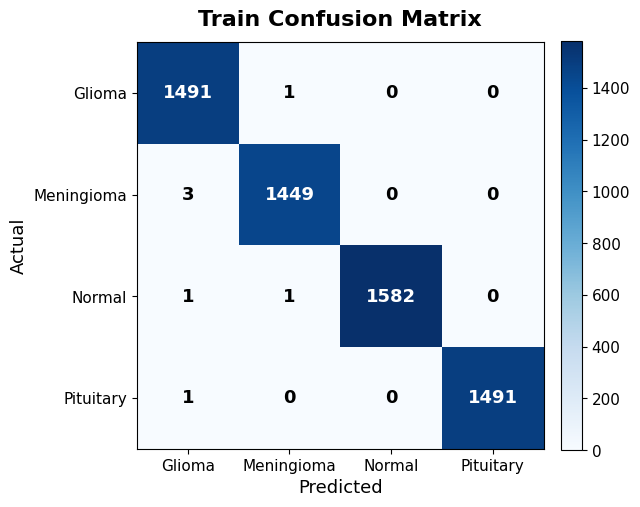

Mean PPV (Precision): 0.9988
Cohen's Kappa: 0.9984
ROC-AUC (macro): 0.9998
PR-AUC (macro): 0.9999
Train inference time per image: 2.5543 ms
Mean Specificity: 0.999614
Mean NPV: 0.999613

================ VALIDATION SET ================
              precision    recall  f1-score   support

      Glioma     0.9785    0.9785    0.9785       186
  Meningioma     0.9781    0.9835    0.9808       182
      Normal     0.9949    0.9899    0.9924       198
   Pituitary     1.0000    1.0000    1.0000       186

    accuracy                         0.9880       752
   macro avg     0.9879    0.9880    0.9879       752
weighted avg     0.9881    0.9880    0.9880       752



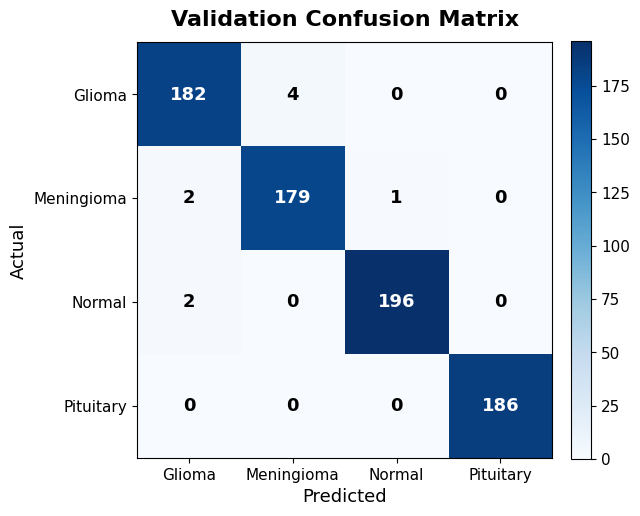

Mean PPV (Precision): 0.9879
Cohen's Kappa: 0.9840
ROC-AUC (macro): 0.9977
PR-AUC (macro): 0.9910
Validation inference time per image: 2.9806 ms
Mean Specificity: 0.996028
Mean NPV: 0.996014

================ TEST SET ================
              precision    recall  f1-score   support

      Glioma     0.9892    0.9786    0.9839       187
  Meningioma     0.9780    0.9834    0.9807       181
      Normal     1.0000    1.0000    1.0000       198
   Pituitary     0.9947    1.0000    0.9973       187

    accuracy                         0.9907       753
   macro avg     0.9905    0.9905    0.9905       753
weighted avg     0.9907    0.9907    0.9907       753



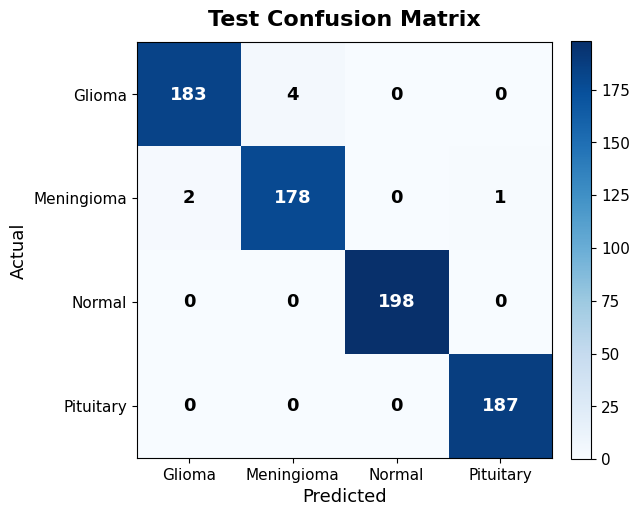

Mean PPV (Precision): 0.9905
Cohen's Kappa: 0.9876
ROC-AUC (macro): 0.9997
PR-AUC (macro): 0.9990
Test inference time per image: 2.9696 ms
Accuracy 95% CI: 0.9907 [0.9827, 0.9973]
Mean Specificity: 0.996927
Mean NPV: 0.996926


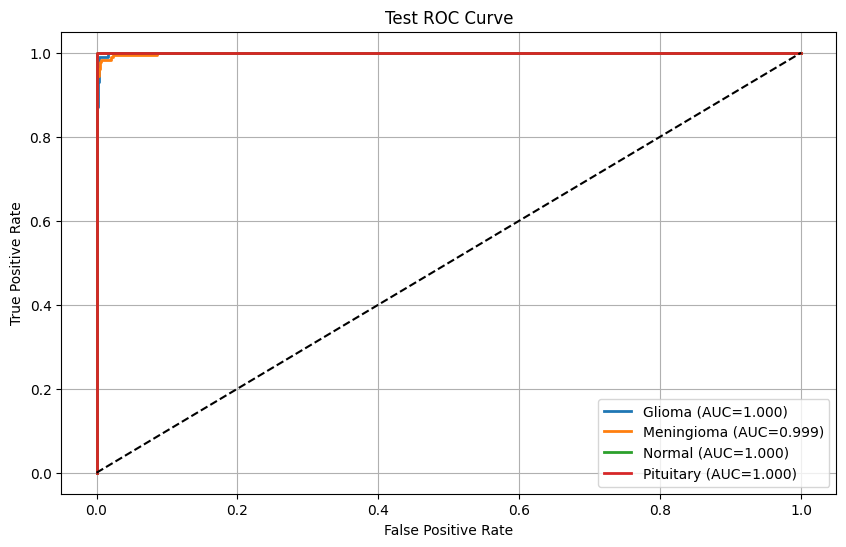

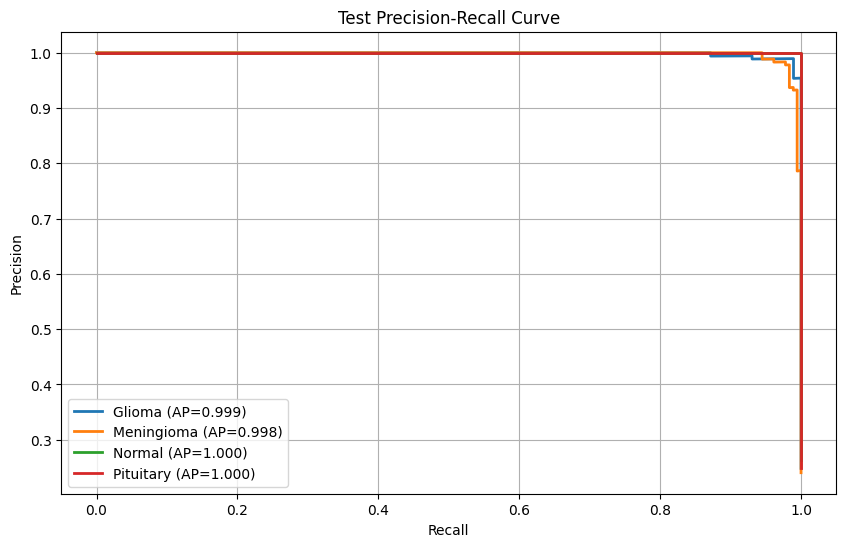



       TIME & MEMORY
Total Training Time: 196.71 sec
Avg Time/Epoch: 19.67 sec
Max GPU Memory Allocated: 1.043271168 GB
CPU RAM Used: 2.57609728 GB
Inference Time/Single Image: 17.184019088745117 ms


        MODEL SUMMARY
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 112, 112]             432
       BatchNorm2d-2         [-1, 16, 112, 112]              32
          ConvNorm-3         [-1, 16, 112, 112]               0
         Hardswish-4         [-1, 16, 112, 112]               0
            Conv2d-5           [-1, 32, 56, 56]           4,608
       BatchNorm2d-6           [-1, 32, 56, 56]              64
          ConvNorm-7           [-1, 32, 56, 56]               0
         Hardswish-8           [-1, 32, 56, 56]               0
            Conv2d-9           [-1, 64, 28, 28]          18,432
      BatchNorm2d-10           [-1, 64, 28, 28]             128
      

In [8]:
import time, copy, random, os, psutil
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from pathlib import Path
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from timm import create_model
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, cohen_kappa_score,
    roc_auc_score, average_precision_score,
    roc_curve, auc, precision_recall_curve
)
from sklearn.preprocessing import label_binarize
from torchsummary import summary

# ---------- CONFIG ----------
DATA_ROOT = Path("/kaggle/working/raw_split")
CKPT_DIR  = Path("/kaggle/working/checkpoints"); CKPT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 40
PATIENCE = 5
LR = 3e-3
WD = 1e-3
DROPOUT = 0.5
SEED = 42
NUM_WORKERS = 2
PRETRAINED = True
MODEL_NAME = "levit_128"
# ------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# transforms
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# datasets/loaders
train_ds = datasets.ImageFolder(str(DATA_ROOT/"train"), transform=train_tf)
val_ds   = datasets.ImageFolder(str(DATA_ROOT/"val"),   transform=eval_tf)
test_ds  = datasets.ImageFolder(str(DATA_ROOT/"test"),  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

class_names = train_ds.classes
num_classes = len(class_names)
display_names = [c.replace("512","") for c in class_names]

print("Classes:", class_names)
print("Sizes (train/val/test):", len(train_ds), len(val_ds), len(test_ds))

# -------------------------
# Build LeViT model
# -------------------------
model = create_model(MODEL_NAME, pretrained=PRETRAINED, num_classes=num_classes, drop_rate=DROPOUT).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

# training loop
best_val = float('inf')
best_wts = copy.deepcopy(model.state_dict())
no_improve = 0
train_start_time = time.time()

for epoch in range(1, NUM_EPOCHS+1):
    t0 = time.time()
    model.train()
    running_loss = 0.0
    running_correct = 0

    for xb, yb in train_loader:
        xb = xb.to(device); yb = yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        running_correct += (out.argmax(1) == yb).sum().item()

    train_loss = running_loss / len(train_loader.dataset)
    train_acc  = running_correct / len(train_loader.dataset)

    model.eval()
    vloss = 0.0; vcorrect = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device); yb = yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            vloss += loss.item() * xb.size(0)
            vcorrect += (out.argmax(1) == yb).sum().item()

    val_loss = vloss / len(val_loader.dataset)
    val_acc  = vcorrect / len(val_loader.dataset)
    scheduler.step(val_loss)

    print(f"Epoch {epoch}/{NUM_EPOCHS} — "
          f"train_loss={train_loss:.4f} acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} acc={val_acc:.4f} ({time.time()-t0:.1f}s)")

    # checkpoint
    if val_loss < best_val:
        best_val = val_loss
        best_wts = copy.deepcopy(model.state_dict())
        no_improve = 0
        torch.save({
            "model":"levit",
            "epoch":epoch,
            "state_dict":best_wts,
            "val_loss":best_val,
            "classes":class_names},
            str(CKPT_DIR/"levit_best.pth"))
        print("  Saved best model.")
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print("Early stopping.")
            break

model.load_state_dict(best_wts)
total_training_time = time.time() - train_start_time

# ===================================================================
# NEW HELPER — returns labels, preds, probabilities, avg inference ms
# ===================================================================
def get_preds_probs_and_time(model, loader):
    model.eval()
    y_true = []; y_pred = []; probs = []
    t0 = time.time()

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            out = model(xb)
            soft = torch.softmax(out, dim=1).cpu().numpy()
            preds = out.argmax(1).cpu().numpy()

            probs.append(soft)
            y_pred.extend(preds)
            y_true.extend(yb.numpy())

    elapsed = time.time() - t0
    avg_ms = (elapsed / len(y_true)) * 1000
    probs = np.vstack(probs)
    return np.array(y_true), np.array(y_pred), probs, avg_ms
    
# ============================================
# CONFUSION MATRIX PLOTTER
# ============================================
def plot_confusion(cm, classes, title="Confusion Matrix", cmap="Blues", figsize=(6.5, 6.5)):
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm, cmap=cmap)

    ax.set_title(title, fontsize=16, fontweight="700", pad=12)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=11)

    ticks = np.arange(len(classes))
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(classes, fontsize=11)
    ax.set_yticklabels(classes, fontsize=11)
    ax.set_xlabel("Predicted", fontsize=13)
    ax.set_ylabel("Actual", fontsize=13)

    vmax = cm.max() if cm.max() > 0 else 1
    thresh = vmax / 2.0

    for i in range(len(classes)):
        for j in range(len(classes)):
            val = cm[i, j]
            color = "white" if val > thresh else "black"
            ax.text(j, i, str(val), ha="center", va="center",
                    color=color, fontsize=13, fontweight='700')

    plt.tight_layout()
    return fig
    
def compute_extra_metrics(cm):
    specificity = []; npv = []
    for i in range(len(cm)):
        TP = cm[i,i]
        FN = cm[i,:].sum() - TP
        FP = cm[:,i].sum() - TP
        TN = cm.sum() - (TP + FP + FN)
        specificity.append(TN / (TN + FP + 1e-12))
        npv.append(TN / (TN + FN + 1e-12))
    return np.mean(specificity), np.mean(npv)

def bootstrap_accuracy_ci(y_true, y_pred, samples=1000):
    n = len(y_true)
    accs = []
    for _ in range(samples):
        idx = np.random.randint(0, n, n)
        accs.append(np.mean(y_true[idx] == y_pred[idx]))
    mean = float(np.mean(accs))
    lo   = float(np.percentile(accs, 2.5))
    hi   = float(np.percentile(accs, 97.5))
    return mean, lo, hi

# =================
# TRAIN REPORT
# =================
print("\n================ TRAIN SET ================")
yt, yp, p_train, train_ms = get_preds_probs_and_time(model, train_loader)

print(classification_report(yt, yp, target_names=display_names, digits=4))
cm = confusion_matrix(yt, yp)
plot_confusion(cm, display_names, "Train Confusion Matrix")
plt.show()

mean_spec, mean_npv = compute_extra_metrics(cm)
ppv = precision_score(yt, yp, average='macro', zero_division=0)
kappa = cohen_kappa_score(yt, yp)

# ROC-AUC + PR-AUC
try:
    yt_bin = label_binarize(yt, classes=list(range(num_classes)))
    roc_auc = roc_auc_score(yt_bin, p_train, average="macro", multi_class="ovr")
    pr_auc  = average_precision_score(yt_bin, p_train, average="macro")
except:
    roc_auc = pr_auc = float('nan')

print(f"Mean PPV (Precision): {ppv:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"ROC-AUC (macro): {roc_auc:.4f}")
print(f"PR-AUC (macro): {pr_auc:.4f}")
print(f"Train inference time per image: {train_ms:.4f} ms")
print(f"Mean Specificity: {mean_spec:.6f}")
print(f"Mean NPV: {mean_npv:.6f}")

# ====================
# VALIDATION REPORT
# ====================
print("\n================ VALIDATION SET ================")
yt, yp, p_val, val_ms = get_preds_probs_and_time(model, val_loader)

print(classification_report(yt, yp, target_names=display_names, digits=4))
cm = confusion_matrix(yt, yp)
plot_confusion(cm, display_names, "Validation Confusion Matrix")
plt.show()

mean_spec, mean_npv = compute_extra_metrics(cm)
ppv = precision_score(yt, yp, average='macro', zero_division=0)
kappa = cohen_kappa_score(yt, yp)

try:
    yt_bin = label_binarize(yt, classes=list(range(num_classes)))
    roc_auc = roc_auc_score(yt_bin, p_val, average="macro", multi_class="ovr")
    pr_auc  = average_precision_score(yt_bin, p_val, average="macro")
except:
    roc_auc = pr_auc = float('nan')

print(f"Mean PPV (Precision): {ppv:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"ROC-AUC (macro): {roc_auc:.4f}")
print(f"PR-AUC (macro): {pr_auc:.4f}")
print(f"Validation inference time per image: {val_ms:.4f} ms")
print(f"Mean Specificity: {mean_spec:.6f}")
print(f"Mean NPV: {mean_npv:.6f}")

# =============
# TEST REPORT
# =============
print("\n================ TEST SET ================")
yt, yp, p_test, test_ms = get_preds_probs_and_time(model, test_loader)

print(classification_report(yt, yp, target_names=display_names, digits=4))
cm = confusion_matrix(yt, yp)
plot_confusion(cm, display_names, "Test Confusion Matrix")
plt.show()

mean_spec, mean_npv = compute_extra_metrics(cm)
ppv = precision_score(yt, yp, average='macro', zero_division=0)
kappa = cohen_kappa_score(yt, yp)

# ROC + PR AUC
try:
    yt_bin = label_binarize(yt, classes=list(range(num_classes)))
    roc_auc = roc_auc_score(yt_bin, p_test, average="macro", multi_class="ovr")
    pr_auc  = average_precision_score(yt_bin, p_test, average="macro")
except:
    roc_auc = pr_auc = float('nan')

acc_mean, acc_lo, acc_hi = bootstrap_accuracy_ci(yt, yp, samples=1000)

print(f"Mean PPV (Precision): {ppv:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"ROC-AUC (macro): {roc_auc:.4f}")
print(f"PR-AUC (macro): {pr_auc:.4f}")
print(f"Test inference time per image: {test_ms:.4f} ms")
print(f"Accuracy 95% CI: {acc_mean:.4f} [{acc_lo:.4f}, {acc_hi:.4f}]")
print(f"Mean Specificity: {mean_spec:.6f}")
print(f"Mean NPV: {mean_npv:.6f}")

# --------------------
# PLOT TEST ROC CURVE
# --------------------
try:
    plt.figure(figsize=(10, 6))
    yt_bin = label_binarize(yt, classes=list(range(num_classes)))

    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(yt_bin[:, i], p_test[:, i])
        auc_i = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{display_names[i]} (AUC={auc_i:.3f})")

    plt.plot([0,1],[0,1],'k--')
    plt.title("Test ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid()
    plt.show()
except:
    print("ROC curve could not be plotted.")

# --------------------
# PLOT TEST PR CURVE
# --------------------
try:
    plt.figure(figsize=(10, 6))

    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(yt_bin[:, i], p_test[:, i])
        pr_i = auc(recall, precision)
        plt.plot(recall, precision, lw=2, label=f"{display_names[i]} (AP={pr_i:.3f})")

    plt.title("Test Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.grid()
    plt.show()
except:
    print("PR curve could not be plotted.")

print("\n\n============================")
print("       TIME & MEMORY")
print("============================")
print(f"Total Training Time: {total_training_time:.2f} sec")
print(f"Avg Time/Epoch: {total_training_time/epoch:.2f} sec")

if torch.cuda.is_available():
    print("Max GPU Memory Allocated:", torch.cuda.max_memory_allocated()/1e9, "GB")

print("CPU RAM Used:", psutil.Process(os.getpid()).memory_info().rss/1e9, "GB")

sample = torch.randn(1,3,IMG_SIZE,IMG_SIZE).to(device)
t0 = time.time(); _ = model(sample)
print("Inference Time/Single Image:", (time.time()-t0)*1000, "ms")

print("\n\n============================")
print("        MODEL SUMMARY")
print("============================")
summary(model, (3, IMG_SIZE, IMG_SIZE))

# **MobileViT's Model Training**

Device: cuda
Classes: ['512Glioma', '512Meningioma', '512Normal', '512Pituitary']
Sizes: 6020 752 753


model.safetensors:   0%|          | 0.00/22.4M [00:00<?, ?B/s]

Epoch 1/40 — train_loss=0.3339 acc=0.8817 | val_loss=0.3183 acc=0.8910 | time=53.3s
  Saved best model.
Epoch 2/40 — train_loss=0.1717 acc=0.9400 | val_loss=0.3267 acc=0.8976 | time=52.8s
Epoch 3/40 — train_loss=0.1182 acc=0.9600 | val_loss=0.9886 acc=0.6848 | time=53.1s
Epoch 4/40 — train_loss=0.1276 acc=0.9591 | val_loss=0.6656 acc=0.7979 | time=52.9s
Epoch 5/40 — train_loss=0.0462 acc=0.9857 | val_loss=0.0332 acc=0.9867 | time=52.9s
  Saved best model.
Epoch 6/40 — train_loss=0.0213 acc=0.9939 | val_loss=0.0199 acc=0.9920 | time=53.0s
  Saved best model.
Epoch 7/40 — train_loss=0.0104 acc=0.9972 | val_loss=0.0683 acc=0.9827 | time=53.1s
Epoch 8/40 — train_loss=0.0270 acc=0.9907 | val_loss=0.0981 acc=0.9734 | time=52.9s
Epoch 9/40 — train_loss=0.0686 acc=0.9801 | val_loss=0.2340 acc=0.9348 | time=52.7s
Epoch 10/40 — train_loss=0.0470 acc=0.9874 | val_loss=0.0326 acc=0.9894 | time=53.0s
Epoch 11/40 — train_loss=0.0125 acc=0.9967 | val_loss=0.0269 acc=0.9934 | time=53.1s
Early stopping

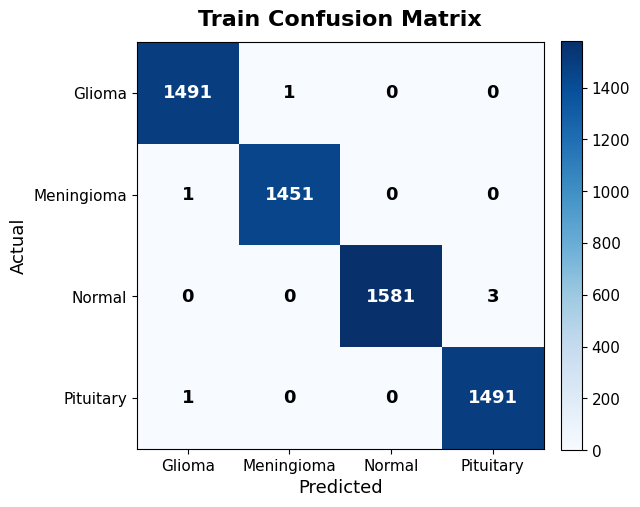

Mean PPV (Precision): 0.9990
Cohen's Kappa: 0.9987
ROC-AUC (macro): 1.0000
PR-AUC (macro): 1.0000
Train inference time: 2.9931 ms
Mean Specificity: 0.999669
Mean NPV: 0.999666

================ VALIDATION SET ================
              precision    recall  f1-score   support

      Glioma     0.9892    0.9839    0.9865       186
  Meningioma     0.9837    0.9945    0.9891       182
      Normal     1.0000    0.9949    0.9975       198
   Pituitary     0.9946    0.9946    0.9946       186

    accuracy                         0.9920       752
   macro avg     0.9919    0.9920    0.9919       752
weighted avg     0.9921    0.9920    0.9920       752



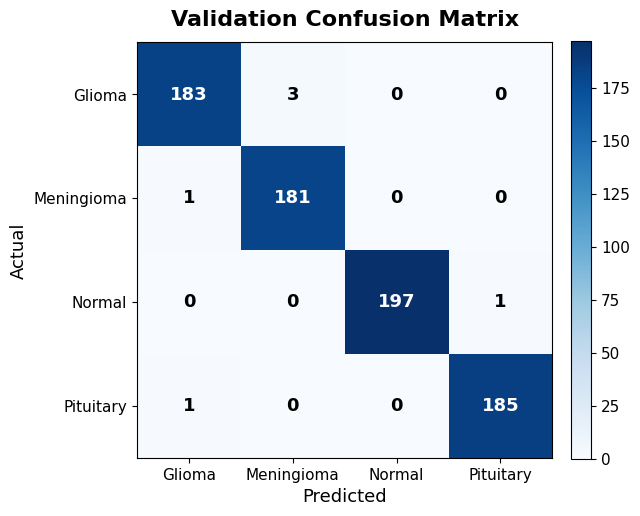

Mean PPV (Precision): 0.9919
Cohen's Kappa: 0.9894
ROC-AUC (macro): 0.9998
PR-AUC (macro): 0.9994
Validation inference time: 3.4168 ms
Mean Specificity: 0.997359
Mean NPV: 0.997345

================ TEST SET ================
              precision    recall  f1-score   support

      Glioma     0.9840    0.9840    0.9840       187
  Meningioma     0.9836    0.9945    0.9890       181
      Normal     0.9949    0.9899    0.9924       198
   Pituitary     0.9946    0.9893    0.9920       187

    accuracy                         0.9894       753
   macro avg     0.9893    0.9894    0.9893       753
weighted avg     0.9894    0.9894    0.9894       753



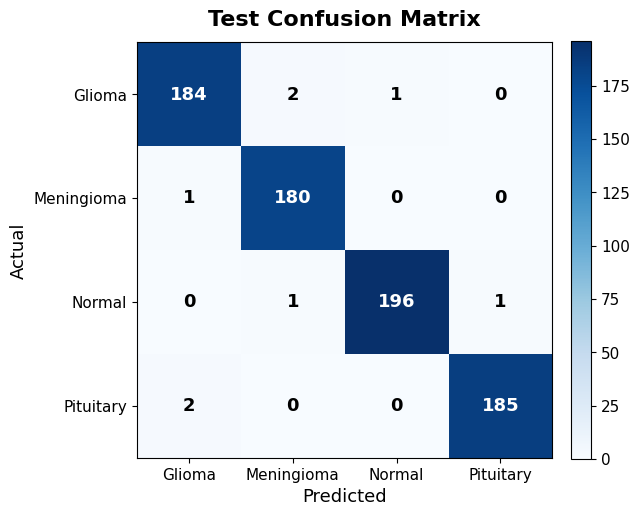

Mean PPV (Precision): 0.9893
Cohen's Kappa: 0.9858
ROC-AUC (macro): 0.9998
PR-AUC (macro): 0.9994
Test inference time: 3.2039 ms
Accuracy 95% CI: 0.9814 – 0.9960
Mean Specificity: 0.996472
Mean NPV: 0.996455


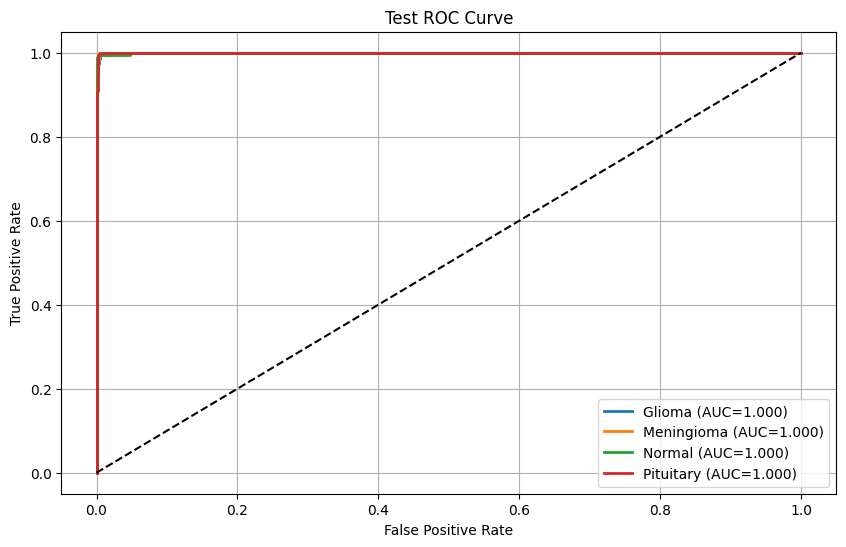

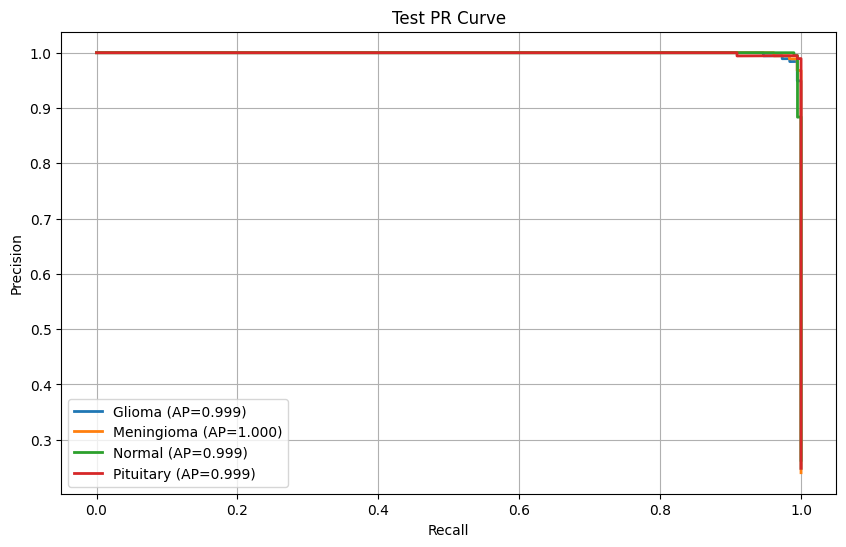



        TIME & MEMORY
Total Training Time: 583.18 sec
Average Time per Epoch: 53.02 sec
Max GPU Memory Allocated: 4.73150976 GB
Max GPU Memory Reserved: 6.765412352 GB
CPU RAM Used: 2.46614016 GB
Inference Time per Image: 37.76216506958008 ms


       MODEL SUMMARY
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 112, 112]             432
          Identity-2         [-1, 16, 112, 112]               0
              SiLU-3         [-1, 16, 112, 112]               0
    BatchNormAct2d-4         [-1, 16, 112, 112]              32
       ConvNormAct-5         [-1, 16, 112, 112]               0
            Conv2d-6         [-1, 64, 112, 112]           1,024
          Identity-7         [-1, 64, 112, 112]               0
              SiLU-8         [-1, 64, 112, 112]               0
    BatchNormAct2d-9         [-1, 64, 112, 112]             128
      ConvNormAct-10       

In [12]:
import time, copy, random, os, psutil
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from pathlib import Path
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from timm import create_model
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, cohen_kappa_score,
    roc_auc_score, average_precision_score,
    roc_curve, auc, precision_recall_curve
)
from sklearn.preprocessing import label_binarize
from torchsummary import summary


# ---------- CONFIG ----------
DATA_ROOT = Path("/kaggle/working/raw_split")
CKPT_DIR  = Path("/kaggle/working/checkpoints"); CKPT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 40
PATIENCE = 5
LR = 3e-3
WD = 1e-3
DROPOUT = 0.5
SEED = 42
NUM_WORKERS = 2
PRETRAINED = True
MODEL_NAME = "mobilevit_s"
# ------------------------


random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# transforms
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


# dataset / loader
train_ds = datasets.ImageFolder(str(DATA_ROOT/"train"), transform=train_tf)
val_ds   = datasets.ImageFolder(str(DATA_ROOT/"val"),   transform=eval_tf)
test_ds  = datasets.ImageFolder(str(DATA_ROOT/"test"),  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

class_names = train_ds.classes
display_names = [c.replace("512","") for c in class_names]
num_classes = len(class_names)
print("Classes:", class_names)
print("Sizes:", len(train_ds), len(val_ds), len(test_ds))


# ---- Build MobileViT ----
model = create_model(
    MODEL_NAME,
    pretrained=PRETRAINED,
    num_classes=num_classes,
    drop_rate=DROPOUT
).to(device)


criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=2, factor=0.5
)


# ================
# TRAINING LOOP
# ================
best_val = float('inf')
best_wts = copy.deepcopy(model.state_dict())
no_improve = 0
train_start = time.time()

for epoch in range(1, NUM_EPOCHS+1):
    t0 = time.time()

    # train
    model.train()
    total_loss = 0; total_correct = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total_correct += (out.argmax(1)==yb).sum().item()

    train_loss = total_loss / len(train_loader.dataset)
    train_acc  = total_correct / len(train_loader.dataset)

    model.eval()
    val_loss_sum = 0; val_correct = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            val_loss_sum += loss.item()*xb.size(0)
            val_correct += (out.argmax(1)==yb).sum().item()

    val_loss = val_loss_sum / len(val_loader.dataset)
    val_acc  = val_correct / len(val_loader.dataset)
    scheduler.step(val_loss)

    print(f"Epoch {epoch}/{NUM_EPOCHS} — train_loss={train_loss:.4f} acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} acc={val_acc:.4f} | time={time.time()-t0:.1f}s")

    # checkpoint
    if val_loss < best_val:
        best_val = val_loss
        best_wts = copy.deepcopy(model.state_dict())
        no_improve = 0
        torch.save({
            "model":"mobilevit",
            "epoch":epoch,
            "state_dict":best_wts,
            "classes":class_names
        }, str(CKPT_DIR/"mobilevit_best.pth"))
        print("  Saved best model.")
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print("Early stopping.")
            break

model.load_state_dict(best_wts)
total_training_time = time.time() - train_start


# =========================
# METRIC HELPERS
# =========================
def plot_confusion(cm, classes, title="Confusion Matrix", cmap="Blues", figsize=(6.5,6.5)):
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm, cmap=cmap)
    ax.set_title(title, fontsize=16, fontweight="700", pad=12)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=11)
    ticks = np.arange(len(classes))
    ax.set_xticks(ticks); ax.set_yticks(ticks)
    ax.set_xticklabels(classes, fontsize=11); ax.set_yticklabels(classes, fontsize=11)
    ax.set_xlabel("Predicted", fontsize=13); ax.set_ylabel("Actual", fontsize=13)
    vmax = cm.max() if cm.max() > 0 else 1
    thresh = vmax / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = int(cm[i, j])
            color = "white" if val > thresh else "black"
            ax.text(j, i, f"{val}", ha="center", va="center", color=color, fontsize=13, fontweight='700')
    plt.tight_layout()
    return fig, ax


def compute_extra_metrics(cm):
    specificity, npv = [], []
    for i in range(len(cm)):
        TP = cm[i,i]
        FN = cm[i,:].sum() - TP
        FP = cm[:,i].sum() - TP
        TN = cm.sum() - (TP+FP+FN)
        specificity.append(TN/(TN+FP) if (TN+FP)>0 else 0)
        npv.append(TN/(TN+FN) if (TN+FN)>0 else 0)
    return np.mean(specificity), np.mean(npv)


def bootstrap_accuracy_ci(y_true, y_pred, samples=1000):
    n = len(y_true)
    accs = []
    for _ in range(samples):
        idx = np.random.randint(0, n, n)
        accs.append(np.mean(y_true[idx] == y_pred[idx]))
    mean = float(np.mean(accs))
    lo   = float(np.percentile(accs, 2.5))
    hi   = float(np.percentile(accs, 97.5))
    return mean, lo, hi

def get_preds_probs_and_time(model, loader):
    model.eval()
    y_true=[]; y_pred=[]; probs=[]
    t0 = time.time()

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            out = model(xb)
            soft = torch.softmax(out, dim=1).cpu().numpy()
            probs.append(soft)
            y_pred.extend(out.argmax(1).cpu().numpy())
            y_true.extend(yb.numpy())

    elapsed = time.time()-t0
    avg_ms = (elapsed/len(y_true))*1000
    return np.array(y_true), np.array(y_pred), np.vstack(probs), avg_ms


# ==============
# TRAIN REPORT
# ==============
print("\n================ TRAIN SET ================")
yt, yp, p_train, train_ms = get_preds_probs_and_time(model, train_loader)

print(classification_report(yt, yp, target_names=display_names, digits=4))

cm = confusion_matrix(yt, yp)
plot_confusion(cm, display_names, "Train Confusion Matrix")
plt.show()

mean_spec, mean_npv = compute_extra_metrics(cm)
ppv = precision_score(yt, yp, average='macro')
kappa = cohen_kappa_score(yt, yp)

try:
    yt_bin = label_binarize(yt, classes=list(range(num_classes)))
    roc_auc = roc_auc_score(yt_bin, p_train, average="macro", multi_class="ovr")
    pr_auc = average_precision_score(yt_bin, p_train, average="macro")
except:
    roc_auc = pr_auc = float('nan')

print(f"Mean PPV (Precision): {ppv:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"ROC-AUC (macro): {roc_auc:.4f}")
print(f"PR-AUC (macro): {pr_auc:.4f}")
print(f"Train inference time: {train_ms:.4f} ms")
print(f"Mean Specificity: {mean_spec:.6f}")
print(f"Mean NPV: {mean_npv:.6f}")


# =====================
# VALIDATION REPORT
# =====================
print("\n================ VALIDATION SET ================")
yt, yp, p_val, val_ms = get_preds_probs_and_time(model, val_loader)

print(classification_report(yt, yp, target_names=display_names, digits=4))

cm = confusion_matrix(yt, yp)
plot_confusion(cm, display_names, "Validation Confusion Matrix")
plt.show()

mean_spec, mean_npv = compute_extra_metrics(cm)
ppv = precision_score(yt, yp, average='macro')
kappa = cohen_kappa_score(yt, yp)

try:
    yt_bin = label_binarize(yt, classes=list(range(num_classes)))
    roc_auc = roc_auc_score(yt_bin, p_val, average="macro", multi_class="ovr")
    pr_auc = average_precision_score(yt_bin, p_val, average="macro")
except:
    roc_auc = pr_auc = float('nan')

print(f"Mean PPV (Precision): {ppv:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"ROC-AUC (macro): {roc_auc:.4f}")
print(f"PR-AUC (macro): {pr_auc:.4f}")
print(f"Validation inference time: {val_ms:.4f} ms")
print(f"Mean Specificity: {mean_spec:.6f}")
print(f"Mean NPV: {mean_npv:.6f}")


# ==============
# TEST REPORT
# ==============
print("\n================ TEST SET ================")
yt, yp, p_test, test_ms = get_preds_probs_and_time(model, test_loader)

print(classification_report(yt, yp, target_names=display_names, digits=4))

cm = confusion_matrix(yt, yp)
plot_confusion(cm, display_names, "Test Confusion Matrix")
plt.show()

mean_spec, mean_npv = compute_extra_metrics(cm)
ppv  = precision_score(yt, yp, average='macro')
kappa = cohen_kappa_score(yt, yp)
acc_mean, acc_lo, acc_hi = bootstrap_accuracy_ci(yt, yp)

try:
    yt_bin = label_binarize(yt, classes=list(range(num_classes)))
    roc_auc = roc_auc_score(yt_bin, p_test, average="macro", multi_class="ovr")
    pr_auc  = average_precision_score(yt_bin, p_test, average="macro")
except:
    roc_auc = pr_auc = float('nan')

print(f"Mean PPV (Precision): {ppv:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"ROC-AUC (macro): {roc_auc:.4f}")
print(f"PR-AUC (macro): {pr_auc:.4f}")
print(f"Test inference time: {test_ms:.4f} ms")
print(f"Accuracy 95% CI: {acc_lo:.4f} – {acc_hi:.4f}")
print(f"Mean Specificity: {mean_spec:.6f}")
print(f"Mean NPV: {mean_npv:.6f}")


# =================
# TEST ROC CURVE
# =================
try:
    plt.figure(figsize=(10,6))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(yt_bin[:, i], p_test[:, i])
        auc_i = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{display_names[i]} (AUC={auc_i:.3f})")

    plt.plot([0,1],[0,1],'k--')
    plt.title("Test ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid()
    plt.show()
except:
    print("ROC curve could not be generated.")

# ===============
# TEST PR CURVE
# ===============
try:
    plt.figure(figsize=(10,6))
    for i in range(num_classes):
        precision, recall, _ = precision_recall_curve(yt_bin[:, i], p_test[:, i])
        auc_i = auc(recall, precision)
        plt.plot(recall, precision, lw=2, label=f"{display_names[i]} (AP={auc_i:.3f})")

    plt.title("Test PR Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.grid()
    plt.show()
except:
    print("PR curve could not be generated.")


# ============================
#       TIME & MEMORY
# ============================
print("\n\n============================")
print("        TIME & MEMORY")
print("============================")

print(f"Total Training Time: {total_training_time:.2f} sec")
print(f"Average Time per Epoch: {total_training_time/epoch:.2f} sec")

if torch.cuda.is_available():
    print("Max GPU Memory Allocated:", torch.cuda.max_memory_allocated()/1e9, "GB")
    print("Max GPU Memory Reserved:", torch.cuda.max_memory_reserved()/1e9, "GB")

print("CPU RAM Used:", psutil.Process(os.getpid()).memory_info().rss/1e9, "GB")

sample = torch.randn(1,3,IMG_SIZE,IMG_SIZE).to(device)
t0 = time.time(); _ = model(sample)
print("Inference Time per Image:", (time.time()-t0)*1000, "ms")

print("\n\n============================")
print("       MODEL SUMMARY")
print("============================")
summary(model, (3, IMG_SIZE, IMG_SIZE))

# **EfficientNet-B0 Model Training**

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Device: cuda
Classes: ['512Glioma', '512Meningioma', '512Normal', '512Pituitary']
Sizes (train/val/test): 6020 752 753


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Epoch 1/40 — train_loss=0.9218 acc=0.8382 | val_loss=0.2110 acc=0.9508 (32.2s)
  Saved best model.
Epoch 2/40 — train_loss=0.1649 acc=0.9555 | val_loss=0.4614 acc=0.8737 (32.4s)
Epoch 3/40 — train_loss=0.1555 acc=0.9611 | val_loss=0.0966 acc=0.9774 (31.9s)
  Saved best model.
Epoch 4/40 — train_loss=0.1138 acc=0.9698 | val_loss=0.0378 acc=0.9934 (32.0s)
  Saved best model.
Epoch 5/40 — train_loss=0.0615 acc=0.9826 | val_loss=0.1762 acc=0.9628 (32.0s)
Epoch 6/40 — train_loss=0.0648 acc=0.9804 | val_loss=0.0290 acc=0.9894 (32.1s)
  Saved best model.
Epoch 7/40 — train_loss=0.0651 acc=0.9786 | val_loss=0.0446 acc=0.9934 (32.0s)
Epoch 8/40 — train_loss=0.0575 acc=0.9842 | val_loss=0.1146 acc=0.9734 (32.0s)
Epoch 9/40 — train_loss=0.1775 acc=0.9510 | val_loss=0.0597 acc=0.9867 (31.9s)
Epoch 10/40 — train_loss=0.0233 acc=0.9932 | val_loss=0.0121 acc=0.9960 (32.0s)
  Saved best model.
Epoch 11/40 — train_loss=0.0091 acc=0.9977 | val_loss=0.0115 acc=0.9973 (32.0s)
  Saved best model.
Epoch 12/

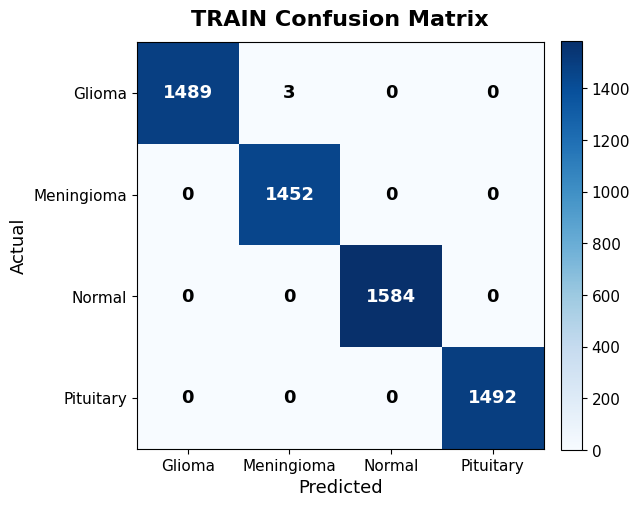

Mean PPV (Precision): 0.9995
Cohen's Kappa: 0.9993
ROC-AUC (macro): 1.0000
PR-AUC (macro): 1.0000
TRAIN inference time per image: 2.7228 ms
Mean Specificity: 0.9998358143607706
Mean NPV: 0.9998344736261311
Bootstrap Accuracy Mean=0.9995, Std=0.0003

=== VAL REPORT ===
              precision    recall  f1-score   support

      Glioma     1.0000    0.9892    0.9946       186
  Meningioma     0.9891    1.0000    0.9945       182
      Normal     1.0000    1.0000    1.0000       198
   Pituitary     1.0000    1.0000    1.0000       186

    accuracy                         0.9973       752
   macro avg     0.9973    0.9973    0.9973       752
weighted avg     0.9974    0.9973    0.9973       752



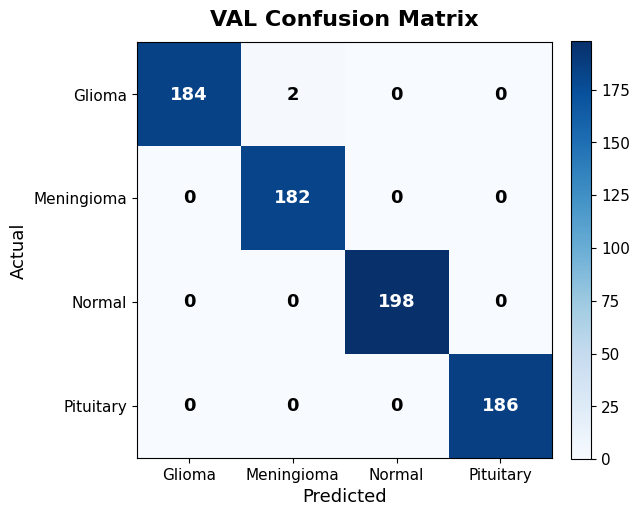

Mean PPV (Precision): 0.9973
Cohen's Kappa: 0.9965
ROC-AUC (macro): 1.0000
PR-AUC (macro): 0.9999
VAL inference time per image: 3.0594 ms
Mean Specificity: 0.9991228070175439
Mean NPV: 0.9991197183098591
Bootstrap Accuracy Mean=0.9973, Std=0.0019

=== TEST REPORT ===
              precision    recall  f1-score   support

      Glioma     1.0000    0.9893    0.9946       187
  Meningioma     0.9890    0.9945    0.9917       181
      Normal     0.9950    1.0000    0.9975       198
   Pituitary     1.0000    1.0000    1.0000       187

    accuracy                         0.9960       753
   macro avg     0.9960    0.9959    0.9960       753
weighted avg     0.9960    0.9960    0.9960       753



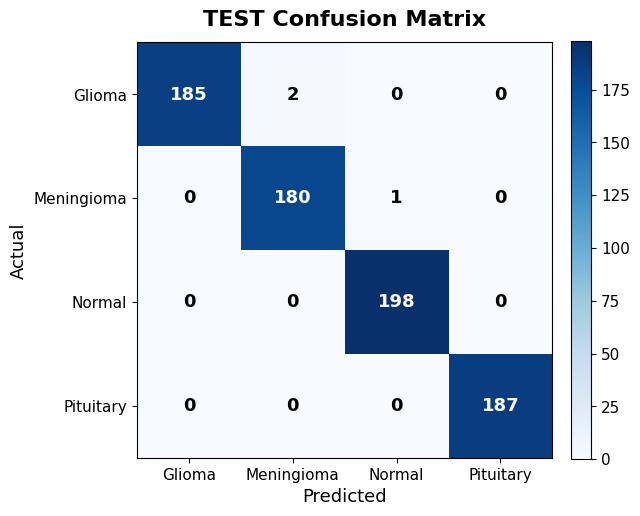

Mean PPV (Precision): 0.9960
Cohen's Kappa: 0.9947
ROC-AUC (macro): 1.0000
PR-AUC (macro): 0.9999
TEST inference time per image: 3.0627 ms
Mean Specificity: 0.9986754236754236
Mean NPV: 0.9986818899385808
Bootstrap Accuracy Mean=0.9960, Std=0.0023
Accuracy 95% CI: 0.9961 [0.9907, 1.0000]


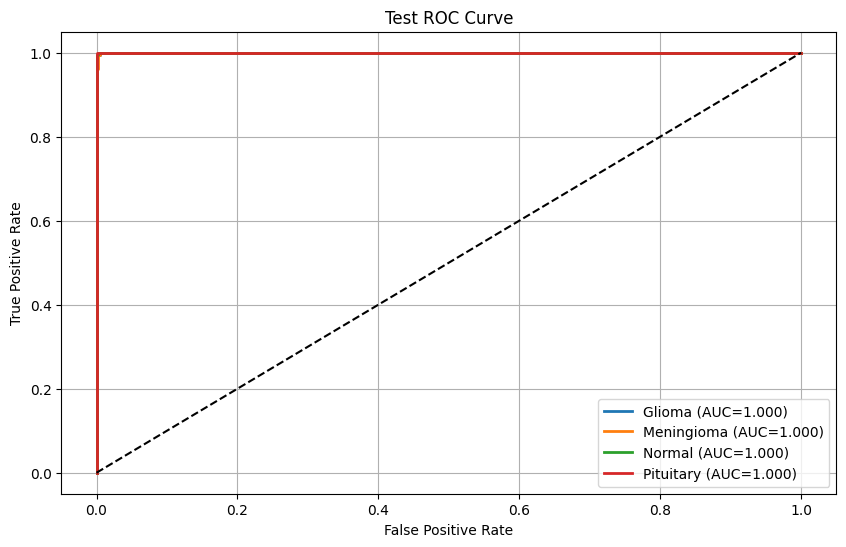

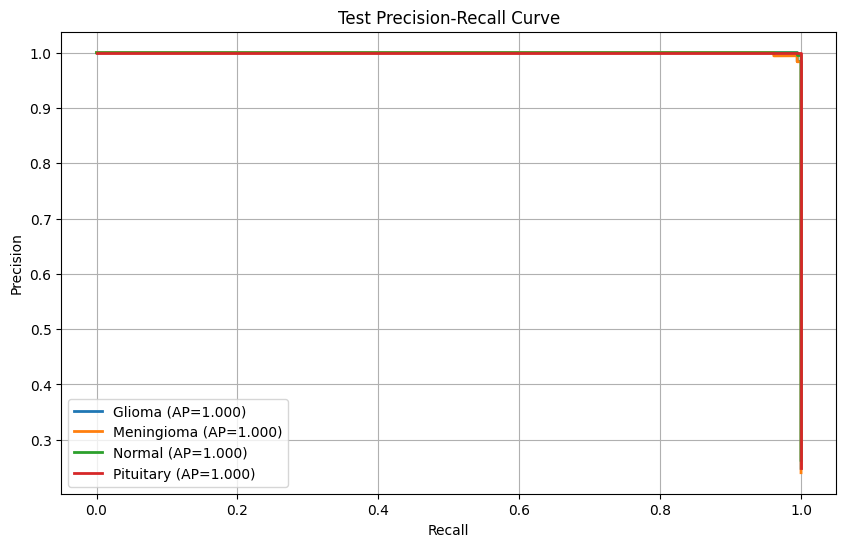



        TIME & MEMORY
Total Training Time: 513.30 sec
Avg Time per Epoch: 32.08 sec
Max GPU memory allocated (GB): 4.73150976
Max GPU memory reserved  (GB): 5.668601856
CPU RAM used (GB): 2.409172992
Inference Time per Image: 103.185 ms

Best checkpoint: /kaggle/working/checkpoints/efficientnet_b0_best.pth


       MODEL SUMMARY
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
          Identity-2         [-1, 32, 112, 112]               0
              SiLU-3         [-1, 32, 112, 112]               0
    BatchNormAct2d-4         [-1, 32, 112, 112]              64
            Conv2d-5         [-1, 32, 112, 112]             288
          Identity-6         [-1, 32, 112, 112]               0
              SiLU-7         [-1, 32, 112, 112]               0
    BatchNormAct2d-8         [-1, 32, 112, 112]              64
          Identity-9      

In [11]:
import time, copy, random, os, psutil
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from timm import create_model
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, cohen_kappa_score,
    roc_auc_score, average_precision_score,
    roc_curve, auc, precision_recall_curve
)
from sklearn.preprocessing import label_binarize
from torchsummary import summary

# ---------- CONFIG ----------
DATA_ROOT = Path("/kaggle/working/raw_split")
CKPT_DIR  = Path("/kaggle/working/checkpoints"); CKPT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 40
PATIENCE = 5
LR = 3e-3
WD = 1e-3
DROPOUT = 0.5
SEED = 42
NUM_WORKERS = 2
PRETRAINED = True
MODEL_NAME = "efficientnet_b0"
# ------------------------

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -------- transforms --------
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_ds = datasets.ImageFolder(str(DATA_ROOT/"train"), transform=train_tf)
val_ds   = datasets.ImageFolder(str(DATA_ROOT/"val"),   transform=eval_tf)
test_ds  = datasets.ImageFolder(str(DATA_ROOT/"test"),  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

class_names = train_ds.classes
num_classes = len(class_names)
display_names = [n.replace("512","") for n in class_names]

print("Classes:", class_names)
print("Sizes (train/val/test):", len(train_ds), len(val_ds), len(test_ds))


# -------- EfficientNet-B0 model --------
model = create_model(
    MODEL_NAME,
    pretrained=PRETRAINED,
    num_classes=num_classes,
    drop_rate=DROPOUT
).to(device)


# -------- Task 11 Model Summary (PRINTED LAST) --------
def save_model_summary():
    print("\n\n============================")
    print("       MODEL SUMMARY")
    print("============================")
    summary(model, (3, IMG_SIZE, IMG_SIZE))


# -------- loss / optimizer / scheduler --------
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.5
)


# -------- Training loop --------
best_val = float('inf'); best_wts = copy.deepcopy(model.state_dict()); no_improve = 0
train_start = time.time()

for epoch in range(1, NUM_EPOCHS+1):
    e0 = time.time()
    model.train()
    tloss = 0; tcorrect = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        tloss += loss.item() * xb.size(0)
        tcorrect += (out.argmax(1)==yb).sum().item()

    train_loss = tloss / len(train_loader.dataset)
    train_acc  = tcorrect / len(train_loader.dataset)

    model.eval()
    vloss = 0; vcorrect = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            vloss += loss.item() * xb.size(0)
            vcorrect += (out.argmax(1)==yb).sum().item()

    val_loss = vloss / len(val_loader.dataset)
    val_acc  = vcorrect / len(val_loader.dataset)
    scheduler.step(val_loss)

    print(f"Epoch {epoch}/{NUM_EPOCHS} — train_loss={train_loss:.4f} acc={train_acc:.4f} "
          f"| val_loss={val_loss:.4f} acc={val_acc:.4f} ({time.time()-e0:.1f}s)")

    if val_loss < best_val:
        best_val = val_loss
        best_wts = copy.deepcopy(model.state_dict())
        no_improve = 0
        torch.save({
            "model":"efficientnet_b0",
            "epoch":epoch,
            "state_dict":best_wts,
            "val_loss":best_val,
            "classes":class_names
        }, str(CKPT_DIR/"efficientnet_b0_best.pth"))
        print("  Saved best model.")
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print("Early stopping."); break

total_training_time = time.time() - train_start

model.load_state_dict(best_wts)


# -------- helpers --------
def get_preds_probs_and_time(model, loader):
    """
    Return y_true, y_pred, probs (N, num_classes), avg_inference_ms
    """
    model.eval()
    y_true = []; y_pred = []; probs = []
    t0 = time.time()
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            out = model(xb)
            soft = torch.softmax(out, dim=1).cpu().numpy()
            preds = out.argmax(1).cpu().numpy()
            probs.append(soft)
            y_pred.extend(preds)
            y_true.extend(yb.numpy())
    elapsed = time.time() - t0
    if len(y_true) == 0:
        avg_ms = 0.0
    else:
        avg_ms = (elapsed / len(y_true)) * 1000.0
    probs = np.vstack(probs) if len(probs) > 0 else np.zeros((0, num_classes))
    return np.array(y_true), np.array(y_pred), probs, avg_ms


def plot_confusion(cm, classes, title="Confusion Matrix", cmap="Blues", figsize=(6.5,6.5)):
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm, cmap=cmap)
    ax.set_title(title, fontsize=16, fontweight="700", pad=12)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=11)
    ticks = np.arange(len(classes))
    ax.set_xticks(ticks); ax.set_yticks(ticks)
    ax.set_xticklabels(classes, fontsize=11); ax.set_yticklabels(classes, fontsize=11)
    ax.set_xlabel("Predicted", fontsize=13); ax.set_ylabel("Actual", fontsize=13)
    vmax = cm.max() if cm.max() > 0 else 1
    thresh = vmax / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = int(cm[i, j])
            color = "white" if val > thresh else "black"
            ax.text(j, i, f"{val}", ha="center", va="center", color=color, fontsize=13, fontweight='700')
    plt.tight_layout()
    return fig, ax


def compute_extra_metrics(cm):
    spec_list = []; npv_list = []
    for i in range(len(cm)):
        TP = cm[i,i]
        FN = cm[i,:].sum() - TP
        FP = cm[:,i].sum() - TP
        TN = cm.sum() - (TP+FP+FN)

        spec = TN/(TN+FP) if (TN+FP)>0 else 0
        npv  = TN/(TN+FN) if (TN+FN)>0 else 0
        spec_list.append(spec); npv_list.append(npv)

    return float(np.mean(spec_list)), float(np.mean(npv_list))


def bootstrap_accuracy_ci(y_true, y_pred, samples=1000):
    n = len(y_true)
    if n == 0:
        return 0.0, 0.0, 0.0
    accs = []
    for _ in range(samples):
        idx = np.random.randint(0, n, n)
        accs.append(np.mean(y_true[idx] == y_pred[idx]))
    mean = float(np.mean(accs))
    lo   = float(np.percentile(accs, 2.5))
    hi   = float(np.percentile(accs, 97.5))
    return mean, lo, hi


def bootstrap_accuracy(y_true, y_pred, samples=1000):
    n = len(y_true); accs=[]
    for _ in range(samples):
        idx = np.random.randint(0,n,n)
        accs.append(np.mean(y_true[idx]==y_pred[idx]))
    return float(np.mean(accs)), float(np.std(accs))


# -------- Metrics after Confusion Matrix --------
for split, loader in [
    ("TRAIN", train_loader),
    ("VAL",   val_loader),
    ("TEST",  test_loader)
]:
    print(f"\n=== {split} REPORT ===")
    yt, yp, probs, avg_ms = get_preds_probs_and_time(model, loader)

    # classification report + confusion
    print(classification_report(yt, yp, target_names=display_names, digits=4))

    cm = confusion_matrix(yt, yp)
    plot_confusion(cm, display_names, f"{split} Confusion Matrix")
    plt.show()

    mean_spec, mean_npv = compute_extra_metrics(cm)
    boot_mean, boot_std = bootstrap_accuracy(yt, yp)

    ppv = precision_score(yt, yp, average='macro', zero_division=0)
    kappa = cohen_kappa_score(yt, yp)

    # ROC-AUC + PR-AUC (macro)
    try:
        if probs is not None and probs.shape[0] == len(yt) and num_classes > 1:
            yt_bin = label_binarize(yt, classes=list(range(num_classes)))
            roc_auc = roc_auc_score(yt_bin, probs, average="macro", multi_class="ovr")
            pr_auc  = average_precision_score(yt_bin, probs, average="macro")
        else:
            roc_auc = float('nan'); pr_auc = float('nan')
    except Exception:
        roc_auc = float('nan'); pr_auc = float('nan')

    print(f"Mean PPV (Precision): {ppv:.4f}")
    print(f"Cohen's Kappa: {kappa:.4f}")
    print(f"ROC-AUC (macro): {roc_auc:.4f}")
    print(f"PR-AUC (macro): {pr_auc:.4f}")
    print(f"{split} inference time per image: {avg_ms:.4f} ms")
    print(f"Mean Specificity: {mean_spec}")
    print(f"Mean NPV: {mean_npv}")
    print(f"Bootstrap Accuracy Mean={boot_mean:.4f}, Std={boot_std:.4f}")

    if split == "TEST":
        acc_mean, acc_lo, acc_hi = bootstrap_accuracy_ci(yt, yp, samples=1000)
        print(f"Accuracy 95% CI: {acc_mean:.4f} [{acc_lo:.4f}, {acc_hi:.4f}]")

        # PLOT TEST ROC CURVE
        try:
            yt_bin = label_binarize(yt, classes=list(range(num_classes)))
            plt.figure(figsize=(10, 6))
            for i in range(num_classes):
                fpr, tpr, _ = roc_curve(yt_bin[:, i], probs[:, i])
                auc_i = auc(fpr, tpr)
                plt.plot(fpr, tpr, lw=2, label=f"{display_names[i]} (AUC={auc_i:.3f})")
            plt.plot([0,1],[0,1],'k--')
            plt.title("Test ROC Curve")
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.legend()
            plt.grid()
            plt.show()
        except Exception:
            print("ROC curve could not be plotted.")

        # PLOT TEST PR CURVE
        try:
            yt_bin = label_binarize(yt, classes=list(range(num_classes)))
            plt.figure(figsize=(10, 6))
            for i in range(num_classes):
                precision, recall, _ = precision_recall_curve(yt_bin[:, i], probs[:, i])
                pr_auc_i = auc(recall, precision)
                plt.plot(recall, precision, lw=2, label=f"{display_names[i]} (AP={pr_auc_i:.3f})")
            plt.title("Test Precision-Recall Curve")
            plt.xlabel("Recall")
            plt.ylabel("Precision")
            plt.legend()
            plt.grid()
            plt.show()
        except Exception:
            print("PR curve could not be plotted.")


# -------- Timing & Memory --------
print("\n\n============================")
print("        TIME & MEMORY")
print("============================")
print(f"Total Training Time: {total_training_time:.2f} sec")
print(f"Avg Time per Epoch: {total_training_time/epoch:.2f} sec")

if torch.cuda.is_available():
    print("Max GPU memory allocated (GB):", torch.cuda.max_memory_allocated()/1e9)
    print("Max GPU memory reserved  (GB):", torch.cuda.max_memory_reserved()/1e9)

print("CPU RAM used (GB):", psutil.Process(os.getpid()).memory_info().rss/1e9)

# inference time (sanity/sample)
sample = torch.randn(1,3,IMG_SIZE,IMG_SIZE).to(device)
t0 = time.time(); _ = model(sample); t1 = time.time()
print(f"Inference Time per Image: {(t1-t0)*1000:.3f} ms")

print("\nBest checkpoint:", CKPT_DIR/"efficientnet_b0_best.pth")

save_model_summary()

# Best Model (EfficientNet-B0) Loss and Acuuracy Curve

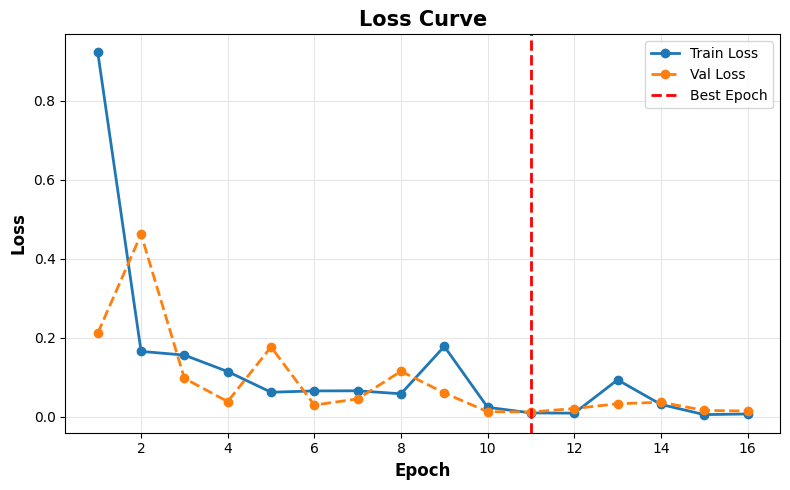

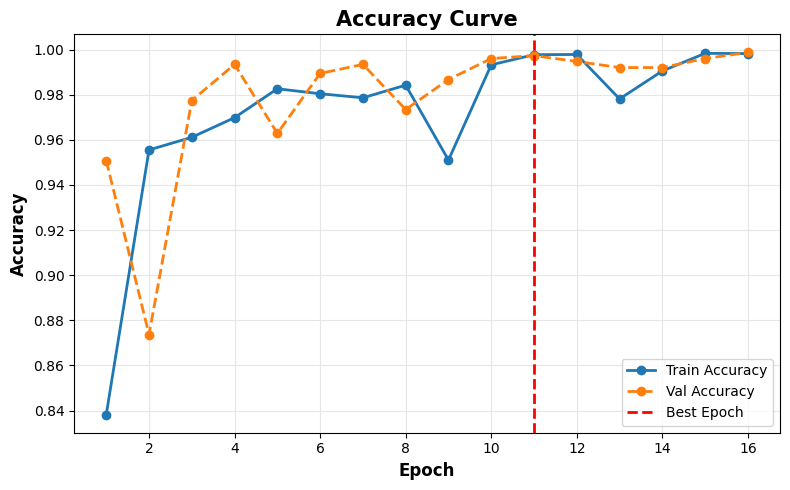

In [1]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1, 17)

# Train loss
train_loss = [
    0.9218, 0.1649, 0.1555, 0.1138, 0.0615, 0.0648, 0.0651, 0.0575,
    0.1775, 0.0233, 0.0091, 0.0085, 0.0928, 0.0306, 0.0048, 0.0064
]

# Validation loss
val_loss = [
    0.2110, 0.4614, 0.0966, 0.0378, 0.1762, 0.0290, 0.0446, 0.1146,
    0.0597, 0.0121, 0.0115, 0.0202, 0.0323, 0.0361, 0.0155, 0.0138
]

# Train accuracy
train_acc = [
    0.8382, 0.9555, 0.9611, 0.9698, 0.9826, 0.9804, 0.9786, 0.9842,
    0.9510, 0.9932, 0.9977, 0.9978, 0.9781, 0.9905, 0.9983, 0.9982
]

# Validation accuracy
val_acc = [
    0.9508, 0.8737, 0.9774, 0.9934, 0.9628, 0.9894, 0.9934, 0.9734,
    0.9867, 0.9960, 0.9973, 0.9947, 0.9920, 0.9920, 0.9960, 0.9987
]

best_epoch = np.argmin(val_loss) + 1

# -------------------- LOSS CURVE --------------------
plt.figure(figsize=(8, 5))
plt.title("Loss Curve", fontsize=15, weight="bold")

plt.plot(epochs, train_loss, marker='o', linewidth=2, label='Train Loss')
plt.plot(epochs, val_loss, linestyle='--', marker='o', linewidth=2, label='Val Loss')

plt.axvline(best_epoch, linestyle='--', color='red', linewidth=2, label='Best Epoch')

plt.xlabel("Epoch", fontsize=12, fontweight="bold")
plt.ylabel("Loss", fontsize=12, fontweight="bold")
plt.grid(True, color='0.9')
plt.legend()
plt.tight_layout()
plt.show()

# -------------------- ACCURACY CURVE --------------------
plt.figure(figsize=(8, 5))
plt.title("Accuracy Curve", fontsize=15, weight="bold")

plt.plot(epochs, train_acc, marker='o', linewidth=2, label='Train Accuracy')
plt.plot(epochs, val_acc, linestyle='--', marker='o', linewidth=2, label='Val Accuracy')

plt.axvline(best_epoch, linestyle='--', color='red', linewidth=2, label='Best Epoch')

plt.xlabel("Epoch", fontsize=12, fontweight="bold")
plt.ylabel("Accuracy", fontsize=12, fontweight="bold")
plt.grid(True, color='0.9')
plt.legend()
plt.tight_layout()
plt.show()

# Grad-CAM Viualization for EfficientNet-B0  

Grad-CAM target layer: Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)


/tmp/ipykernel_47/3191249439.py:134: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_idx = int(logits.argmax(dim=1).cpu().numpy())


Saved Grad-CAM (pred-based) to: /kaggle/working/checkpoints/efficientnet_b0_gradcam_side_by_side.png


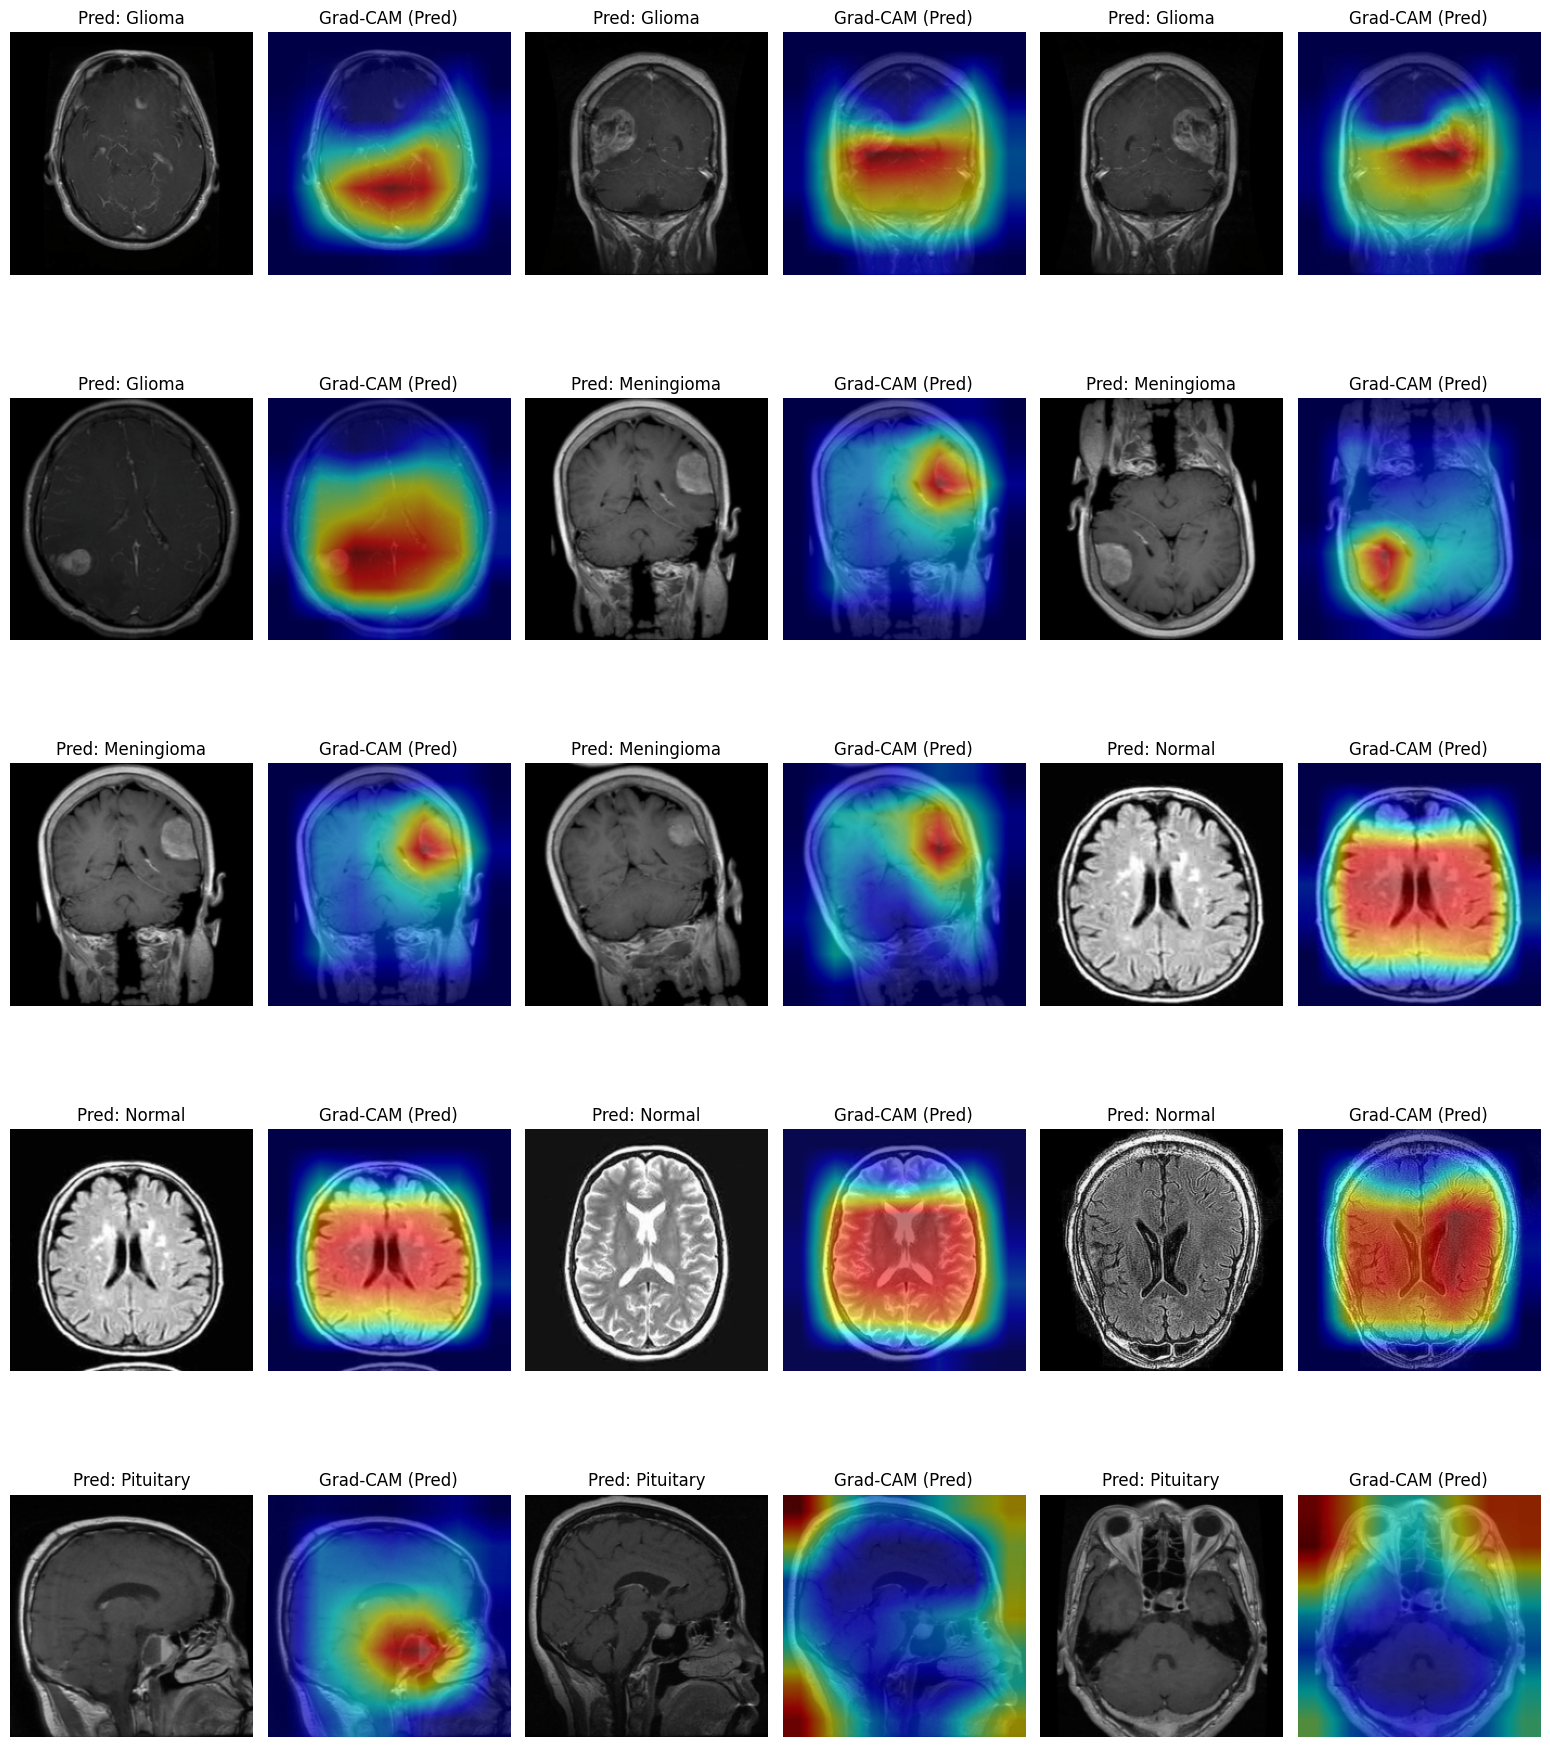

In [29]:
import cv2
import torch.nn.functional as F

NUM_SAMPLES_TO_VIS = 15
OUTPUT_FIG = CKPT_DIR / "efficientnet_b0_gradcam_side_by_side.png"

# ======= Grad-CAM helpers =======
def find_last_conv(m):
    """Return the last nn.Conv2d module inside model"""
    for module in reversed(list(m.modules())):
        if isinstance(module, nn.Conv2d):
            return module
    return None

target_layer = find_last_conv(model)
if target_layer is None:
    raise RuntimeError("No Conv2d layer found in model for Grad-CAM target.")
print("Grad-CAM target layer:", target_layer)

class GradCAM:
    def __init__(self, model, target_module):
        self.model = model
        self.target_module = target_module
        self.activations = None
        self.gradients = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, inp, out):
            # store activations (feature maps)
            self.activations = out.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_module.register_forward_hook(forward_hook)
        try:
            # modern hook API
            self.target_module.register_full_backward_hook(backward_hook)
        except Exception:
            # older torch fallback
            self.target_module.register_backward_hook(backward_hook)

    def __call__(self, x, class_idx=None):
        """
        x: tensor (1, C, H, W)
        returns: numpy mask (H, W) normalized 0..1
        """
        self.model.eval()
        x = x.to(device)

        out = self.model(x)
        if class_idx is None:
            class_idx = int(out.argmax(dim=1)[0].cpu().numpy())

        # backward on the class score
        self.model.zero_grad()
        score = out[0, class_idx]
        score.backward(retain_graph=True)

        grads = self.gradients   
        acts = self.activations  
        if grads is None or acts is None:
            raise RuntimeError("Gradients or activations are None - hooks not registered correctly.")

        # channel-wise weights: global average pooling of gradients
        weights = grads.mean(dim=(2,3), keepdim=True)    
        cam = (weights * acts).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        # upsample to input size
        cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

gradcam = GradCAM(model, target_layer)

# denormalize helper to display
def denormalize_tensor(tensor):
    """tensor: C,H,W normalized -> returns H,W,C in 0..1"""
    mean = np.array([0.485,0.456,0.406])
    std  = np.array([0.229,0.224,0.225])
    img = tensor.permute(1,2,0).cpu().numpy()
    img = (img * std) + mean
    img = np.clip(img, 0.0, 1.0)
    return img

# ------------------------------
# Collect samples from test set
# ------------------------------
imgs_collected = []
labels_collected = []
class_counts = {i:0 for i in range(num_classes)}
max_per_class = int(np.ceil(NUM_SAMPLES_TO_VIS / max(1, num_classes)))

with torch.no_grad():
    for batch_imgs, batch_labels in test_loader:
        for i in range(batch_imgs.size(0)):
            lbl = int(batch_labels[i].item())
            if class_counts[lbl] < max_per_class:
                imgs_collected.append(batch_imgs[i].cpu())
                labels_collected.append(lbl)
                class_counts[lbl] += 1
            if len(imgs_collected) >= NUM_SAMPLES_TO_VIS:
                break
        if len(imgs_collected) >= NUM_SAMPLES_TO_VIS:
            break

if len(imgs_collected) == 0:
    raise RuntimeError("No test images found. Check DATA_ROOT/test.")
if len(imgs_collected) < NUM_SAMPLES_TO_VIS:
    print(f"Only collected {len(imgs_collected)} samples (requested {NUM_SAMPLES_TO_VIS}).")

# layout & plotting (side-by-side: original | gradcam overlay)
n = len(imgs_collected)
pairs_per_row = 3
rows = int(np.ceil(n / pairs_per_row))
fig_cols = pairs_per_row * 2
fig = plt.figure(figsize=(fig_cols * 2.6, rows * 3.8))

for idx in range(n):
    img_t_dev = imgs_collected[idx].unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(img_t_dev)
        pred_idx = int(logits.argmax(dim=1).cpu().numpy())
        pred_name = display_names[pred_idx]

    try:
        mask = gradcam(img_t_dev, class_idx=pred_idx)
    except Exception:
        mask = gradcam(img_t_dev, class_idx=pred_idx)

    raw = denormalize_tensor(imgs_collected[idx])

    # build heatmap + overlay
    heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = 0.55 * heatmap + 0.45 * raw
    overlay = np.clip(overlay, 0, 1)

    r = idx // pairs_per_row
    c = idx % pairs_per_row
    left_pos = r * fig_cols + (c * 2) + 1
    right_pos = left_pos + 1

    ax1 = fig.add_subplot(rows, fig_cols, left_pos)
    ax1.imshow(raw)
    ax1.set_title(f"Pred: {pred_name}", fontsize=12)
    ax1.axis("off")

    ax2 = fig.add_subplot(rows, fig_cols, right_pos)
    ax2.imshow(overlay)
    ax2.set_title("Grad-CAM (Pred)", fontsize=12)
    ax2.axis("off")

plt.tight_layout()
plt.savefig(str(OUTPUT_FIG), dpi=220, bbox_inches='tight')
print("Saved Grad-CAM (pred-based) to:", OUTPUT_FIG)
plt.show()

# EfficientNet-B0: 5-Fold Cross-Validation

In [31]:
# =====================================================
# EfficientNet-B0 + Stratified 5-Fold Cross-Validation
# =====================================================
import os
import time
import copy
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from timm import create_model

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ------------------- USER CONFIG -------------------
DATA_ROOT = Path("/kaggle/working/raw_split")
CKPT_DIR  = Path("/kaggle/working/checkpoints"); CKPT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 40
PATIENCE = 5
LR = 3e-3          
WD = 1e-3          
DROPOUT = 0.5
SEED = 42
NUM_WORKERS = 2
PRETRAINED = True
MODEL_NAME = "efficientnet_b0"
NUM_FOLDS = 5

# ------------------- Reproducibility -------------------
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ------------------- TRANSFORMS -------------------
common_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# ------------------- DATASETS -------------------
full_train_ds = datasets.ImageFolder(str(DATA_ROOT/"train"), transform=common_tfms)
test_ds = datasets.ImageFolder(str(DATA_ROOT/"test"), transform=common_tfms)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

class_names = full_train_ds.classes
num_classes = len(class_names)

indices = np.arange(len(full_train_ds))
labels = np.array([s[1] for s in full_train_ds.samples])

print("Classes:", class_names)
print("Train size:", len(full_train_ds), "Test size:", len(test_ds))

# --------------------------------------------------------------
# Helper — Build EfficientNet-B0
# --------------------------------------------------------------
def build_efficientnet(num_classes, dropout=DROPOUT, pretrained=PRETRAINED):
    try:
        m = create_model(MODEL_NAME, pretrained=pretrained, num_classes=num_classes, drop_rate=dropout)
    except Exception:
        m = create_model(MODEL_NAME, pretrained=pretrained, num_classes=num_classes)
    return m

# --------------------------------------------------------------
# Helper — 1 training epoch
# --------------------------------------------------------------
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, running_correct = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        running_correct += (out.argmax(1)==yb).sum().item()
    return running_loss / len(loader.dataset)

# --------------------------------------------------------------
# Helper — Validation
# --------------------------------------------------------------
def validate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            total_loss += loss.item() * xb.size(0)
            preds = out.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(yb.cpu().numpy())
    return total_loss/len(loader.dataset), np.array(y_true), np.array(y_pred)

# --------------------------------------------------------------
# 5-FOLD CV
# --------------------------------------------------------------
skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)

metrics = {"acc":[], "prec":[], "rec":[], "f1":[]}
best_model_state = None
best_loss = float("inf")
best_fold = None

print("\n===== STRATIFIED 5-FOLD CROSS VALIDATION STARTED =====\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(indices, labels), 1):

    print(f"\n========== Fold {fold} ==========")

    train_subset = Subset(full_train_ds, train_idx)
    val_subset   = Subset(full_train_ds, val_idx)

    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True)
    val_loader   = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)

    model = build_efficientnet(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

    patience_counter = 0
    best_fold_loss = float("inf")
    best_y_true, best_y_pred = None, None
    best_state = None

    # ------------------- TRAIN (Silent) -------------------
    for epoch in range(NUM_EPOCHS):
        train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, y_true, y_pred = validate(model, val_loader, criterion)
        scheduler.step(val_loss)

        # EARLY STOPPING (store best)
        if val_loss < best_fold_loss - 1e-6:
            best_fold_loss = val_loss
            patience_counter = 0
            best_y_true = y_true
            best_y_pred = y_pred
            best_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                break

    # ------------------- SAVE FOLD METRICS -------------------
    acc = accuracy_score(best_y_true, best_y_pred)
    prec = precision_score(best_y_true, best_y_pred, average="macro", zero_division=0)
    rec = recall_score(best_y_true, best_y_pred, average="macro", zero_division=0)
    f1 = f1_score(best_y_true, best_y_pred, average="macro", zero_division=0)

    metrics["acc"].append(acc)
    metrics["prec"].append(prec)
    metrics["rec"].append(rec)
    metrics["f1"].append(f1)

    print(f"Fold {fold} Results — Acc: {acc:.4f}, Prec: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

    # save fold best checkpoint
    if best_state is not None:
        torch.save({
            "model": MODEL_NAME,
            "fold": fold,
            "state_dict": best_state,
            "val_loss": best_fold_loss,
            "classes": class_names
        }, str(CKPT_DIR/f"{MODEL_NAME}_cv_fold{fold}.pth"))

    if best_fold_loss < best_loss:
        best_loss = best_fold_loss
        best_model_state = copy.deepcopy(best_state)
        best_fold = fold

    del model
    torch.cuda.empty_cache()

# --------------------------------------------------------------
# CV SUMMARY
# --------------------------------------------------------------
print("\n===== CROSS VALIDATION SUMMARY =====")
print(f"Accuracy: {np.mean(metrics['acc']):.4f} ± {np.std(metrics['acc']):.4f}")
print(f"Precision: {np.mean(metrics['prec']):.4f} ± {np.std(metrics['prec']):.4f}")
print(f"Recall: {np.mean(metrics['rec']):.4f} ± {np.std(metrics['rec']):.4f}")
print(f"F1: {np.mean(metrics['f1']):.4f} ± {np.std(metrics['f1']):.4f}")
print(f"\nBest Fold = {best_fold} (lowest val loss)")

# save best overall CV model
if best_model_state is not None:
    torch.save({
        "model": MODEL_NAME,
        "state_dict": best_model_state,
        "val_loss": best_loss,
        "classes": class_names
    }, str(CKPT_DIR/f"{MODEL_NAME}_cv_best.pth"))
    print("Saved best CV model to:", CKPT_DIR/f"{MODEL_NAME}_cv_best.pth")


Device: cuda
Classes: ['512Glioma', '512Meningioma', '512Normal', '512Pituitary']
Train size: 6020 Test size: 753

===== STRATIFIED 5-FOLD CROSS VALIDATION STARTED =====


========== Fold 1 ==========
Fold 1 Results — Acc: 0.9958, Prec: 0.9959, Recall: 0.9957, F1: 0.9958

========== Fold 2 ==========
Fold 2 Results — Acc: 0.9826, Prec: 0.9826, Recall: 0.9824, F1: 0.9823

========== Fold 3 ==========
Fold 3 Results — Acc: 0.9884, Prec: 0.9883, Recall: 0.9886, F1: 0.9884

========== Fold 4 ==========
Fold 4 Results — Acc: 0.9958, Prec: 0.9958, Recall: 0.9958, F1: 0.9958

========== Fold 5 ==========
Fold 5 Results — Acc: 0.9909, Prec: 0.9909, Recall: 0.9908, F1: 0.9908

===== CROSS VALIDATION SUMMARY =====
Accuracy: 0.9907 ± 0.0050
Precision: 0.9907 ± 0.0050
Recall: 0.9906 ± 0.0050
F1: 0.9906 ± 0.0050

Best Fold = 1 (lowest val loss)
Saved best CV model to: /kaggle/working/checkpoints/efficientnet_b0_cv_best.pth


# Training & Inference Time Across Models

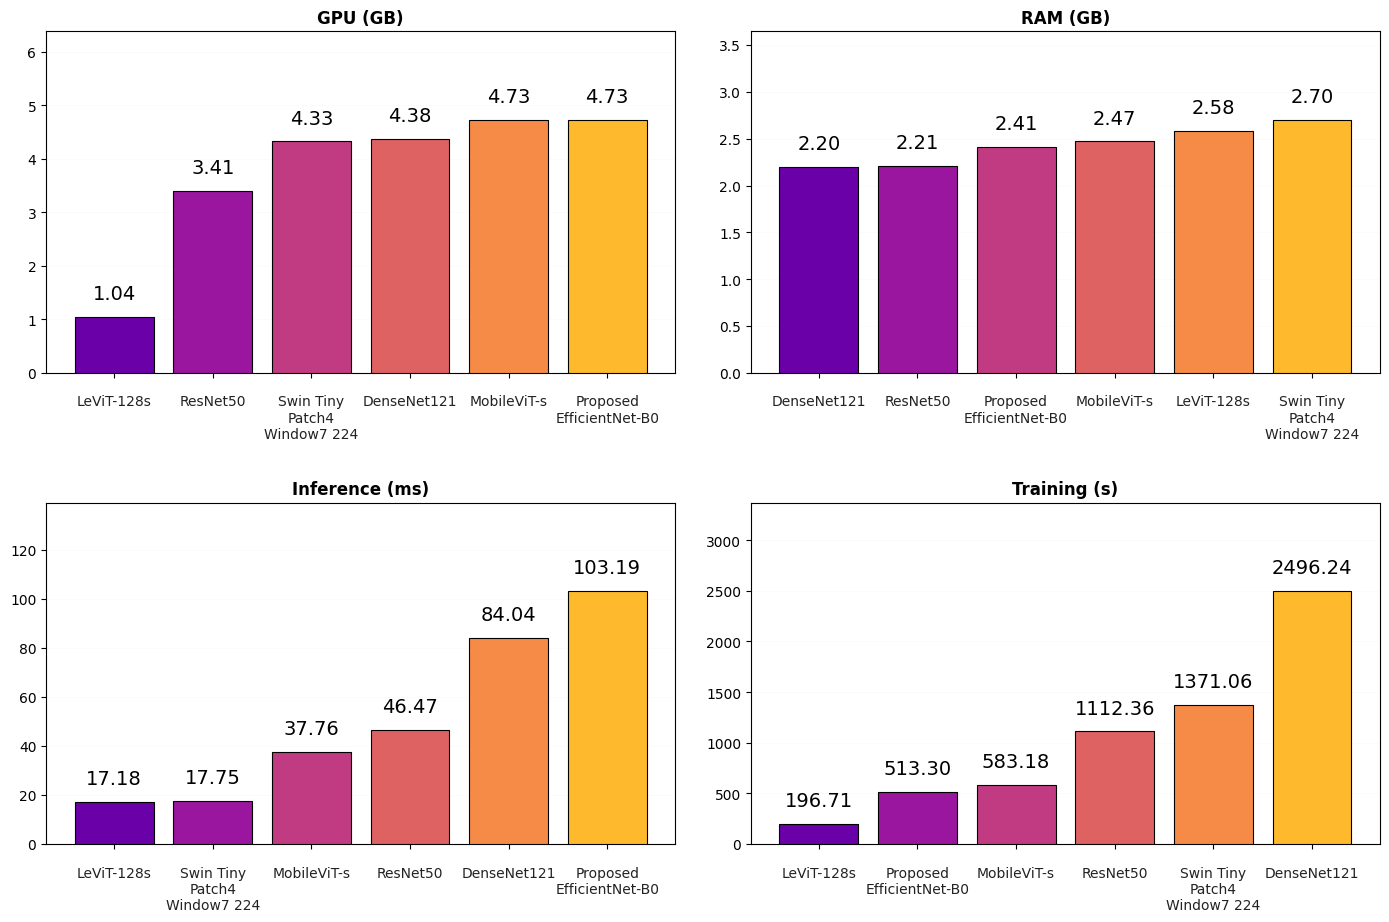

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import textwrap

# Data
models = [
    "ResNet50 + SE",
    "Swin Tiny Patch4 Window7 224 + SE",
    "DenseNet121 + SE",
    "LeViT-128s + SE",
    "MobileViT-s + SE",
    "Proposed EfficientNet-B0 + SE"
]
short_names = [m.split('+')[0].strip() for m in models]

gpu   = np.array([3.41, 4.33, 4.38, 1.04, 4.73, 4.73], dtype=float)
ram   = np.array([2.21, 2.70, 2.20, 2.58, 2.47, 2.41], dtype=float)
infer = np.array([46.47, 17.75, 84.04, 17.18, 37.76, 103.19], dtype=float)
train = np.array([1112.36, 1371.06, 2496.24, 196.71, 583.18, 513.30], dtype=float)

metrics = [
    ("GPU (GB)", gpu),
    ("RAM (GB)", ram),
    ("Inference (ms)", infer),
    ("Training (s)", train)
]

plt.style.use("default")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

def wrap_label(s, width=12, max_lines=3):
    """Wraps a label into multiple lines with maximum width and lines."""
    parts = textwrap.wrap(s, width=width)
    if len(parts) > max_lines:
        parts = parts[:max_lines-1] + [' '.join(parts[max_lines-1:])]
    return "\n".join(parts)

for ax, (title, arr) in zip(axes, metrics):
    idx = np.argsort(arr)   # Sort ascending
    vals = arr[idx]
    names = np.array(short_names)[idx].tolist()

    names = [
        n.replace("Proposed EfficientNet-B0", "Proposed\nEfficientNet-B0")
        for n in names
    ]

    # Gradient bar colors
    colors = cm.plasma(np.linspace(0.2, 0.85, len(vals)))

    # Bars (in front of grid)
    bars = ax.bar(
        range(len(names)), vals,
        color=colors,
        edgecolor='black',
        linewidth=0.8,
        zorder=3
    )

    # Top margin to avoid overlap
    ax.set_ylim(0, max(vals) * 1.35)

    # Value labels above bars
    label_offset = 0.07
    for x, y in zip(range(len(names)), vals):
        ax.text(
            x, y + (max(vals) * label_offset),
            f"{y:.2f}", ha='center', fontsize=14, zorder=4
        )

    ax.set_title(title, fontsize=12, fontweight='bold')

    # Auto-wrap OTHER labels (your manual split remains untouched)
    wrapped_names = [
        wrap_label(n, width=12, max_lines=3) if "\n" not in n else n
        for n in names
    ]

    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(wrapped_names, rotation=0, ha='center', fontsize=10, color='#222222')
    ax.tick_params(axis='x', which='major', pad=12)

    # Subtle grid behind bars
    ax.grid(
        axis='y',
        linestyle='-',
        linewidth=0.6,
        color='#DDDDDD',
        alpha=0.13,
        zorder=0
    )

plt.tight_layout()
plt.subplots_adjust(bottom=0.15, hspace=0.38, wspace= 0.12)
plt.savefig("bar_style_dark_labels_readable.png", dpi=220, bbox_inches='tight')
plt.show()